In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

from platform import python_version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import importlib 
from sklearn.preprocessing import OrdinalEncoder

# import user functions
import UserUtilityFunctions as uf
import UserStatisticalFunctions as usf
import UserVisualization as uv
import UserImputeFunctions as uif

# set seaborn theme
sns.set_theme()

# initializing variables
REMOVE = '** REMOVE ** CAT ML'
RANDOM_STATE = 1776

# print versions
print("Numpy Version: " + np.__version__)
print("Pandas Version: " + pd.__version__)
print("Seaborn Version: " + sns.__version__)
print("Matplotlib Version: " + plt.matplotlib.__version__)
print("Python Version: " + python_version())

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

Numpy Version: 1.26.4
Pandas Version: 2.2.3
Seaborn Version: 0.13.2
Matplotlib Version: 3.9.2
Python Version: 3.9.20


####  Mann-Whitney U Test

#####  Mann-Whitney U test
- The Mann-Whitney U test is a non-parametric statistical test used to determine whether there is a significant difference between the distributions of two independent samples. It is often used as an alternative to the t-test when the assumption of normality is not met.
    - Key Assumptions
        - The two samples are independent.
        - The data is ordinal, interval, or ratio scale.
        - The distributions of the two groups are similar in shape if testing medians.
    - Interpretation
        - If the p-value is less than your significance level (e.g., 0.05), you reject the null hypothesis and conclude that there is a statistically significant difference between the two groups.
        - If the p-value is greater than the significance level, you fail to reject the null hypothesis, indicating insufficient evidence to suggest a difference in distributions.

### Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/4Clean_Heart_Engineer.pkl")
df_label = pd.read_pickle("../Data/4Clean_Label_Engineer.pkl")
df_can = pd.read_pickle("../Data/4Clean_CAN_Engineer.pkl")
df_don = pd.read_pickle("../Data/4Clean_DON_Engineer.pkl")
df_both = pd.read_pickle("../Data/4Clean_BOTH_Engineer.pkl")
df_nominal = pd.read_pickle("../Data/4Clean_Nominal_Engineer.pkl")
df_ordinal = pd.read_pickle("../Data/4Clean_Ordinal_Engineer.pkl")
df_numeric = pd.read_pickle("../Data/4Clean_Numeric_Engineer.pkl")
df_new = pd.read_pickle("../Data/4Clean_New_Engineer.pkl")
df_drop = pd.read_pickle("../Data/4Clean_Drop_Engineer.pkl")
df_dict = pd.read_pickle("../Data/4Clean_Dictionary_Engineer.pkl")
df_object = pd.read_pickle("../Data/4Clean_Object_Engineer.pkl")
df_unknown = pd.read_pickle("../Data/4Clean_Unknown_Engineer.pkl")
df_date = pd.read_pickle("../Data/4Clean_Date_Engineer.pkl")

# checking for duplicated column name
df.columns[df.columns.duplicated()]

Index([], dtype='object')

In [3]:
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")
print(f"Label Features: {df_label.shape[0]:,}")
print(f"Candidate Features: {df_can.shape[0]:,}")
print(f"Donor Features: {df_don.shape[0]:,}")
print(f"Both Features: {df_both.shape[0]:,}")
print(f"Nominal Features: {df_nominal.shape[0]:,}")
print(f"Ordinal Features: {df_ordinal.shape[0]:,}")
print(f"Numeric Features: {df_numeric.shape[0]:,}")
print(f"New Features: {df_new.shape[0]:,}")
print(f"Drop Features: {df_drop.shape[0]:,}")
print(f"Dictionary Features: {df_object.shape[0]:,}")
print(f"Object Features: {df_object.shape[0]:,}")
print(f"Unknown Features: {df_unknown.shape[0]:,}")
print(f"Date Features: {df_date.shape[0]:,}")

Heart Dataset Rows: 16,126 & Columns: 254
Label Features: 15
Candidate Features: 133
Donor Features: 89
Both Features: 21
Nominal Features: 173
Ordinal Features: 13
Numeric Features: 69
New Features: 28
Drop Features: 25
Dictionary Features: 0
Object Features: 0
Unknown Features: 0
Date Features: 0


### Examine Features

In [4]:
df[df_label.column.to_list()].head()

,AcuteRejectionEpisode,AirwayDehiscencePostTransplant,StrokePostTransplant,PacemakerPostTransplant,DialysisPostDischarge,GraftFailStatus,GraftLifeSpanDay,LastFollowupNumber,GraftStatus,TransplantStatus,TransplantSurvivalDay,RecipientStatus,RejectionTreatmentWithinOneYear,FunctionalStatusFollowUp,LengthOfStay
0,No,No,No,No,No,Success,1549.0,50,Yes,Alive,1549.0,Living,No,"100% - Normal, no complaints, no evidence of disease",11.0
1,No,No,No,No,No,Success,1827.0,50,Yes,Alive,1827.0,Living,No,90% - Able to carry on normal activity: minor symptoms of disease,8.0
2,"Yes, none treated with additional anti-rejection agent",No,No,No,No,Success,1677.0,50,Yes,Alive,1677.0,Living,No,80% - Normal activity with effort: some symptoms of disease,21.0
3,No,No,No,No,No,Failure,9.0,1,No,Dead,9.0,Dead,Missing,60% - Requires occasional assistance but is able to care for needs,9.0
4,No,No,No,No,No,Success,1840.0,50,Yes,Alive,1840.0,Living,No,Unknown,25.0


In [5]:
# remove unwanted labels
removeCols = df_label.column[~df_label.column.isin(['TransplantSurvivalDay', 'LengthOfStay'])].to_list()
removeCols.extend(df_new.column.to_list())

# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 13 row(s) from df_label DataFrame.
Remove 16 row(s) from df_can DataFrame.
Remove 2 row(s) from df_don DataFrame.
Remove 14 row(s) from df_both DataFrame.
Remove 1 row(s) from df_ordinal DataFrame.
Remove 10 row(s) from df_nominal DataFrame.
Remove 30 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['AcuteRejectionEpisode', 'Age_Addition', 'Age_Difference', 'AirwayDehiscencePostTransplant', 'BMI_Addition', 'BMI_Difference', 'Creatinine_Addition_CAN', 'Creatinine_Difference_CAN', 'DialysisPostDischarge', 'FunctionalStatusFollowUp', 'GraftFailStatus', 'GraftLifeSpanDay', 'GraftStatus', 'HeightCm_Addition', 'HeightCm_Difference', 'HemodynamicsRegistration_Addition_CAN', 'HemodynamicsRegistration_Interaction_CAN', 'HemodynamicsTransplant_Addition_CAN', 'HemodynamicsTransplant_Interaction_CAN

### Determine Candidate Survival for 600 Days

In [6]:
# remove rows where TransplantSurvivalDay is NaN
df = df.dropna(subset=['TransplantSurvivalDay'])
# print
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")

Heart Dataset Rows: 15,701 & Columns: 213


In [7]:
# initialize
removeCols = ['TransplantSurvivalDay']

# create new feature
df['Survival'] = df.TransplantSurvivalDay >= 600

# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 1 row(s) from df_label DataFrame.
Remove 0 row(s) from df_can DataFrame.
Remove 0 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 1 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['TransplantSurvivalDay']

Total Row(s) & Column(s) Before Removing Column(s): 15,701 & columns: 214
Total Row(s) & Column(s) After Removing Column(s): 15,701 & columns: 213


In [8]:
# sanity check
uf.datatypeDF(df, display=True)

Total Data feature count:  213

Boolean feature count: 1
Category feature count: 79
Numeric feature count: 38
Object feature count: 95
Other feature count: 0

Total feature count:  213


In [9]:
# display NaNs
uf.percentageNull(df)

,percentage,NaNCount
CPRA_Peak_CAN,23.578116,3702
CPRA_Recent_CAN,23.488950,3688
HemodynamicsRegistration_PCW_CAN,8.744666,1373
HemodynamicsTransplant_PCW_CAN,7.509076,1179
HemodynamicsRegistration_CO_CAN,5.190752,815
HemodynamicsTransplant_CO_CAN,4.643016,729
HemodynamicsTransplant_PA_MN_CAN,3.942424,619
HemodynamicsRegistration_PA_MN_CAN,3.923317,616
HemodynamicsRegistration_PA_DIA_CAN,3.413795,536
HemodynamicsRegistration_SYS_CAN,3.343736,525


In [10]:
# check label
df.Survival.value_counts()

Survival
True     8274
False    7427
Name: count, dtype: int64

In [11]:
# remove unused categories
df = uf.removeCatZeroCount(df).copy()

In [12]:
# sanity check
print(f"Total Length: {len(df_nominal.column.to_list()) + len(df_ordinal.column.to_list())+ len(df_numeric.column.to_list())}")
nominalCols = df_nominal.column.to_list()
ordinalCols = df_ordinal.column.to_list()
numericCols = df_numeric.column.to_list()
allCols = df.columns.to_list()
# display the difference
set(allCols).symmetric_difference(set(ordinalCols)|set(nominalCols)|set(numericCols))

Total Length: 213


{'Survival'}

### Engineer / Remove Features

##### Test of Independence for Categorical Variables
- Null Hypothesis (H0): The two variables are not related.
- Alternative Hypothesis (H1): The two variables are related.
- A low p-value (typically < 0.05) indicates a significant relationship between the variables.
- This is the Chi-Square test statistic. It measures the discrepancy between the observed and expected frequencies under the assumption that the variables are independent.
    - A larger `chi2` value indicates a greater difference between observed and expected counts, suggesting that the variables are more likely to be associated.
    - A small p_value (typically < 0.05) suggests that you can reject the null hypothesis and conclude that there is a significant association between the two variables.

##### Cramer's V values can be interpreted as:
- Cramer's V is a measure of association between two nominal (categorical) variables, based on the Chi-Square statistic and varies from `0` (corresponding to no association between the variables) to `1` (complete association) and can reach 1 only when each variable is completely determined by the other.
    - 0.00 to 0.10: Negligible association
    - 0.10 to 0.30: Weak association
    - 0.30 to 0.50: Moderate association
    - 0.50 to 0.70: Strong association
    - 0.70 to 1.00: Very strong association

### Discretization

#### Numeric

In [13]:
print(sorted(numericCols))

['Age_CAN', 'Age_DON', 'BMI_CAN', 'BMI_DON', 'BloodPH_DON', 'BloodUreaNitrogenLevel_DON', 'CPRA_Peak_CAN', 'CPRA_Recent_CAN', 'CreatinineRegistration_CAN', 'CreatinineTransplant_CAN', 'Creatinine_DON', 'DistanceFromDonorHospitaltoTXCenter', 'HeightCm_CAN', 'HeightCm_DON', 'Hematocrit_DON', 'HemodynamicsRegistration_CO_CAN', 'HemodynamicsRegistration_PA_DIA_CAN', 'HemodynamicsRegistration_PA_MN_CAN', 'HemodynamicsRegistration_PCW_CAN', 'HemodynamicsRegistration_SYS_CAN', 'HemodynamicsTransplant_CO_CAN', 'HemodynamicsTransplant_PA_DIA_CAN', 'HemodynamicsTransplant_PA_MN_CAN', 'HemodynamicsTransplant_PCW_CAN', 'HemodynamicsTransplant_SYS_CAN', 'IschemicTimeHour_DON', 'LV_EjectionFractionPercent_DON', 'LengthOfStay', 'Level_SGOT_ALT_DON', 'Level_SGOT_AST_DON', 'LungPO2_DON', 'LungPO2_FIO2_DON', 'OrganRecovery_PCO2_DON', 'TerminalTotalBilirubin_DON', 'TotalBilirubinTransplant_CAN', 'TotalDayWaitList_CAN', 'WeightKg_CAN', 'WeightKg_DON']


##### Age

In [14]:
features = uf.getFeatureList(df, 'Age_')

           count       mean        std   min   25%   50%   75%   max
Age_CAN  15701.0  53.540348  12.934893  18.0  46.0  57.0  64.0  77.0
Age_DON  15701.0  32.259792  10.662259   8.0  24.0  31.0  40.0  70.0

:::: NaN Count:
Age_CAN    0
Age_DON    0


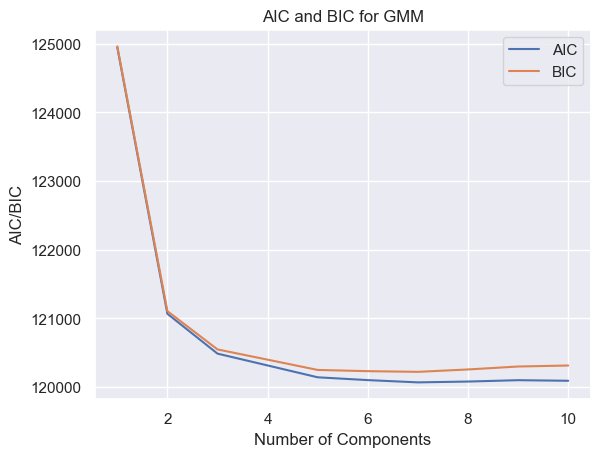

In [15]:
uif.GaussianMixtureBinning(df, ['Age_CAN'], RANDOM_STATE)

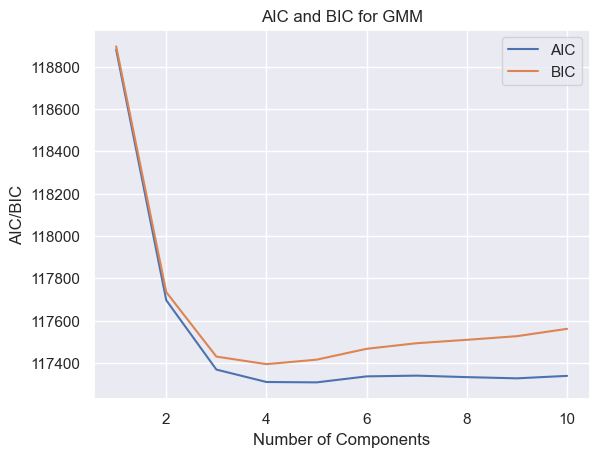

In [16]:
uif.GaussianMixtureBinning(df, ['Age_DON'], RANDOM_STATE)

In [17]:
df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Age_CAN,15701.0,53.540348,12.934893,18.0,46.0,57.0,64.0,77.0
Age_DON,15701.0,32.259792,10.662259,8.0,24.0,31.0,40.0,70.0


In [18]:
# use quartile bin
df['Age_CAT_CAN'] = pd.qcut(df['Age_CAN'], q=4, labels=['Age (Min-47)', 'Age(48-57)', 'Age(58-64)', 'Age(65-Max)'])
df['Age_CAT_DON'] = pd.qcut(df['Age_DON'], q=4, labels=['Age (Min-24)', 'Age(22-31)', 'Age(32-39)', 'Age(40-Max)'])

# category datatype
df['Age_CAT_CAN'] = df['Age_CAT_CAN'].astype('category')
df['Age_CAT_DON'] = df['Age_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['Age_CAT_CAN', 'Age_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['Age_CAT_DON'])
df_can = uf.insertIntoDataFrame(df_can, ['Age_CAT_CAN'])

# add to list
removeCols = features

In [19]:
uf.categoryContingencySurvival(df, 'Age_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
Age (Min-47),1858.0,2092.0,3950.0,47.037975,52.962025
Age(48-57),1989.0,2325.0,4314.0,46.105702,53.894298
Age(58-64),1967.0,2144.0,4111.0,47.847239,52.152761
Age(65-Max),1613.0,1713.0,3326.0,48.496693,51.503307
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


In [20]:
uf.categoryContingencySurvival(df, 'Age_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Age (Min-24),1884.0,2395.0,4279.0,44.028979,55.971021
Age(22-31),1804.0,1961.0,3765.0,47.915007,52.084993
Age(32-39),2053.0,2022.0,4075.0,50.380368,49.619632
Age(40-Max),1686.0,1896.0,3582.0,47.068677,52.931323
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


##### [BMI](https://www.cdc.gov/bmi/adult-calculator/bmi-categories.html)
- The standard BMI ranges for adults are:
    - Underweight: BMI less than 18.5 kg/m²
    - Normal weight: BMI 18.5 to 24.9 kg/m²
    - Overweight: BMI 25 to 29.9 kg/m²
    - Obesity: BMI 30 kg/m² or greater
    - BMI = Weight (kg) / Height (m)²

In [21]:
def categorizeBMI(value):
    """
    Define the function for mapping
    """
    if value < 18.5:
        return "Under Weight"
    elif 18.5 <= value <= 24.9:
        return "Normal Weight"        
    elif 24.9 <= value <= 29.9:
        return "Over Weight"
    elif value >= 29.9:
        return "Obesity"
    else:
        return "Unknown"

##### HeightCm

In [22]:
features = uf.getFeatureList(df, 'HeightCm')

                count        mean        std    min    25%    50%    75%    max
HeightCm_CAN  15701.0  173.576135  10.060199  124.0  167.6  174.5  180.3  213.4
HeightCm_DON  15701.0  173.846577   9.482926  115.0  167.6  175.0  180.3  213.0

:::: NaN Count:
HeightCm_CAN    0
HeightCm_DON    0


In [23]:
# use quartile bin
df['HeightCm_CAT_CAN'] = pd.qcut(df['HeightCm_CAN'], q=4, labels=['HeightCm (Min-168)', 'HeightCm(169-175)', 'HeightCm(176-181)', 'HeightCm(182-Max)'])
df['HeightCm_CAT_DON'] = pd.qcut(df['HeightCm_DON'], q=4, labels=['HeightCm (Min-168)', 'HeightCm(169-175)', 'HeightCm(176-181)', 'HeightCm(182-Max)'])

# category datatype
df['HeightCm_CAT_CAN'] = df['HeightCm_CAT_CAN'].astype('category')
df['HeightCm_CAT_DON'] = df['HeightCm_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['HeightCm_CAT_CAN', 'HeightCm_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['HeightCm_CAT_DON'])
df_can = uf.insertIntoDataFrame(df_can, ['HeightCm_CAT_CAN'])

# add to list
removeCols.extend(features)

In [24]:
uf.categoryContingencySurvival(df, 'HeightCm_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
HeightCm (Min-168),2310.0,2587.0,4897.0,47.171738,52.828262
HeightCm(169-175),1363.0,1592.0,2955.0,46.125212,53.874788
HeightCm(176-181),1979.0,2220.0,4199.0,47.130269,52.869731
HeightCm(182-Max),1775.0,1875.0,3650.0,48.630137,51.369863
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


In [25]:
uf.categoryContingencySurvival(df, 'HeightCm_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
HeightCm (Min-168),1781.0,2176.0,3957.0,45.008845,54.991155
HeightCm(169-175),2207.0,2377.0,4584.0,48.145724,51.854276
HeightCm(176-181),1659.0,1822.0,3481.0,47.658719,52.341281
HeightCm(182-Max),1780.0,1899.0,3679.0,48.382713,51.617287
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


##### WeightKg

In [26]:
features = uf.getFeatureList(df, 'WeightKg')

                count       mean        std   min   25%   50%   75%    max
WeightKg_CAN  15696.0  83.483117  18.179782  32.5  70.4  82.6  95.7  159.1
WeightKg_DON  15701.0  83.851908  19.711729  23.2  70.0  81.0  94.8  196.9

:::: NaN Count:
WeightKg_CAN    5
WeightKg_DON    0


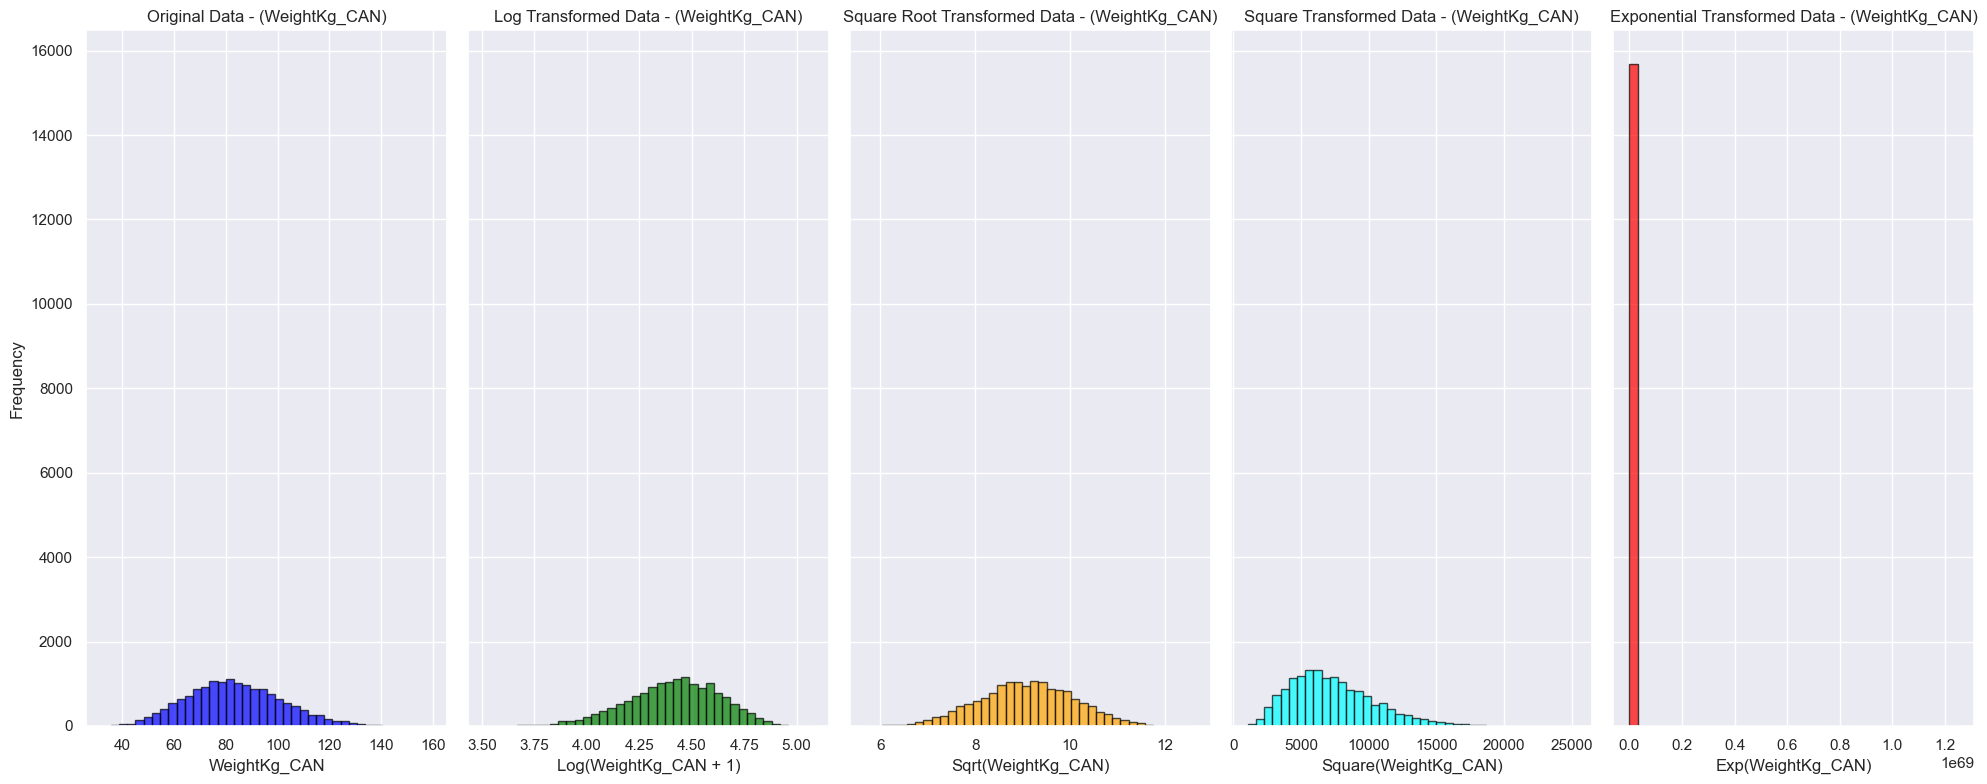

In [27]:
uv.transformPlots(df.WeightKg_CAN, txt='WeightKg_CAN', bins=40, figsize=(20, 8))

In [28]:
# imput NaN using mean: The median (50th percentile)
df.WeightKg_CAN = df.WeightKg_CAN.fillna(df.WeightKg_CAN.median())

In [29]:
# new features
df['WeightKg_CAT_CAN'] = pd.qcut(df['WeightKg_CAN'], q=4, labels=['WeightKg (Min-70)', 'WeightKg(71-83)', 'WeightKg(84-96)', 'WeightKg(97-Max)'])
df['WeightKg_CAT_DON'] = pd.qcut(df['WeightKg_DON'], q=4, labels=['WeightKg (Min-70)', 'WeightKg(70-81)', 'WeightKg(82-94)', 'WeightKg(95-Max)'])

# category datatype
df['WeightKg_CAT_CAN'] = df['WeightKg_CAT_CAN'].astype('category')
df['WeightKg_CAT_DON'] = df['WeightKg_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['WeightKg_CAT_CAN', 'WeightKg_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['WeightKg_CAT_DON'])
df_can = uf.insertIntoDataFrame(df_can, ['WeightKg_CAT_CAN'])

# add to list
removeCols.extend(features)

In [30]:
uf.categoryContingencySurvival(df, 'WeightKg_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
WeightKg (Min-70),1749.0,2183.0,3932.0,44.481180,55.518820
WeightKg(71-83),1872.0,2120.0,3992.0,46.893788,53.106212
WeightKg(84-96),1887.0,1999.0,3886.0,48.558929,51.441071
WeightKg(97-Max),1919.0,1972.0,3891.0,49.318941,50.681059
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


In [31]:
uf.categoryContingencySurvival(df, 'WeightKg_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
WeightKg (Min-70),1802.0,2246.0,4048.0,44.515810,55.484190
WeightKg(70-81),1799.0,2075.0,3874.0,46.437790,53.562210
WeightKg(82-94),1898.0,1957.0,3855.0,49.234760,50.765240
WeightKg(95-Max),1928.0,1996.0,3924.0,49.133537,50.866463
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


##### BMI

In [32]:
features = uf.getFeatureList(df, 'BMI_')

           count       mean       std        min        25%        50%        75%        max
BMI_CAN  15692.0  27.571814  4.884877  15.000000  24.000000  27.400000  31.200000  46.300000
BMI_DON  15699.0  27.735772  6.163295  14.351881  23.446757  26.643599  30.867315  74.360965

:::: NaN Count:
BMI_CAN    9
BMI_DON    2


In [33]:
# fillna
df['BMI_CAN'] = df['BMI_CAN'].fillna(df.WeightKg_CAN / (df.HeightCm_CAN * 0.01))
df['BMI_DON'] = df['BMI_DON'].fillna(df.WeightKg_DON / (df.HeightCm_DON * 0.01))

In [34]:
# create New feature
df['BMI_CAT_CAN'] = df['BMI_CAN'].apply(categorizeBMI)
df['BMI_CAT_DON'] = df['BMI_DON'].apply(categorizeBMI)

# category datatype
df['BMI_CAT_CAN'] = df['BMI_CAT_CAN'].astype('category')
df['BMI_CAT_DON'] = df['BMI_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['BMI_CAT_CAN', 'BMI_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['BMI_CAT_DON'])
df_can = uf.insertIntoDataFrame(df_can, ['BMI_CAT_CAN'])

# add to list
removeCols.extend(features)

In [35]:
uf.categoryContingencySurvival(df, 'BMI_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
Normal Weight,2098.0,2608.0,4706.0,44.581385,55.418615
Obesity,2501.0,2536.0,5037.0,49.652571,50.347429
Over Weight,2695.0,2959.0,5654.0,47.665370,52.334630
Under Weight,133.0,171.0,304.0,43.750000,56.250000
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


In [36]:
uf.categoryContingencySurvival(df, 'BMI_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Normal Weight,2491.0,2950.0,5441.0,45.782025,54.217975
Obesity,2275.0,2390.0,4665.0,48.767417,51.232583
Over Weight,2520.0,2777.0,5297.0,47.574099,52.425901
Under Weight,141.0,157.0,298.0,47.315436,52.684564
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


##### [BloodPH](https://www.ncbi.nlm.nih.gov/books/NBK507807/)
- The normal blood pH range is indeed between 7.35 and 7.45. This slightly alkaline range is crucial for the proper functioning of enzymes and other biochemical reactions in the body.
    - A blood pH below 7.35 is considered acidic, and it can lead to a condition called acidosis. Acidosis can disrupt cellular functions and impair organ systems, particularly the cardiovascular and respiratory systems.
    - A blood pH above 7.45 is considered alkaline, and it can lead to a condition called alkalosis. Alkalosis can cause symptoms such as muscle twitching, hand tremors, and confusion.

In [37]:
def categorizePH(value):
    """
    Define the function for mapping
    """
    if value < 7.35:
        return "Acidic"
    elif value > 7.45:
        return "Alkaline"        
    elif 7.35 <= value <= 7.45:
        return "Normal"
    else:
        return "Unknown"

In [38]:
features = uf.getFeatureList(df, 'BloodPH')

               count      mean       std   min   25%   50%   75%   max
BloodPH_DON  15642.0  7.418184  0.067317  5.57  7.38  7.42  7.46  7.93

:::: NaN Count:
BloodPH_DON    59


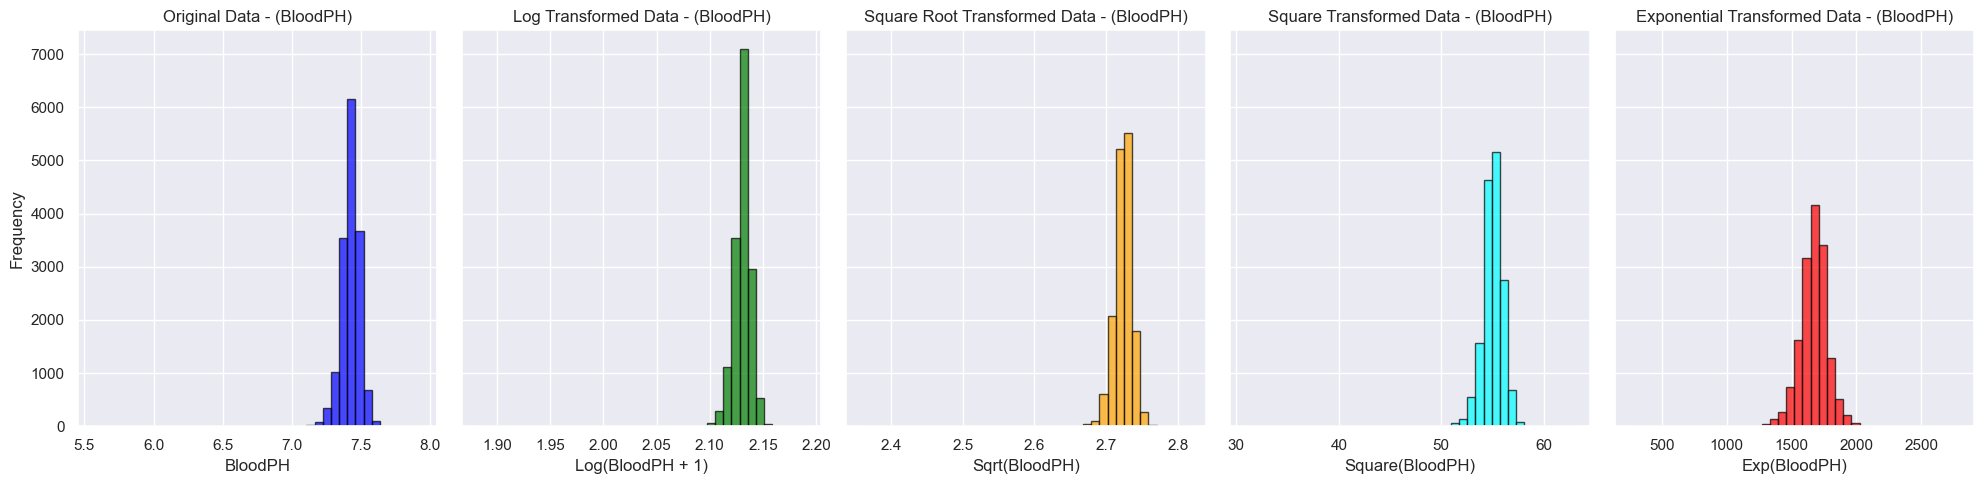

In [39]:
uv.transformPlots(df.BloodPH_DON, txt='BloodPH', bins=40, figsize=(20, 5))

In [40]:
# create New feature
df['BloodPH_CAT_DON'] = df['BloodPH_DON'].apply(categorizePH)

# category datatype
df['BloodPH_CAT_DON'] = df['BloodPH_CAT_DON'].astype('category')

# update DataFrame
df_nominal = uf.insertIntoDataFrame(df_nominal, ['BloodPH_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['BloodPH_CAT_DON'])

# add to list
removeCols.extend(features)

In [41]:
uf.categoryContingencySurvival(df, 'BloodPH_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Acidic,824.0,1057.0,1881.0,43.806486,56.193514
Alkaline,2127.0,2333.0,4460.0,47.690583,52.309417
Normal,4442.0,4859.0,9301.0,47.758306,52.241694
Unknown,34.0,25.0,59.0,57.627119,42.372881
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


##### [BloodUreaNitrogenLevel](https://redcliffelabs.com/myhealth/lab-test/urea-normal-range-causes-procedure-and-treatment/)
- Blood Urea Nitrogen (BUN) is a common blood test that measures the amount of urea nitrogen in the blood, which is a waste product formed from the breakdown of proteins.
    - Source report a range of 8 to 24 mg/dL for adult men and 6 to 21 mg/dL for adult women. 

In [42]:
def categorizeBUN(value, gender):
    """
    Define the function for mapping Blood Urea Nitrogen levels based on value and gender.
    """
    if (0.8 <= value <= 24 and gender == 'M') or (6 <= value <= 21 and gender == 'F'):
        return 'Normal'
    elif (value < 0.8 and gender == 'M') or (value < 6 and gender == 'F'):
        return "Low"
    elif (value > 24 and gender == 'M') or (value > 21 and gender == 'F'):
        return "High"
    else:
        return "Unknown"

In [43]:
features = uf.getFeatureList(df, 'BloodUreaNitrogenLevel_DON')

                              count       mean       std  min   25%   50%   75%    max
BloodUreaNitrogenLevel_DON  15662.0  26.926354  21.65986  1.0  14.0  20.0  32.0  250.0

:::: NaN Count:
BloodUreaNitrogenLevel_DON    39


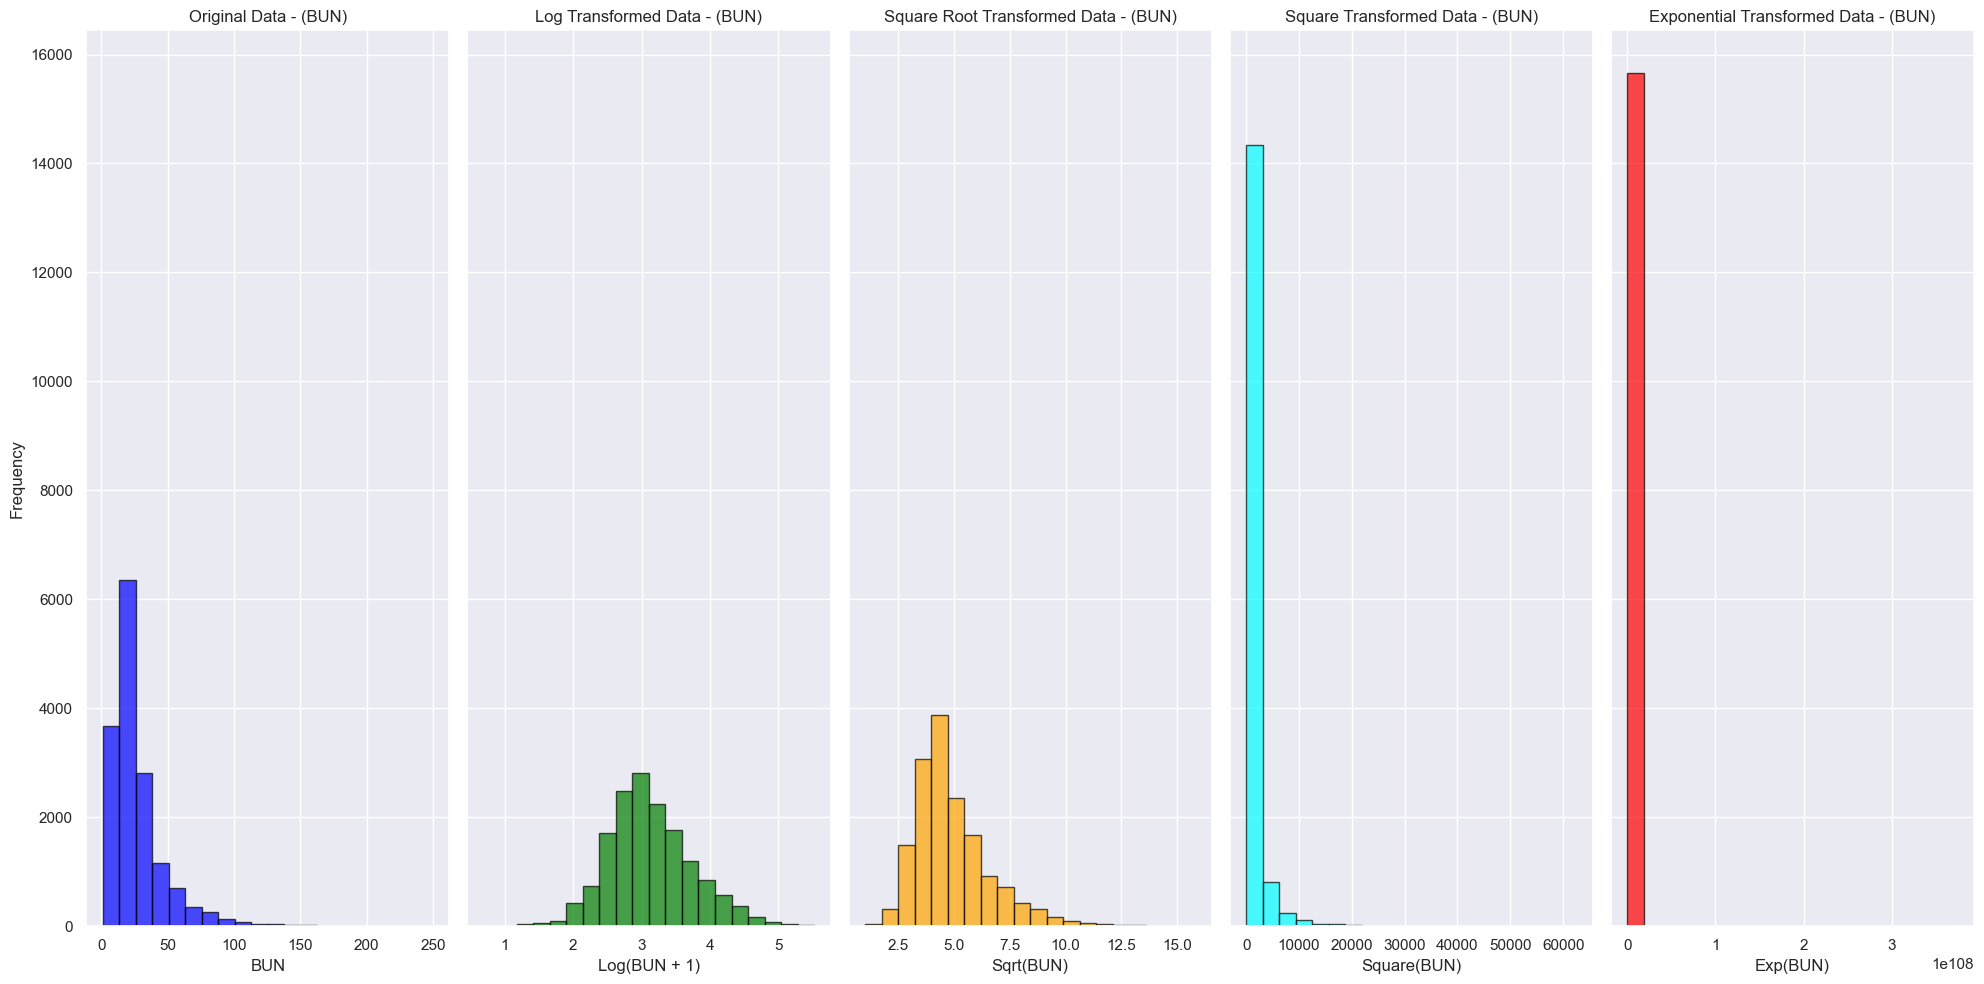

In [44]:
uv.transformPlots(df.BloodUreaNitrogenLevel_DON, txt='BUN', bins=20, figsize=(20, 10))

In [45]:
# create new feature
df['BloodUreaNitrogenLevel_CAT_DON'] = df.apply(lambda row: categorizeBUN(row['BloodUreaNitrogenLevel_DON'], row['Gender_DON']), axis=1)

# category datatype
df['BloodUreaNitrogenLevel_CAT_DON'] = df['BloodUreaNitrogenLevel_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['BloodUreaNitrogenLevel_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['BloodUreaNitrogenLevel_CAT_DON'])

# add to list
removeCols.extend(features)

In [46]:
uf.categoryContingencySurvival(df, 'BloodUreaNitrogenLevel_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
High,3249.0,3084.0,6333.0,51.302700,48.697300
Low,42.0,71.0,113.0,37.168142,62.831858
Normal,4109.0,5107.0,9216.0,44.585503,55.414497
Unknown,27.0,12.0,39.0,69.230769,30.769231
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


##### [CPRA_Peak_CAN & CPRA_Recent_CAN](https://www.ahajournals.org/doi/full/10.1161/CIR.0000000000000598)
- The Panel Reactive Antibody (PRA), or Calculated Panel Reactive Antibody (cPRA), is a metric used in organ transplantation.
    - cPRA = 0%: The recipient is unlikely to have antibodies against most potential donors and is considered less "sensitized," meaning they have a broad range of compatible donor options.
    - Higher cPRA (e.g., 80%+): The recipient has a high level of sensitization, reducing the likelihood of finding compatible donors.
    - cPRA = 100%: The recipient has antibodies against nearly all potential donors, making finding a compatible organ highly challenging.
- CPRA values typically range from 0% to 100%.
    - The results are often grouped into categories, such as:
        - 0%       No Sensitization
        - 1-20%    Low Sensitization
        - 21-50%   Some Sensitization
        - 51-80%   Moderate Sensitization
        - 81-98%   High Sensitization
        - 99-100%  Extreme Sensitization
    - Higher CPRA values indicate a higher degree of sensitization:
    - CPRA of 80-100% is considered highly sensitized
    - CPRA > 98% may receive extra priority in organ allocation system

In [47]:
def categorizeCPRA(value):
    """
    Define the function for mapping
    """
    if value <= 25:
        return "Normal Sensitization"
    elif value > 25:
        return "High Sensitization"
    else:
        return "Unknown"

In [48]:
features = uf.getFeatureList(df, '^CPRA')

                   count       mean        std  min  25%  50%   75%    max
CPRA_Peak_CAN    11999.0  14.944579  26.605557  0.0  0.0  0.0  19.0  100.0
CPRA_Recent_CAN  12013.0  11.254558  23.442261  0.0  0.0  0.0   7.0  100.0

:::: NaN Count:
CPRA_Peak_CAN      3702
CPRA_Recent_CAN    3688


In [49]:
df[features].corr()

,CPRA_Peak_CAN,CPRA_Recent_CAN
CPRA_Peak_CAN,1.000000,0.901139
CPRA_Recent_CAN,0.901139,1.000000


In [50]:
# create new feature
df['PanelReactiveAntibody_CPRA_Mean_CAN'] = df[features].mean(axis=1)

# update PanelReactiveAntibody_CPRA_CAN with non-NaN values from CPRA_Peak_CAN and CPRA_Recent_CAN
df['PanelReactiveAntibody_CPRA_Mean_CAN'] = df['PanelReactiveAntibody_CPRA_Mean_CAN'].fillna(df['CPRA_Peak_CAN'].combine_first(df['CPRA_Recent_CAN']))

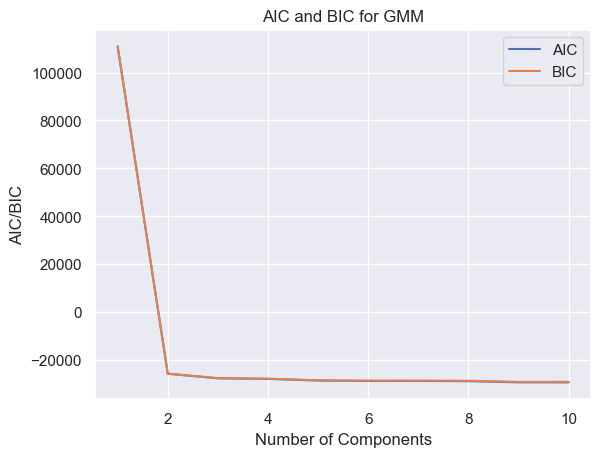

In [51]:
uif.GaussianMixtureBinning(df, ['PanelReactiveAntibody_CPRA_Mean_CAN'], RANDOM_STATE)

In [52]:
# convert to categorical variable
df['PanelReactiveAntibody_CPRA_CAT_CAN'] = df['PanelReactiveAntibody_CPRA_Mean_CAN'].apply(categorizeCPRA)

# category datatype
df['PanelReactiveAntibody_CPRA_CAT_CAN'] = df['PanelReactiveAntibody_CPRA_CAT_CAN'].astype('category')

# update dataframe
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['PanelReactiveAntibody_CPRA_CAT_CAN'])
df_can = uf.insertIntoDataFrame(df_can, ['PanelReactiveAntibody_CPRA_CAT_CAN'])

# add to list
removeCols.extend(features)
removeCols.extend(['PanelReactiveAntibody_CPRA_Mean_CAN'])

In [53]:
uf.categoryContingencySurvival(df, 'PanelReactiveAntibody_CPRA_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
High Sensitization,1023.0,1283.0,2306.0,44.362533,55.637467
Normal Sensitization,4499.0,5213.0,9712.0,46.324135,53.675865
Unknown,1905.0,1778.0,3683.0,51.724138,48.275862
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


##### [Creatinine](https://johnshopkinshealthcare.staywellsolutionsonline.com/BreatheEasy/167,creatinine_serum)
- Creatinine is a waste product that forms when creatine, a substance found in your muscles, breaks down. It's usually filtered out of the blood by the kidneys and excreted in urine. Measuring creatinine levels in the blood can help assess kidney function.
    - Normal
        - 0.7 to 1.3 mg/dL for adult males
        - 0.5 to 1.1 mg/dL for adult females
- High creatinine levels can indicate kidney dysfunction, dehydration, or other conditions affecting the kidneys. If you have concerns about your creatinine levels, it's best to consult with a healthcare professional for proper evaluation and guidance.

In [54]:
def categorizeCR(value, gender):
    """
    Define the function for mapping creatinine levels based on value and gender.
    """
    if (0.7 <= value <= 1.3 and gender == 'M') or (0.5 <= value <= 1.1 and gender == 'F'):
        return 'Normal'
    elif (value < 0.7 and gender == 'M') or (value < 0.5 and gender == 'F'):
        return "Low"
    elif (value > 1.3 and gender == 'M') or (value > 1.1 and gender == 'F'):
        return "Elevated"
    else:
        return "Unknown"

In [55]:
features = uf.getFeatureList(df, 'Creatinine')

                              count      mean       std   min   25%   50%   75%   max
CreatinineRegistration_CAN  15643.0  1.384497  1.011897  0.08  0.95  1.20  1.50  24.0
CreatinineTransplant_CAN    15649.0  1.380340  1.062572  0.06  0.94  1.19  1.50  37.0
Creatinine_DON              15662.0  1.576714  1.668723  0.04  0.75  1.00  1.53  19.0

:::: NaN Count:
CreatinineRegistration_CAN    58
CreatinineTransplant_CAN      52
Creatinine_DON                39


In [56]:
df.groupby('Gender_DON', observed=False)['Creatinine_DON'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender_DON,,,,,,,,
F,4636.0,1.373911,1.445579,0.04,0.63,0.86,1.36,15.0
M,11026.0,1.661984,1.747135,0.05,0.80,1.07,1.60,19.0


In [57]:
# create new feature
df['Creatinine_Mean_CAN'] = df[['CreatinineRegistration_CAN','CreatinineTransplant_CAN']].mean(axis=1)

# update PanelReactiveAntibody_CPRA_CAN with non-NaN values from CreatinineRegistration_CAN and CreatinineTransplant_CAN
df['Creatinine_Mean_CAN'] = df['Creatinine_Mean_CAN'].fillna(df['CreatinineRegistration_CAN'].combine_first(df['CreatinineTransplant_CAN']))

In [58]:
# create new feature
df['Creatinine_CAT_CAN'] = df.apply(lambda row: categorizeCR(row['Creatinine_Mean_CAN'], row['Gender_CAN']), axis=1)
df['Creatinine_CAT_DON'] = df.apply(lambda row: categorizeCR(row['Creatinine_DON'], row['Gender_DON']), axis=1)
                                    
# category datatype
df['Creatinine_CAT_CAN'] = df['Creatinine_CAT_CAN'].astype('category')

# update dataframe
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['Creatinine_CAT_CAN', 'Creatinine_CAT_DON'])
df_can = uf.insertIntoDataFrame(df_can, ['Creatinine_CAT_CAN'])
df_don = uf.insertIntoDataFrame(df_don, ['Creatinine_CAT_DON'])

# add to list
removeCols.extend(features)
removeCols.extend(['Creatinine_Mean_CAN'])                                  

In [59]:
uf.categoryContingencySurvival(df, 'Creatinine_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
Elevated,3378.0,3452.0,6830.0,49.458272,50.541728
Low,110.0,119.0,229.0,48.034934,51.965066
Normal,3918.0,4703.0,8621.0,45.447164,54.552836
Unknown,21.0,0.0,21.0,100.000000,0.000000
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


In [60]:
uf.categoryContingencySurvival(df, 'Creatinine_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Elevated,2567.0,2676.0,5243.0,48.960519,51.039481
Low,832.0,864.0,1696.0,49.056604,50.943396
Normal,4001.0,4722.0,8723.0,45.867248,54.132752
Unknown,27.0,12.0,39.0,69.230769,30.769231
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


##### DistanceFromDonorHospitaltoTXCenter

In [61]:
features = uf.getFeatureList(df, 'DistanceFromDonorHospitaltoTXCenter')

                                       count        mean         std  min   25%    50%    75%     max
DistanceFromDonorHospitaltoTXCenter  15701.0  225.503216  226.686689  0.0  37.0  167.0  354.0  2215.0

:::: NaN Count:
DistanceFromDonorHospitaltoTXCenter    0


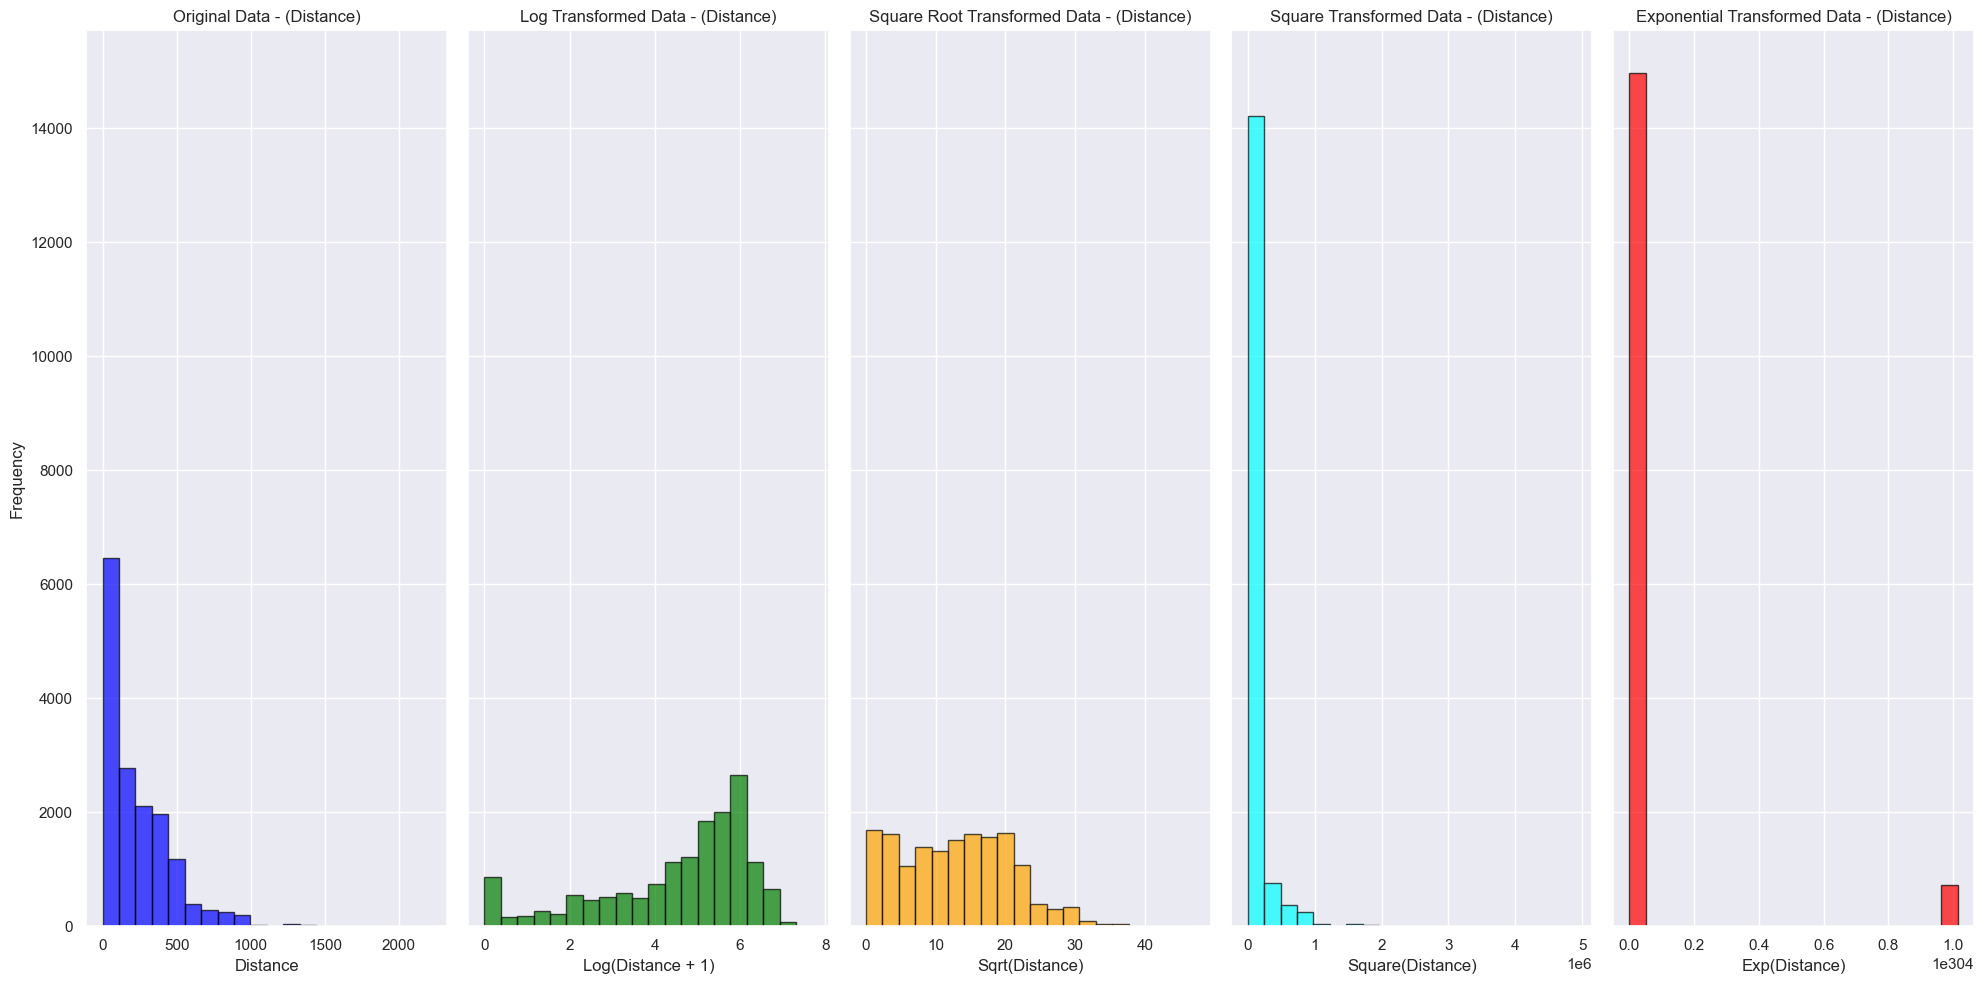

In [62]:
uv.transformPlots(df.DistanceFromDonorHospitaltoTXCenter, txt='Distance', bins=20, figsize=(20, 10))

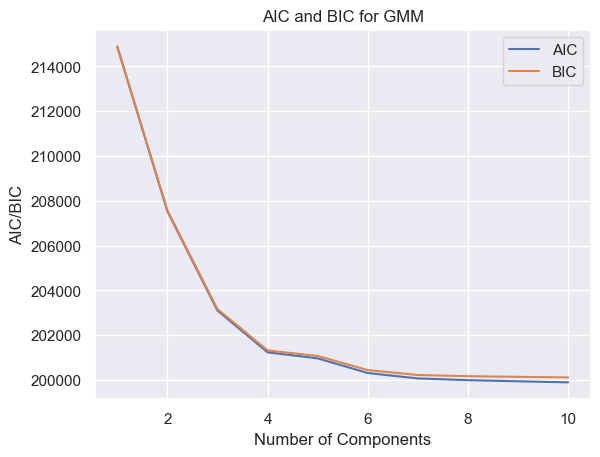

In [63]:
uif.GaussianMixtureBinning(df, ['DistanceFromDonorHospitaltoTXCenter'], RANDOM_STATE)

In [64]:
# use quartile bin
df['DistanceFromDonorHospitaltoTXCenter_CAT'] = pd.qcut(df['DistanceFromDonorHospitaltoTXCenter'], q=4, labels=['Distance(Min-37)', 'Distance(38-167)', 'Distance(167-354)', 'Distance(354-Max)'])

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['DistanceFromDonorHospitaltoTXCenter_CAT'])
df_both = uf.insertIntoDataFrame(df_both, ['DistanceFromDonorHospitaltoTXCenter_CAT'])

# add to list
removeCols.extend(features)

In [65]:
uf.categoryContingencySurvival(df, 'DistanceFromDonorHospitaltoTXCenter_CAT')

Survival,Dead,Living,Row Total,Dead %,Living %
Distance(Min-37),1247.0,2707.0,3954.0,31.537683,68.462317
Distance(38-167),1783.0,2127.0,3910.0,45.601023,54.398977
Distance(167-354),2221.0,1706.0,3927.0,56.557168,43.442832
Distance(354-Max),2176.0,1734.0,3910.0,55.652174,44.347826
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


##### [Hematocrit_DON](https://www.mountsinai.org/health-library/tests/hematocrit)
- Hematocrit is a blood test that measures how much of a person's blood is made up of red blood cells as opposed to plasma.
    - Normal results vary, but in general they are:
        - Male: 40.7% to 50.3%
        - Female: 36.1% to 44.3% 

In [66]:
def categorizeH(value, gender):
    """
    Define the function for mapping Hematocrit levels based on value and gender.
    """
    if (40.7 <= value <= 50.3 and gender == 'M') or (36.1 <= value <= 44.3 and gender == 'F'):
        return 'Normal'
    elif (value < 40.7 and gender == 'M') or (value < 36.1 and gender == 'F'):
        return "Low"
    elif (value > 50.3 and gender == 'M') or (value > 44.3 and gender == 'F'):
        return "Elevated"
    else:
        return "Unknown"

In [67]:
features = uf.getFeatureList(df, 'Hematocrit')

                  count       mean       std  min   25%   50%   75%   max
Hematocrit_DON  15662.0  28.125073  4.901878  2.5  24.7  27.6  31.0  75.0

:::: NaN Count:
Hematocrit_DON    39


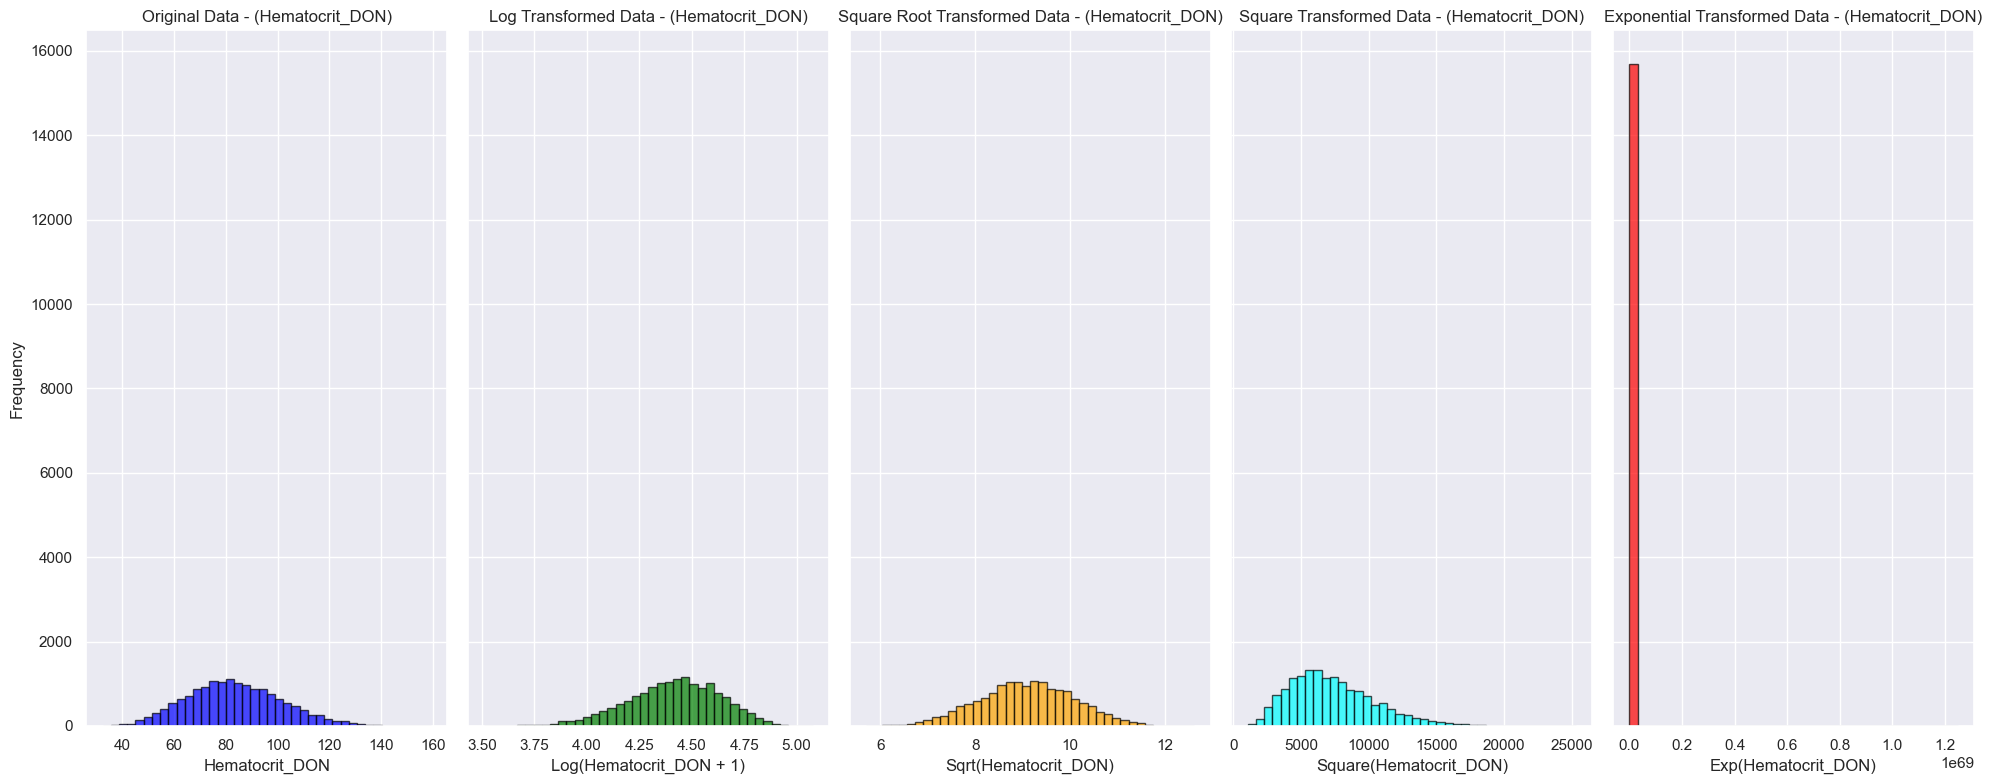

In [68]:
uv.transformPlots(df.WeightKg_CAN, txt='Hematocrit_DON', bins=40, figsize=(20, 8))

In [69]:
# imput NaN using median: The median (50th percentile)
df.Hematocrit_DON = df.Hematocrit_DON.fillna(df.Hematocrit_DON.median())

In [70]:
# create new feature
df['Hematocrit_CAT_DON'] = df.apply(lambda row: categorizeH(row['Hematocrit_DON'], row['Gender_DON']), axis=1)
                                    
# category datatype
df['Hematocrit_CAT_DON'] = df['Hematocrit_CAT_DON'].astype('category')

# update dataframe
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['Hematocrit_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['Hematocrit_CAT_DON'])

# add to list
removeCols.extend(features)

In [71]:
uf.categoryContingencySurvival(df, 'Hematocrit_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Elevated,7.0,10.0,17.0,41.176471,58.823529
Low,7286.0,8090.0,15376.0,47.385536,52.614464
Normal,134.0,174.0,308.0,43.506494,56.493506
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


##### Hemodynamics
- [CO (Cardiac Output)](https://www.ncbi.nlm.nih.gov/books/NBK470455/#:~:text=Cardiac%20output%20in%20humans%20is,to%20100%20times%20each%20minute.):
    - Definition: Similar to the registration phase, it measures the heart's output during the transplant phase.
    - Importance: Critical for ensuring adequate perfusion during surgery.
    - Cardiac output in humans is generally 5-6 L/min
- [PA_DIA (Pulmonary Artery Diastolic Pressure)](https://www.ncbi.nlm.nih.gov/books/NBK209987/):
    - Definition: Monitored to assess right heart function and pulmonary circulation during transplant.
- [PA_MN (Pulmonary Artery Mean Pressure)](https://www.ncbi.nlm.nih.gov/books/NBK209987/):
    - Definition: Helps in evaluating pulmonary hypertension and right ventricular function.
    - Severe pulmonary hypertension artery pressure of 40 mm Hg or greater
    - Moderate pulmonary hypertension artery pressure between 25 and 39 mm Hg
    - Normal pulmonary artery pressure between 11 and 25 mm Hg
- [PCW (Pulmonary Capillary Wedge Pressure)](https://pubmed.ncbi.nlm.nih.gov/24268673/):
    - Definition: Used to monitor left ventricular function and fluid status during transplant.
- [SYS (Systemic Arterial Pressure)](https://www.ncbi.nlm.nih.gov/books/NBK538509/):
    - Definition: Monitored to ensure stable blood pressure and perfusion during transplant.

In [72]:
def categorizeCO(value):
    """
    Define the function for mapping Hemodynamics levels.
    """
    if value < 5:
        return "Low"
    elif value > 6:
        return "High"    
    if 5 <= value <= 6:
        return "Normal"
    else:
        return "Unknown"

def categorizePA(value):
    """
    Define the function for mapping Hemodynamics levels.
    """
    if value < 11:
        return 'Low'
    elif 11 <= value <= 25:
        return "Normal"
    elif 25 <= value <= 40:
        return "High"
    elif value >= 40:
        return "Extreme"
    else:
        return "Unknown"

In [73]:
features = uf.getFeatureList(df, 'Hemodynamics')

                                       count       mean        std   min    25%    50%   75%    max
HemodynamicsRegistration_CO_CAN      14886.0   4.241363   1.326859  0.45   3.31   4.10   5.0   14.4
HemodynamicsRegistration_PA_DIA_CAN  15165.0  20.199934   8.671227  0.00  14.00  20.00  26.0   91.0
HemodynamicsRegistration_PA_MN_CAN   15085.0  28.153722  10.152069  0.00  20.00  28.00  35.0   96.0
HemodynamicsRegistration_PCW_CAN     14328.0  18.757503   8.793816  0.00  12.00  18.00  25.0   50.0
HemodynamicsRegistration_SYS_CAN     15176.0  41.306603  14.186014  0.00  31.00  40.00  51.0  123.0
HemodynamicsTransplant_CO_CAN        14972.0   4.498686   1.455921  0.20   3.50   4.32   5.3   15.0
HemodynamicsTransplant_PA_DIA_CAN    15223.0  19.209354   8.482090  0.00  13.00  18.00  25.0  110.0
HemodynamicsTransplant_PA_MN_CAN     15082.0  26.998952   9.887450  0.00  20.00  26.00  34.0  110.0
HemodynamicsTransplant_PCW_CAN       14522.0  17.779798   8.661288  0.00  11.00  17.00  24.0   50.0


In [74]:
# mean (Registration & Transplant)
df['Hemodynamics_Mean_CO_CAN'] = df[['HemodynamicsRegistration_CO_CAN', 'HemodynamicsTransplant_CO_CAN']].mean(axis=1)
df['Hemodynamics_Mean_PA_DIA_CAN'] = df[['HemodynamicsRegistration_PA_DIA_CAN', 'HemodynamicsTransplant_PA_DIA_CAN']].mean(axis=1)
df['Hemodynamics_Mean_PA_MN_CAN'] = df[['HemodynamicsRegistration_PA_MN_CAN', 'HemodynamicsTransplant_PA_MN_CAN']].mean(axis=1)
df['Hemodynamics_Mean_PCW_CAN'] = df[['HemodynamicsRegistration_PCW_CAN', 'HemodynamicsTransplant_PCW_CAN']].mean(axis=1)
df['Hemodynamics_Mean_SYS_CAN'] = df[['HemodynamicsRegistration_SYS_CAN', 'HemodynamicsTransplant_SYS_CAN']].mean(axis=1)

# update Hemodynamics_Mean with non-NaN values from Registration and Transplant
df['Hemodynamics_Mean_CO_CAN'] = df['Hemodynamics_Mean_CO_CAN'].fillna(df['HemodynamicsRegistration_CO_CAN'].combine_first(df['HemodynamicsTransplant_CO_CAN']))
df['Hemodynamics_Mean_PA_DIA_CAN'] = df['Hemodynamics_Mean_PA_DIA_CAN'].fillna(df['HemodynamicsRegistration_PA_DIA_CAN'].combine_first(df['HemodynamicsTransplant_PA_DIA_CAN']))
df['Hemodynamics_Mean_PA_MN_CAN'] = df['Hemodynamics_Mean_PA_MN_CAN'].fillna(df['HemodynamicsRegistration_PA_MN_CAN'].combine_first(df['HemodynamicsTransplant_PA_MN_CAN']))
df['Hemodynamics_Mean_PCW_CAN'] = df['Hemodynamics_Mean_PCW_CAN'].fillna(df['HemodynamicsRegistration_PCW_CAN'].combine_first(df['HemodynamicsTransplant_PCW_CAN']))
df['Hemodynamics_Mean_SYS_CAN'] = df['Hemodynamics_Mean_SYS_CAN'].fillna(df['HemodynamicsRegistration_SYS_CAN'].combine_first(df['HemodynamicsTransplant_SYS_CAN']))

In [75]:
featuresMean = uf.getFeatureList(df, 'Hemodynamics_Mean')

                                count       mean        std   min    25%    50%     75%   max
Hemodynamics_Mean_CO_CAN      15376.0   4.374810   1.238772  0.98   3.51   4.25   5.075  15.0
Hemodynamics_Mean_PA_DIA_CAN  15455.0  19.675283   7.613936  0.00  14.00  19.50  25.000  60.5
Hemodynamics_Mean_PA_MN_CAN   15458.0  27.534675   9.028041  0.00  21.00  27.00  34.000  75.0
Hemodynamics_Mean_PCW_CAN     15168.0  18.318174   7.942272  0.00  12.00  18.00  24.000  50.0
Hemodynamics_Mean_SYS_CAN     15459.0  40.410855  12.604675  1.00  31.00  40.00  49.000  98.0

:::: NaN Count:
Hemodynamics_Mean_CO_CAN        325
Hemodynamics_Mean_PA_DIA_CAN    246
Hemodynamics_Mean_PA_MN_CAN     243
Hemodynamics_Mean_PCW_CAN       533
Hemodynamics_Mean_SYS_CAN       242


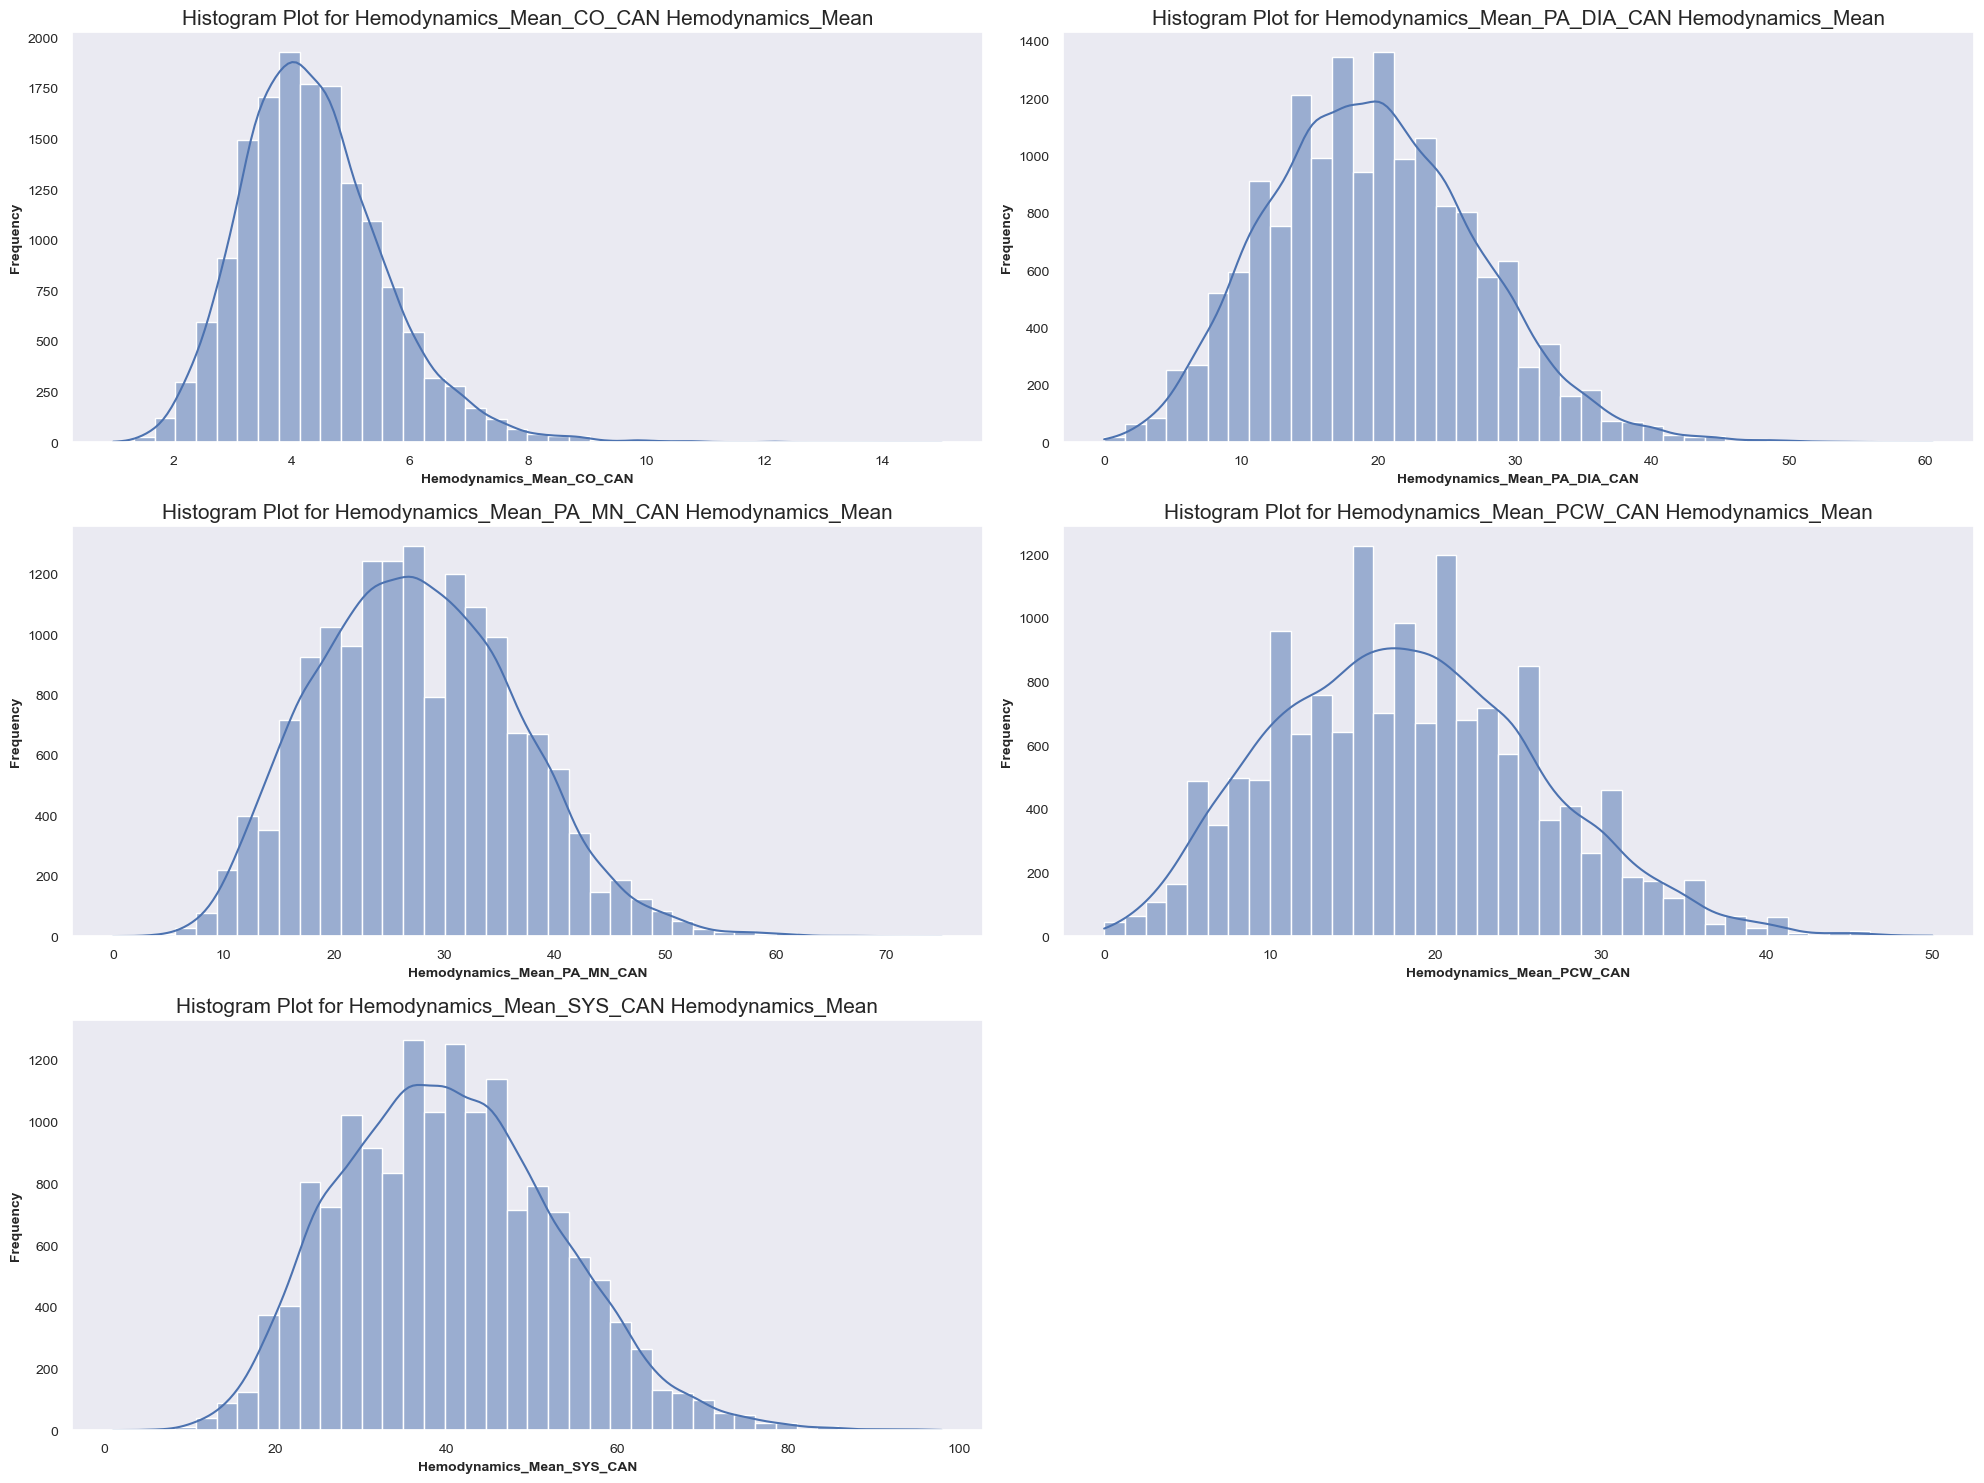

In [76]:
uv.histogramPlot(df, featuresMean, bins=40, txt='Hemodynamics_Mean')

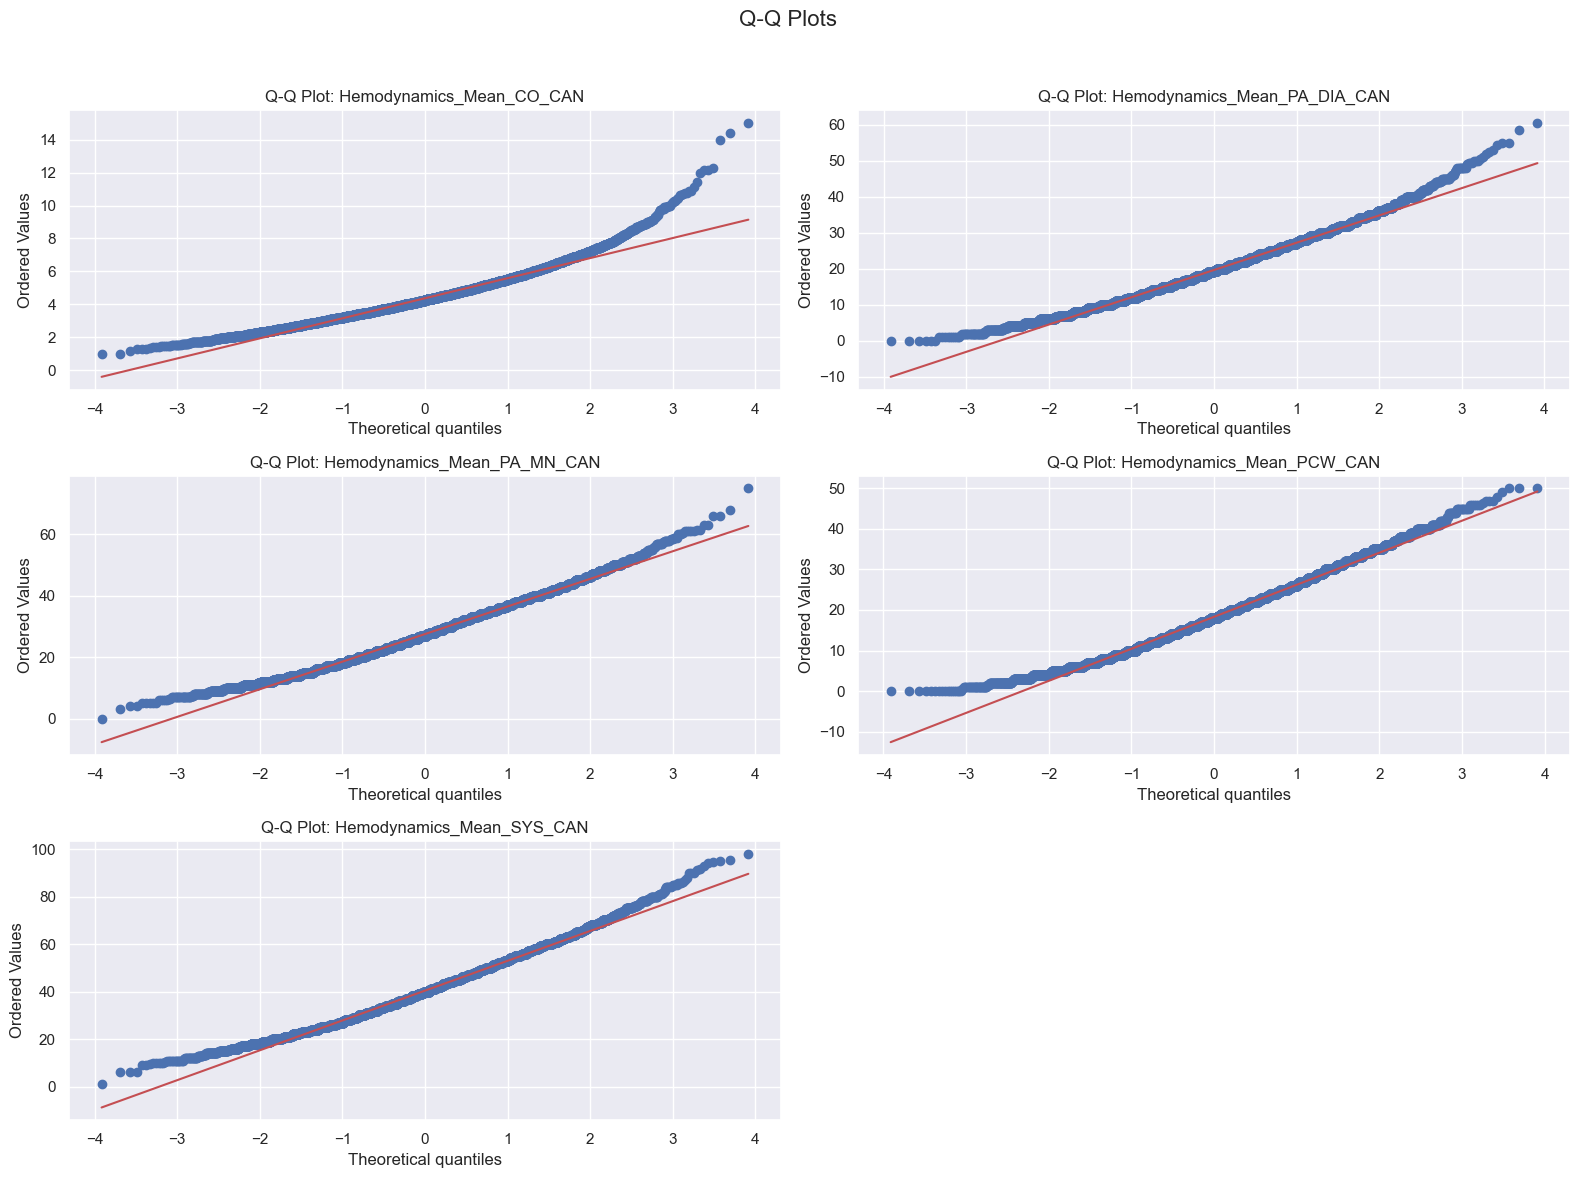

In [77]:
uv.plotQQ(df, featuresMean)

##### Parameters related to pulmonary and systemic pressures (PA_DIA, PA_MN, PCW, SYS) are strongly positively correlated. This means that when one of these pressures increases, the others will also increase; therefore, use PA_MN ONLY.

In [78]:
df[featuresMean].corr()

,Hemodynamics_Mean_CO_CAN,Hemodynamics_Mean_PA_DIA_CAN,Hemodynamics_Mean_PA_MN_CAN,Hemodynamics_Mean_PCW_CAN,Hemodynamics_Mean_SYS_CAN
Hemodynamics_Mean_CO_CAN,1.000000,-0.198275,-0.164618,-0.203329,-0.127083
Hemodynamics_Mean_PA_DIA_CAN,-0.198275,1.000000,0.910376,0.827962,0.804180
Hemodynamics_Mean_PA_MN_CAN,-0.164618,0.910376,1.000000,0.836932,0.925241
Hemodynamics_Mean_PCW_CAN,-0.203329,0.827962,0.836932,1.000000,0.759595
Hemodynamics_Mean_SYS_CAN,-0.127083,0.804180,0.925241,0.759595,1.000000


In [79]:
# imput NaN using median: The median (50th percentile)
df.Hemodynamics_Mean_PA_MN_CAN = df.Hemodynamics_Mean_PA_MN_CAN.fillna(df.Hemodynamics_Mean_PA_MN_CAN.median())
df.Hemodynamics_Mean_CO_CAN = df.Hemodynamics_Mean_CO_CAN.fillna(df.Hemodynamics_Mean_CO_CAN.median())

In [80]:
# imput NaN using median: The median (50th percentile)
df.Hemodynamics_Mean_PA_MN_CAN = df.Hemodynamics_Mean_PA_MN_CAN.fillna(df.Hemodynamics_Mean_PA_MN_CAN.median())
df.Hemodynamics_Mean_CO_CAN = df.Hemodynamics_Mean_CO_CAN.fillna(df.Hemodynamics_Mean_CO_CAN.median())

# create New feature
df['Hemodynamics_Mean_PA_MN_CAT_CAN'] = df['Hemodynamics_Mean_PA_MN_CAN'].apply(categorizePA)
df['Hemodynamics_Mean_CO_CAT_CAN'] = df['Hemodynamics_Mean_CO_CAN'].apply(categorizeCO)

# category datatype
df['Hemodynamics_Mean_PA_MN_CAT_CAN'] = df['Hemodynamics_Mean_PA_MN_CAT_CAN'].astype('category')
df['Hemodynamics_Mean_CO_CAT_CAN'] = df['Hemodynamics_Mean_CO_CAT_CAN'].astype('category')

# update dataframe
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['Hemodynamics_Mean_PA_MN_CAT_CAN', 'Hemodynamics_Mean_CO_CAT_CAN'])
df_can = uf.insertIntoDataFrame(df_can, ['Hemodynamics_Mean_PA_MN_CAT_CAN', 'Hemodynamics_Mean_CO_CAT_CAN'])

# combine
features.extend(featuresMean)
# add to list
removeCols.extend(features)

In [81]:
uf.categoryContingencySurvival(df, 'Hemodynamics_Mean_PA_MN_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
Extreme,653.0,576.0,1229.0,53.132628,46.867372
High,3729.0,4173.0,7902.0,47.190585,52.809415
Low,100.0,116.0,216.0,46.296296,53.703704
Normal,2945.0,3409.0,6354.0,46.348757,53.651243
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


In [82]:
uf.categoryContingencySurvival(df, 'Hemodynamics_Mean_CO_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
High,709.0,715.0,1424.0,49.789326,50.210674
Low,5428.0,6100.0,11528.0,47.085357,52.914643
Normal,1290.0,1459.0,2749.0,46.926155,53.073845
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


##### [IschemicTimeHour](https://www.jhltonline.org/article/S1053-2498(23)01819-3/fulltext)
-  The maximum time it can be without blood supply before significant damage occurs, is around 4 hours when preserved in cold storage for transplantation; exceeding this timeframe significantly increases the risk of complications and poor outcomes after transplant. 

In [83]:
def categoryISC(value):
    if value <= 2.6:
        return 'Low'
    elif 2.6 <= value <= 4:
        return 'Normal'
    else:
        return 'High'

In [84]:
features = uf.getFeatureList(df, 'IschemicTimeHour_DON')

                        count      mean       std  min  25%  50%  75%   max
IschemicTimeHour_DON  15581.0  3.293036  1.087226  0.3  2.6  3.3  3.9  12.0

:::: NaN Count:
IschemicTimeHour_DON    120


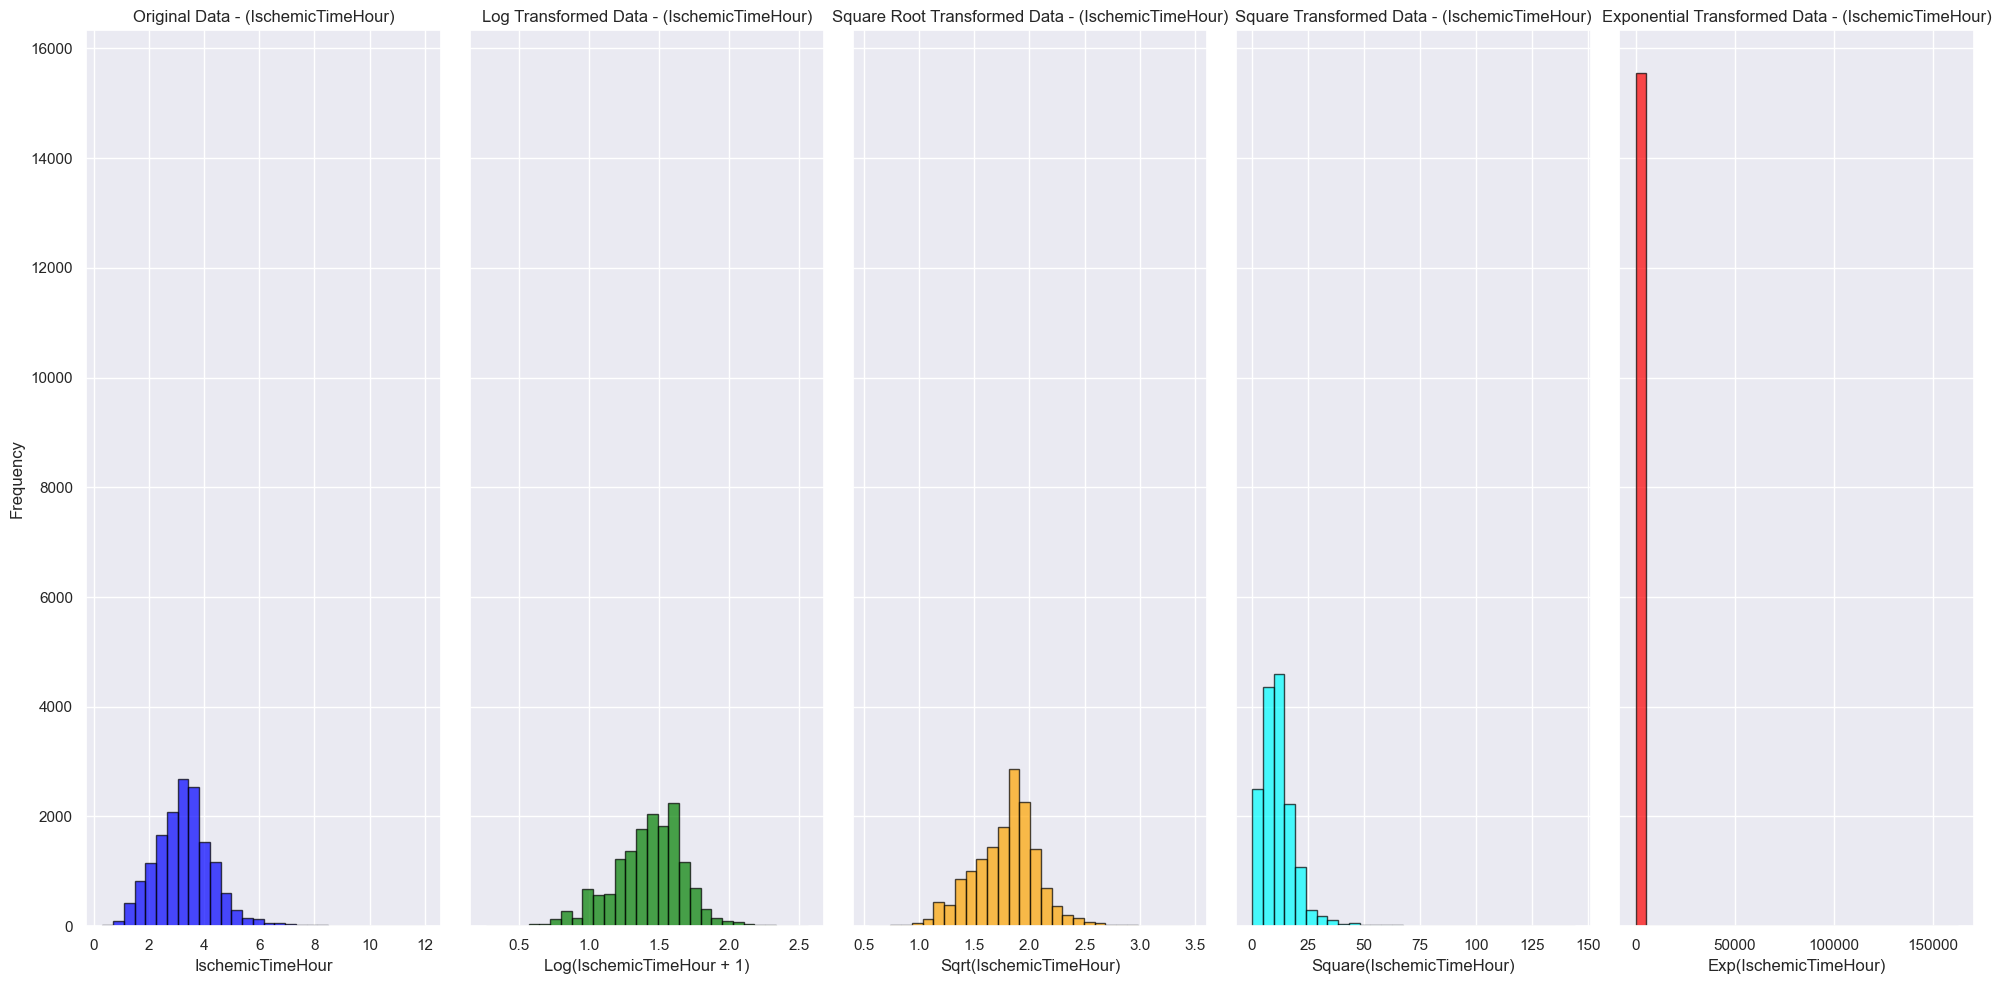

In [85]:
uv.transformPlots(df.IschemicTimeHour_DON, txt='IschemicTimeHour', bins=30, figsize=(20, 10))

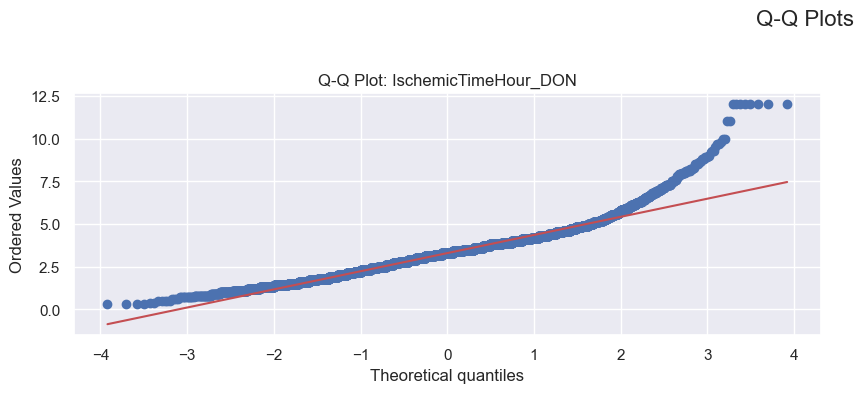

In [86]:
uv.plotQQ(df, features)

In [87]:
# imput NaN using median: The median (50th percentile)
df.IschemicTimeHour_DON = df.IschemicTimeHour_DON.fillna(df.IschemicTimeHour_DON.median())

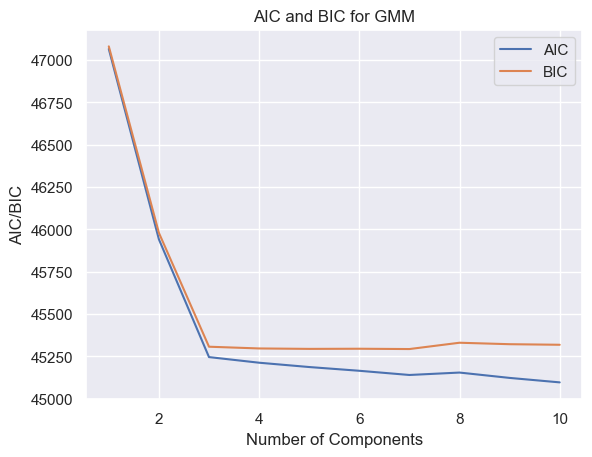

In [88]:
uif.GaussianMixtureBinning(df, ['IschemicTimeHour_DON'], RANDOM_STATE)

In [89]:
# create New feature
df['IschemicTimeHour_CAT'] = df['IschemicTimeHour_DON'].apply(categoryISC)
# category datatype
df['IschemicTimeHour_CAT'] = df['IschemicTimeHour_CAT'].astype('category')

# update dataframe
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['IschemicTimeHour_CAT'])
df_both = uf.insertIntoDataFrame(df_both, ['IschemicTimeHour_CAT'])

# add to list
removeCols.extend(features)

In [90]:
uf.categoryContingencySurvival(df, 'IschemicTimeHour_CAT')

Survival,Dead,Living,Row Total,Dead %,Living %
High,1704.0,1323.0,3027.0,56.293360,43.706640
Low,1463.0,2694.0,4157.0,35.193649,64.806351
Normal,4260.0,4257.0,8517.0,50.017612,49.982388
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


##### [LV_EjectionFractionPercent](https://my.clevelandclinic.org/health/articles/16950-ejection-fraction)
- Ejection fraction measures your heart’s ability to pump oxygen-rich blood out to your body. In a healthy heart, the fraction is a higher number. A low number means that your heart has difficulty keeping up with your body’s needs.
    - Male:
        - Nomal: 52% to 72%
        - Mildly Abnormal: 41% to 51%
        - Moderately Abnormal: 30% to 40%
        - Severely Abnormal: Below 30% 
    - Female:
        - Nomal: 54% to 74%
        - Mildly Abnormal: 41% to 53%
        - Moderately Abnormal: 30% to 40%
        - Severely Abnormal: Below 30% 

In [91]:
def categorizeLV(value, gender):
    """
    Define the function for mapping LV Ejection Fraction Percent based on value and gender.
    """
    if (52 <= value <= 72 and gender == 'M') or (54 <= value <= 74 and gender == 'F'):
        return 'Normal'
    elif (41 <= value <= 52 and gender == 'M') or (41 <= value <= 54 and gender == 'F'):
        return "Mildly Abnormal"
    elif (30 <= value <= 41) and gender in ['M', 'F']:
        return "Moderately Abnormal"
    elif (value < 30) and gender in ['M', 'F']:
        return "Severely Abnormal"
    elif (value > 72 and gender == 'M') or (value > 74 and gender == 'F'):
        return 'Below Normal'
    else:
        return "Unknown"

In [92]:
features = uf.getFeatureList(df, 'LV_EjectionFractionPercent_DON')

                                  count       mean       std   min   25%   50%   75%   max
LV_EjectionFractionPercent_DON  15686.0  61.609115  6.584061  10.0  56.0  60.0  65.0  91.0

:::: NaN Count:
LV_EjectionFractionPercent_DON    15


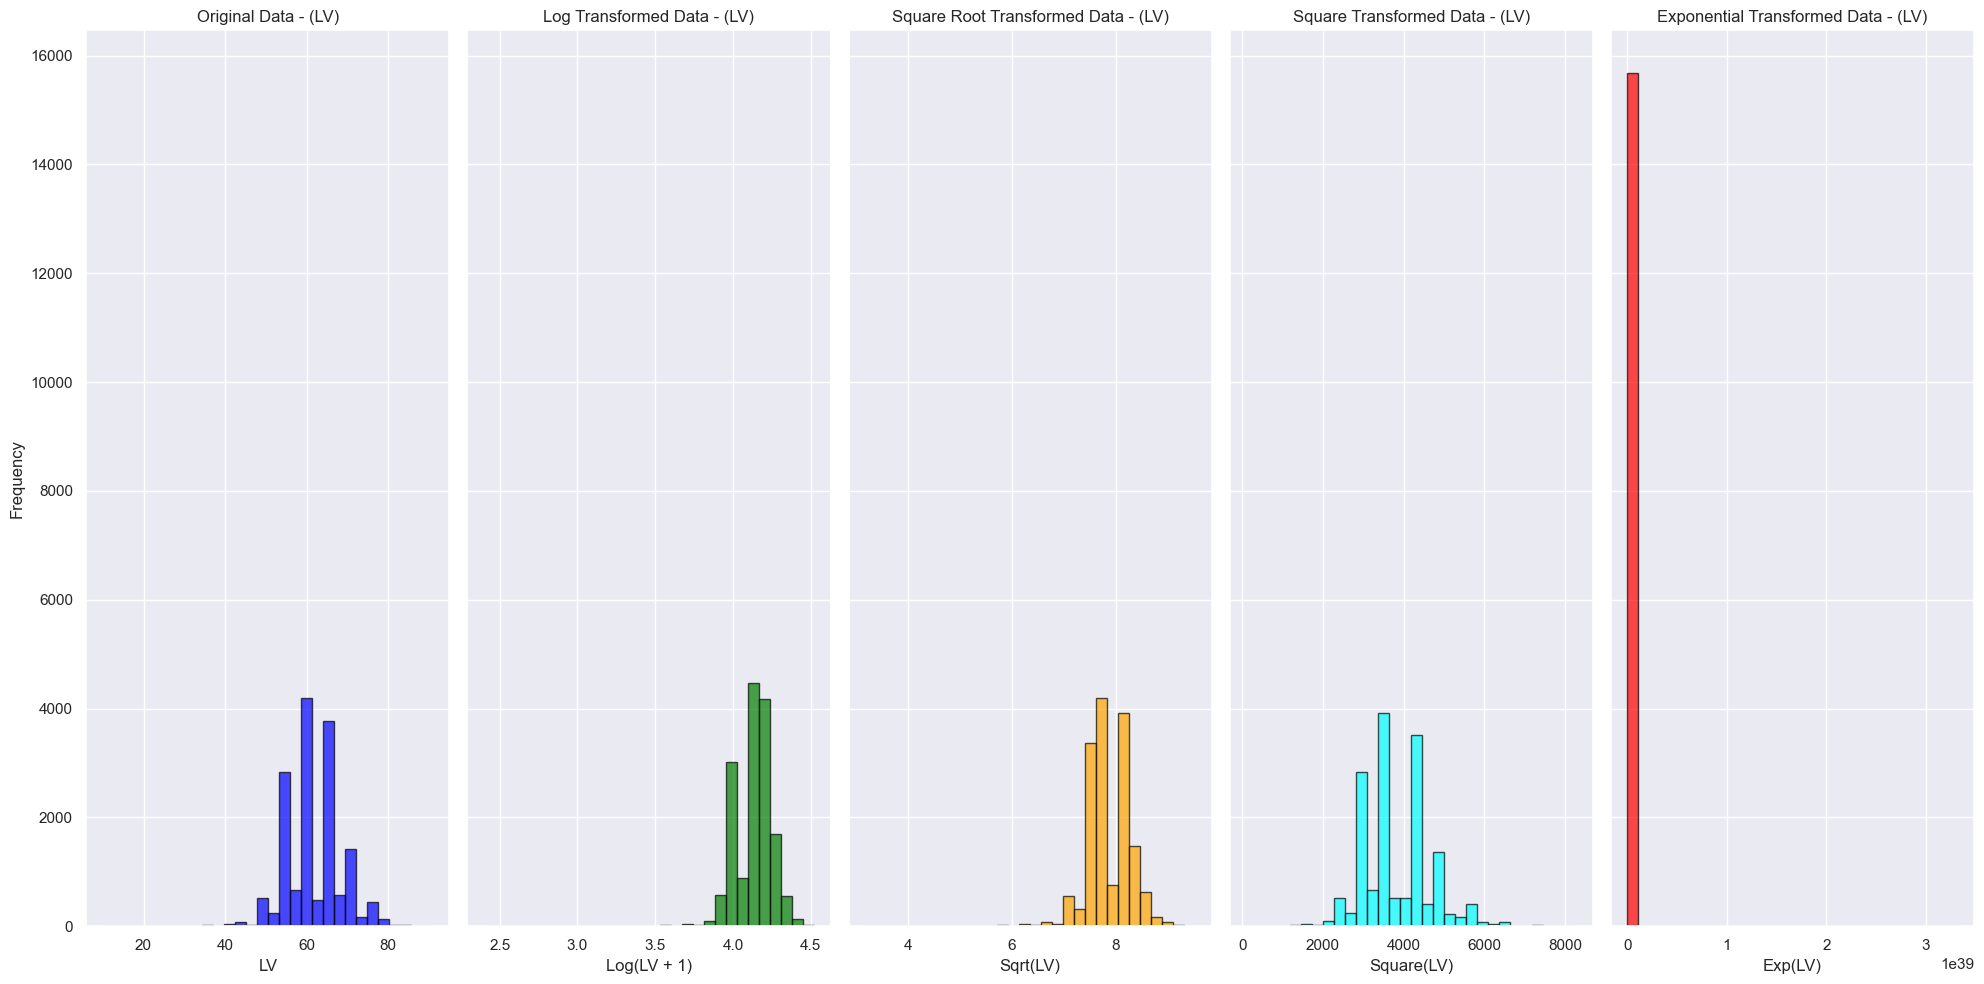

In [93]:
uv.transformPlots(df.LV_EjectionFractionPercent_DON, txt='LV', bins=30, figsize=(20, 10))

In [94]:
# imput NaN using mean: The median (50th percentile)
df.LV_EjectionFractionPercent_DON = df.LV_EjectionFractionPercent_DON.fillna(df.LV_EjectionFractionPercent_DON.median())

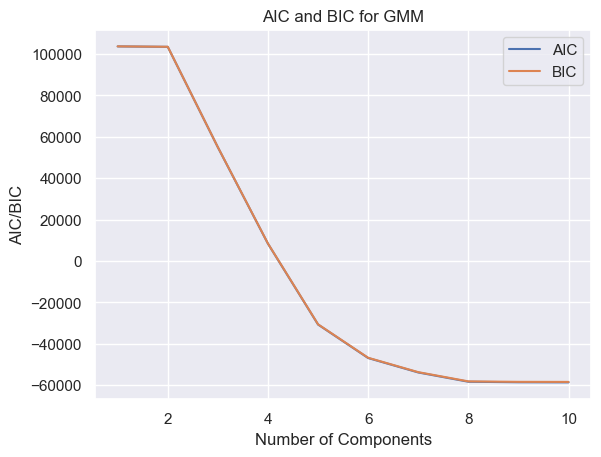

In [95]:
uif.GaussianMixtureBinning(df, ['LV_EjectionFractionPercent_DON'], RANDOM_STATE)

In [96]:
# create new feature
df['LV_EjectionFractionPercent_CAT_DON'] = df.apply(lambda row: categorizeLV(row['LV_EjectionFractionPercent_DON'], row['Gender_DON']), axis=1)

# category datatype
df['LV_EjectionFractionPercent_CAT_DON'] = df['LV_EjectionFractionPercent_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['LV_EjectionFractionPercent_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['LV_EjectionFractionPercent_CAT_DON'])

# add to list
removeCols.extend(features)

In [97]:
df.groupby('Gender_DON', observed=False)['LV_EjectionFractionPercent_CAT_DON'].describe()

,count,unique,top,freq
Gender_DON,,,,
F,4645,5,Normal,4196
M,11056,5,Normal,9941


In [98]:
uf.categoryContingencySurvival(df, 'LV_EjectionFractionPercent_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Below Normal,358.0,390.0,748.0,47.860963,52.139037
Mildly Abnormal,328.0,418.0,746.0,43.967828,56.032172
Moderately Abnormal,30.0,29.0,59.0,50.847458,49.152542
Normal,6702.0,7435.0,14137.0,47.407512,52.592488
Severely Abnormal,9.0,2.0,11.0,81.818182,18.181818
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


##### Level_SGOT
- `SGOT`, also known as aspartate aminotransferase `(AST)`, is an enzyme primarily found in the liver, heart, kidneys, and muscles. It plays a crucial role in amino acid metabolism by catalyzing the transfer of an amino group from aspartate to α-ketoglutarate, producing oxaloacetate and glutamate.
    - Conservative normal range of 8 to 45 units/L for healthy individuals. 
- Alanine aminotransferase `(ALT)`, also known as serum glutamic-pyruvic transaminase `(SGPT)`, is an enzyme primarily found in the liver. It plays a crucial role in amino acid metabolism by catalyzing the conversion of alanine and α-ketoglutarate into pyruvate and glutamate. ALT is commonly measured in blood tests to evaluate liver function and detect liver damage.
    - The typical normal range for ALT is approximately 7 to 56 units per liter (U/L) of serum. However, ranges may vary slightly between laboratories. 

In [99]:
features = uf.getFeatureList(df, 'Level_SGOT')

                      count        mean         std  min   25%   50%   75%      max
Level_SGOT_ALT_DON  15661.0  121.366899  474.578736  3.0  24.0  42.0  88.0  44117.0
Level_SGOT_AST_DON  15661.0  100.836792  300.635387  0.4  25.0  44.0  87.0  10196.0

:::: NaN Count:
Level_SGOT_ALT_DON    40
Level_SGOT_AST_DON    40


In [100]:
df[features].corr()

,Level_SGOT_ALT_DON,Level_SGOT_AST_DON
Level_SGOT_ALT_DON,1.000000,0.481951
Level_SGOT_AST_DON,0.481951,1.000000


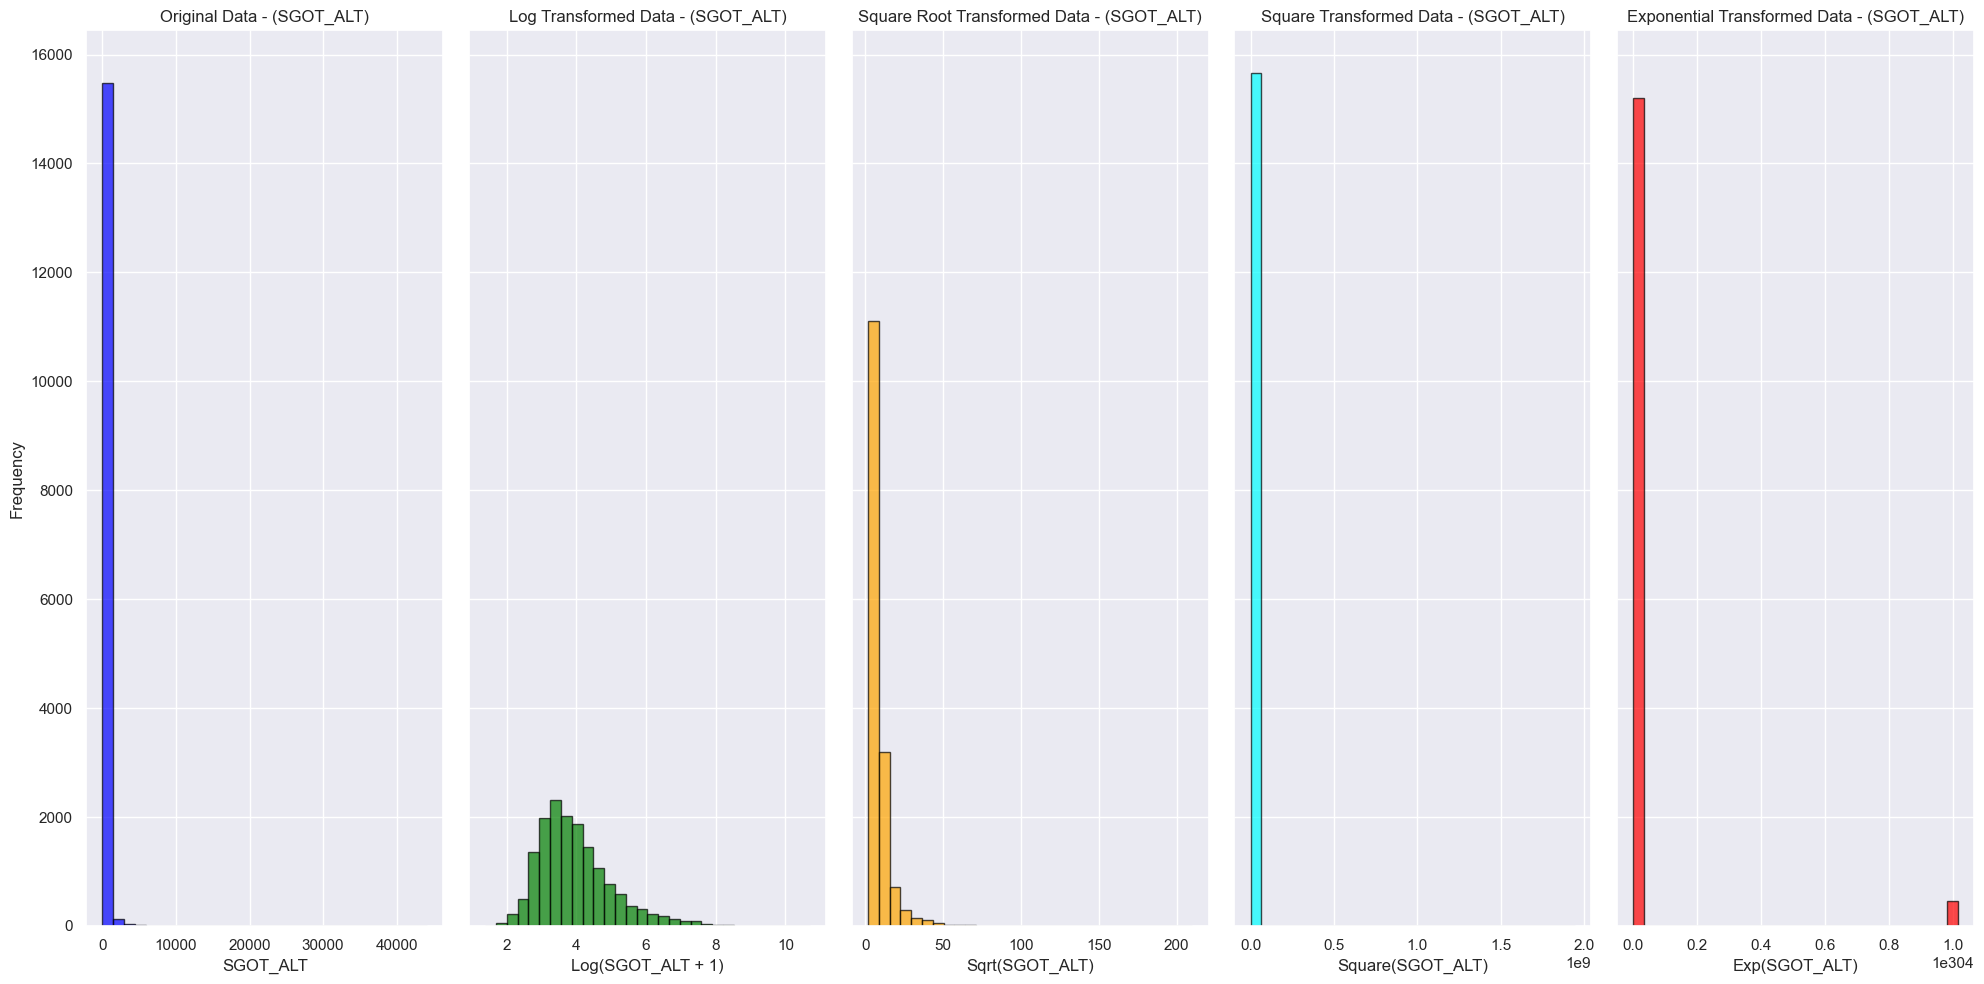

In [101]:
uv.transformPlots(df.Level_SGOT_ALT_DON, txt='SGOT_ALT', bins=30, figsize=(20, 10))

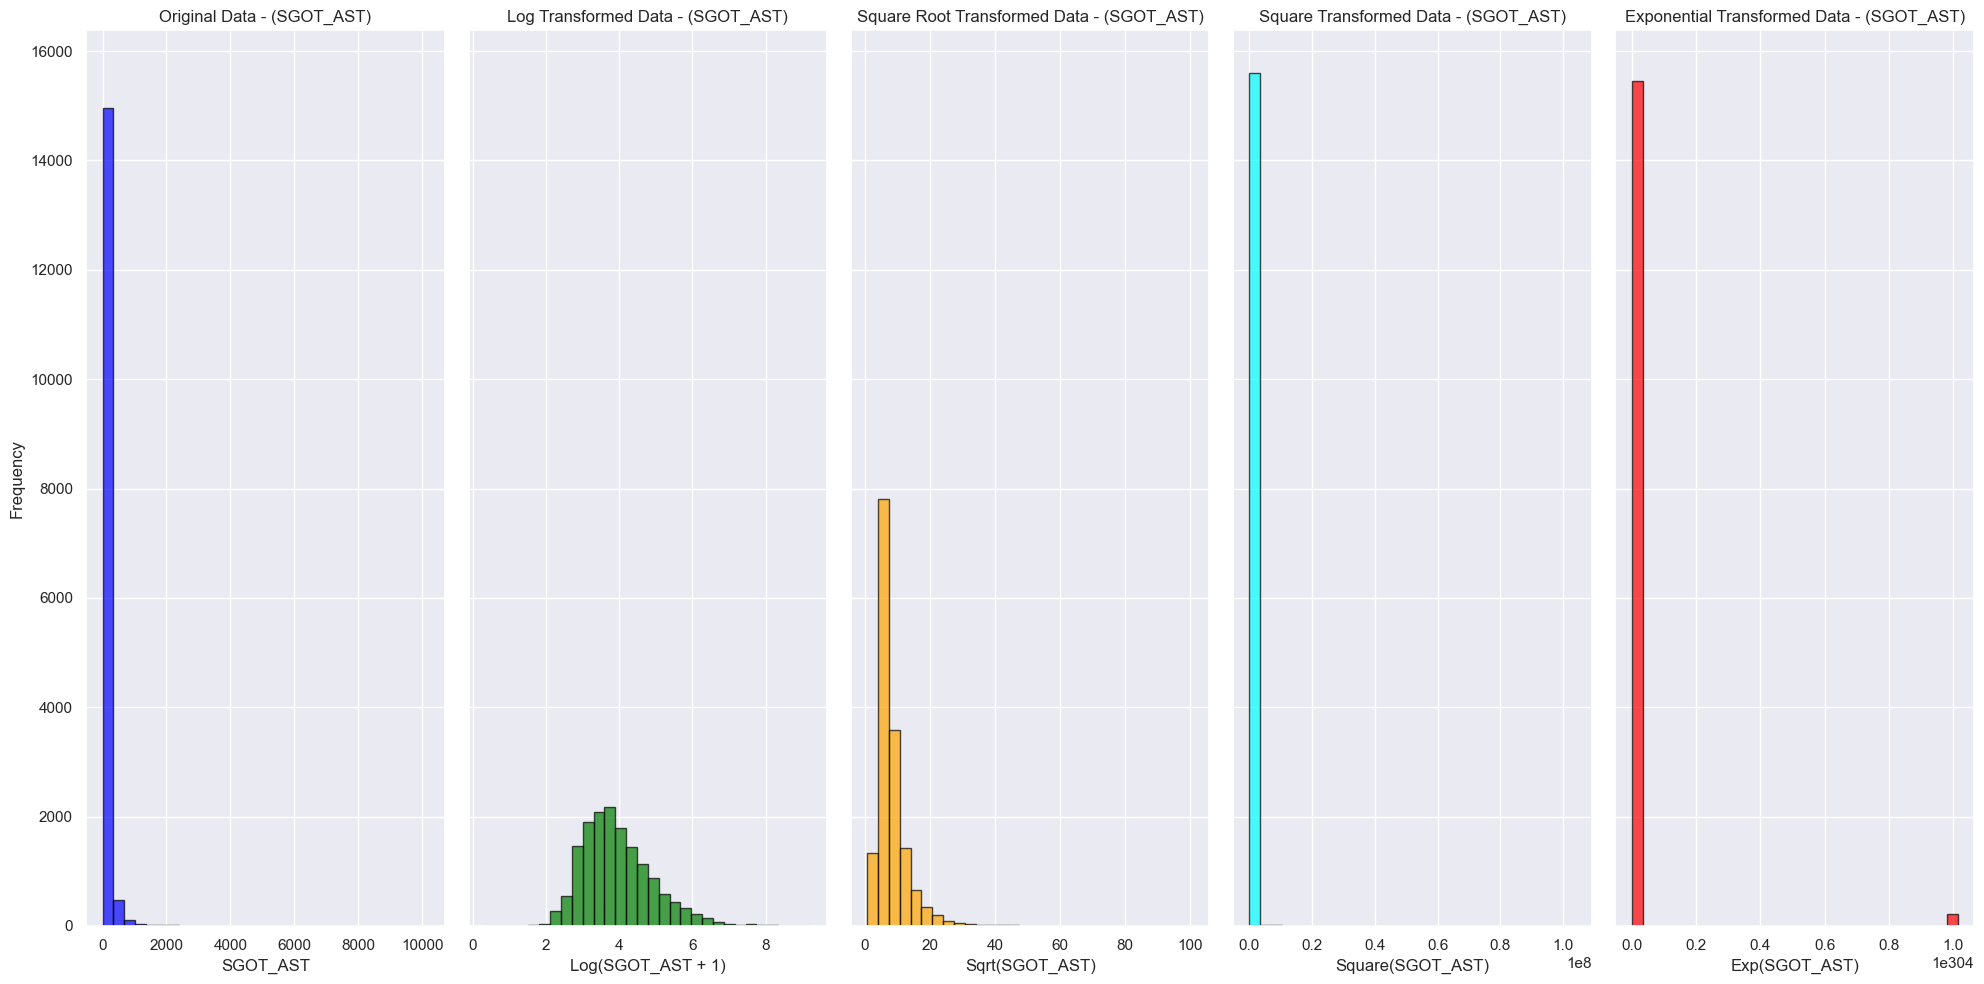

In [102]:
uv.transformPlots(df.Level_SGOT_AST_DON, txt='SGOT_AST', bins=30, figsize=(20, 10))

In [103]:
# new feature
df['SGOT_AST_Log_DON'] = np.log(df.Level_SGOT_AST_DON)
df['SGOT_ALT_Log_DON'] = np.log(df.Level_SGOT_ALT_DON)

# display
featuresLog = uf.getFeatureList(df, '_Log_DON')

                    count      mean       std       min       25%      50%       75%        max
SGOT_ALT_Log_DON  15661.0  3.928605  1.082011  1.098612  3.178054  3.73767  4.477337  10.694600
SGOT_AST_Log_DON  15661.0  3.922088  0.986211 -0.916291  3.218876  3.78419  4.465908   9.229751

:::: NaN Count:
SGOT_ALT_Log_DON    40
SGOT_AST_Log_DON    40


In [104]:
df[featuresLog].corr()

,SGOT_ALT_Log_DON,SGOT_AST_Log_DON
SGOT_ALT_Log_DON,1.000000,0.704232
SGOT_AST_Log_DON,0.704232,1.000000


In [105]:
# imput NaN using mean: The median (50th percentile)
df.SGOT_ALT_Log_DON = df.SGOT_ALT_Log_DON.fillna(df.SGOT_ALT_Log_DON.median())
df.SGOT_AST_Log_DON = df.SGOT_AST_Log_DON.fillna(df.SGOT_AST_Log_DON.median())

In [106]:
df[featuresLog].describe().T

,count,mean,std,min,25%,50%,75%,max
SGOT_ALT_Log_DON,15701.0,3.928119,1.080674,1.098612,3.178054,3.73767,4.477337,10.694600
SGOT_AST_Log_DON,15701.0,3.921737,0.984979,-0.916291,3.218876,3.78419,4.465908,9.229751


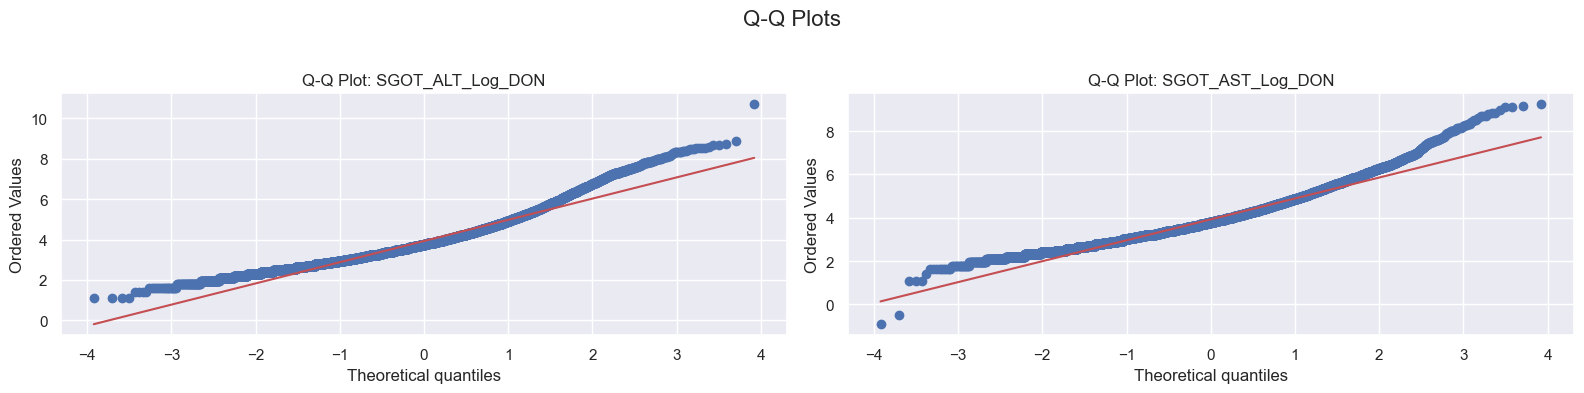

In [107]:
uv.plotQQ(df, featuresLog)

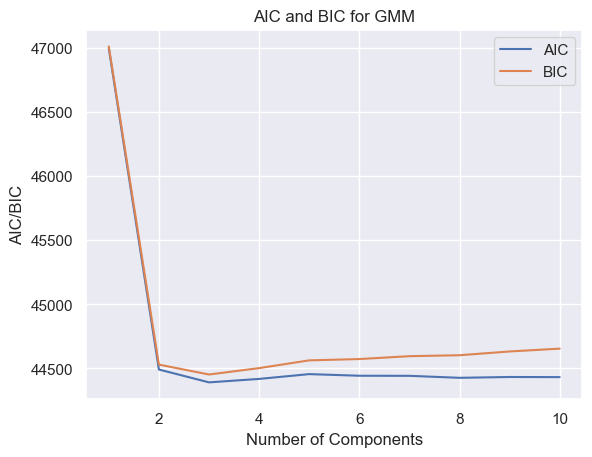

In [108]:
uif.GaussianMixtureBinning(df, ['SGOT_ALT_Log_DON'], RANDOM_STATE)

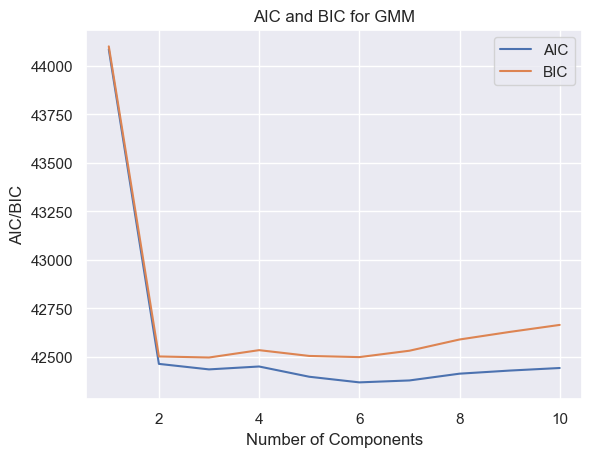

In [109]:
uif.GaussianMixtureBinning(df, ['SGOT_AST_Log_DON'], RANDOM_STATE)

In [110]:
# new feature
df['SGOT_AST_Log_Addtion_DON'] = df.SGOT_ALT_Log_DON + df.SGOT_AST_Log_DON

# new features
df['SGOT_AST_Log_Addtion_CAT_DON'] = pd.qcut(df['SGOT_AST_Log_Addtion_DON'], q=4, labels=['SGOT (Q1)', 'SGOT (Q2)', 'SGOT (Q3)', 'SGOT (Q4)'])

# category datatype
df['SGOT_AST_Log_Addtion_CAT_DON'] = df['SGOT_AST_Log_Addtion_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['SGOT_AST_Log_Addtion_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['SGOT_AST_Log_Addtion_CAT_DON'])

# add to list
removeCols.extend(featuresLog)
removeCols.extend(features)
removeCols.extend(['SGOT_AST_Log_Addtion_DON'])

In [111]:
uf.categoryContingencySurvival(df, 'SGOT_AST_Log_Addtion_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
SGOT (Q1),1764.0,2177.0,3941.0,44.760213,55.239787
SGOT (Q2),1888.0,2024.0,3912.0,48.261759,51.738241
SGOT (Q3),1874.0,2050.0,3924.0,47.757390,52.242610
SGOT (Q4),1901.0,2023.0,3924.0,48.445464,51.554536
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


##### Lung PO2
- Lung PO2 (Partial Pressure of Oxygen) is a measure of the pressure exerted by oxygen in the lungs. It is an important indicator of how well oxygen is being transferred from the air in the lungs to the blood. The value of PO2 is typically measured in millimeters of mercury (mmHg) and provides insight into the efficiency of the respiratory system. In clinical and transplant contexts, particularly with donors, it helps assess the oxygenation status of the donor’s lungs, which is critical when evaluating organs for transplantation. `LungPO2_DON`: PO2 on 100% oxygen refers to the partial pressure of oxygen in arterial blood when a patient is breathing 100% oxygen.

- The Fraction of Inspired Oxygen (Lung FIO2) refers to the concentration of oxygen in the air that is being inhaled by a patient. It is a critical parameter in managing patients with respiratory distress and is often expressed as a percentage or as a decimal. `LungPO2_FIO2_DON`: Lung pO2 on FiO2 refers to the partial pressure of oxygen in arterial blood (PaO2) in relation to the fraction of inspired oxygen (FiO2).
    - Normal Range for FIO2
        - Room Air: The FIO2 in room air is approximately 21% or 0.21 as a decimal.
    - Supplemental Oxygen:
        - Low-Flow Oxygen Therapy: FIO2 can range from about 24% (0.24) to 40% (0.40), depending on the delivery device (e.g., nasal cannula, simple face mask).
        - High-Flow Oxygen Therapy: FIO2 can be set between 40% (0.40) and 100% (1.0), especially in more controlled environments like intensive care units.<br>

In [112]:
features = uf.getFeatureList(df, 'LungPO2')

                    count        mean         std   min    25%    50%    75%    max
LungPO2_DON       15654.0  283.451961  160.823926  12.0  130.0  267.0  430.0  698.0
LungPO2_FIO2_DON  15597.0   82.424184   25.355221   6.0   60.0  100.0  100.0  100.0

:::: NaN Count:
LungPO2_DON          47
LungPO2_FIO2_DON    104


In [113]:
df[features].corr()

,LungPO2_DON,LungPO2_FIO2_DON
LungPO2_DON,1.000000,0.630892
LungPO2_FIO2_DON,0.630892,1.000000


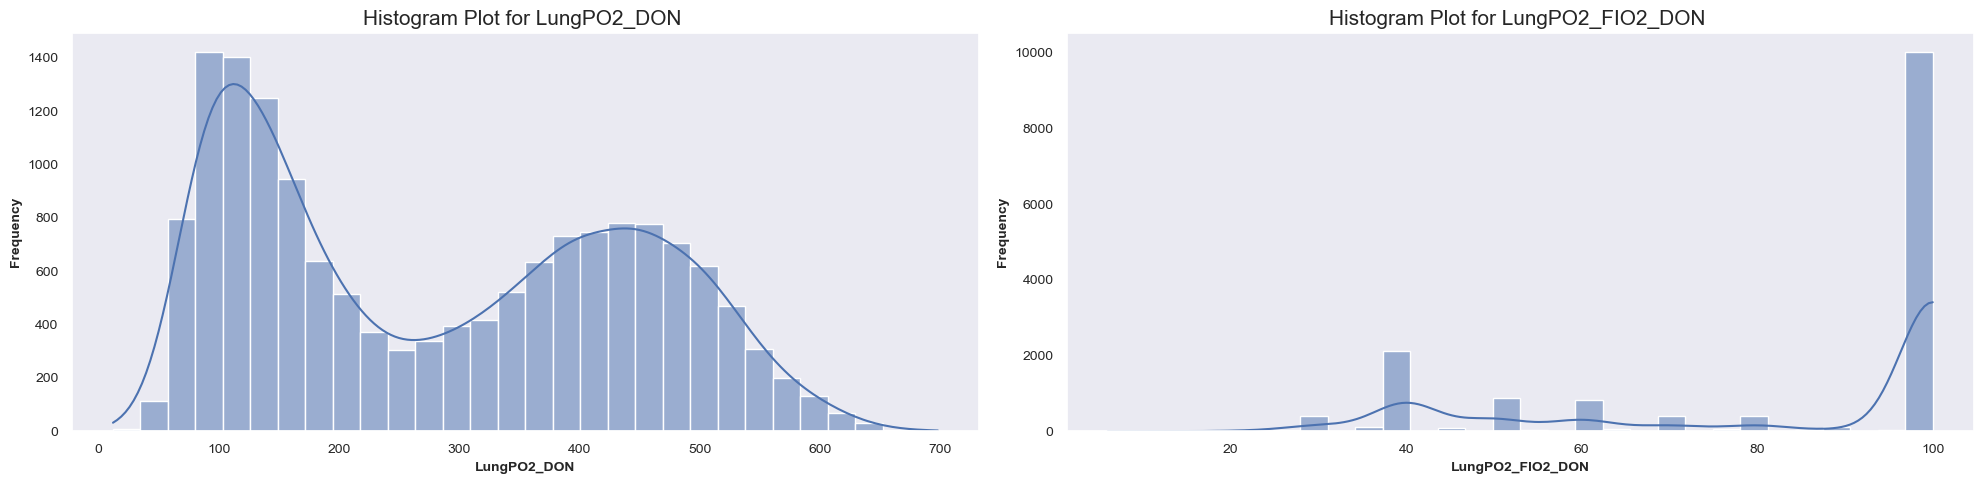

In [114]:
uv.histogramPlot(df, ['LungPO2_DON','LungPO2_FIO2_DON'])

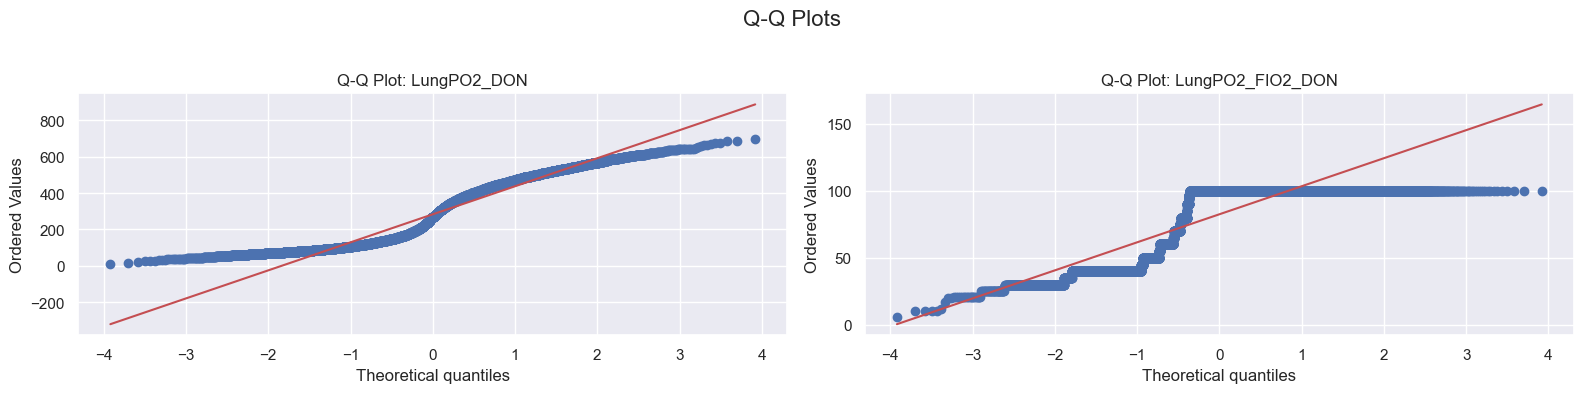

In [115]:
# plot
uv.plotQQ(df, features)

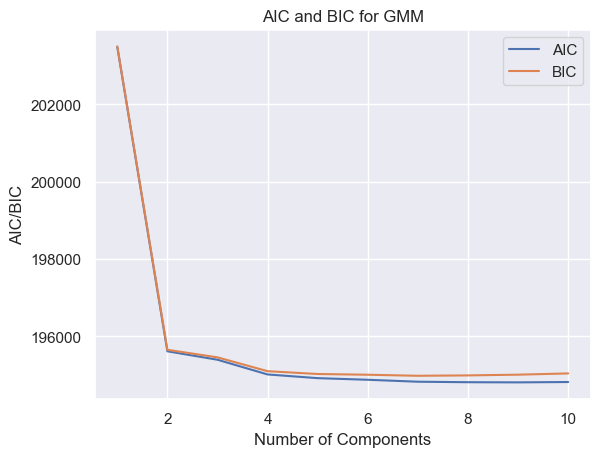

In [116]:
uif.GaussianMixtureBinning(df, ['LungPO2_DON'], RANDOM_STATE)

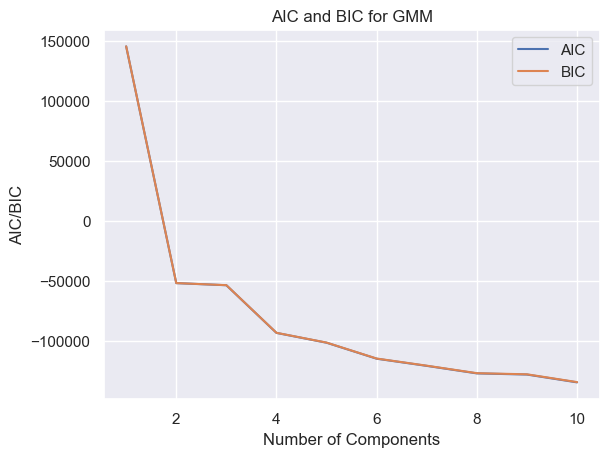

In [117]:
uif.GaussianMixtureBinning(df, ['LungPO2_FIO2_DON'], RANDOM_STATE)

In [118]:
# create new feaure
df['LungPO2_Addtion_DON'] = df.LungPO2_DON + df.LungPO2_FIO2_DON

# new features
df['LungPO2_Addtion_CAT_DON'] = pd.qcut(df['LungPO2_Addtion_DON'], q=4, labels=['LungPO2 (Q1)', 'LungPO2 (Q2)', 'LungPO2 (Q3)', 'LungPO2 (Q4)'])

# category datatype
df['LungPO2_Addtion_CAT_DON'] = df['LungPO2_Addtion_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['LungPO2_Addtion_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['LungPO2_Addtion_CAT_DON'])

# add to list
removeCols.extend(features)
removeCols.extend(['LungPO2_Addtion_DON'])

In [119]:
# add the new category to the list of categories
df['LungPO2_Addtion_CAT_DON'] = df['LungPO2_Addtion_CAT_DON'].cat.add_categories('Unknown')

# check for NaNs
print("Before NaN Count: ", df.LungPO2_Addtion_CAT_DON.isna().sum())
# create unknow category
df.LungPO2_Addtion_CAT_DON = df.LungPO2_Addtion_CAT_DON.fillna('Unknown')
print("After NaN Count: ", df.LungPO2_Addtion_CAT_DON.isna().sum())

Before NaN Count:  111
After NaN Count:  0


In [120]:
uf.categoryContingencySurvival(df, 'LungPO2_Addtion_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
LungPO2 (Q1),1870.0,2055.0,3925.0,47.643312,52.356688
LungPO2 (Q2),1785.0,2094.0,3879.0,46.017015,53.982985
LungPO2 (Q3),1842.0,2046.0,3888.0,47.376543,52.623457
LungPO2 (Q4),1874.0,2024.0,3898.0,48.075936,51.924064
Unknown,56.0,55.0,111.0,50.450450,49.549550
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


##### [OrganRecovery_PCO2_DON](https://www.ncbi.nlm.nih.gov/books/NBK551648/)
- A blood gas test is performed to measure the amount of C02 in the blood. When the lung’s ability to exchange oxygen and C02 becomes impaired, the PC02 level may become increased. The candidate’s current PC02 and change in PC02 are both considered in the lung allocation score calculation to reflect worsening PC02 values. PCO2 is used in the Lung Allocation Score.
- The normal range for the partial pressure of carbon dioxide (pCO2) in arterial blood is typically between 35 to 45 mmHg

In [121]:
def categoryPCO2(value):
    if value < 35:
        return 'Low'
    elif value > 45:
        return 'High'
    else:
        return 'Normal'

In [122]:
features = uf.getFeatureList(df, 'OrganRecovery_PCO2_DON')

                          count       mean       std   min   25%   50%   75%    max
OrganRecovery_PCO2_DON  15638.0  39.220767  6.997109  10.1  34.9  38.7  43.0  106.0

:::: NaN Count:
OrganRecovery_PCO2_DON    63


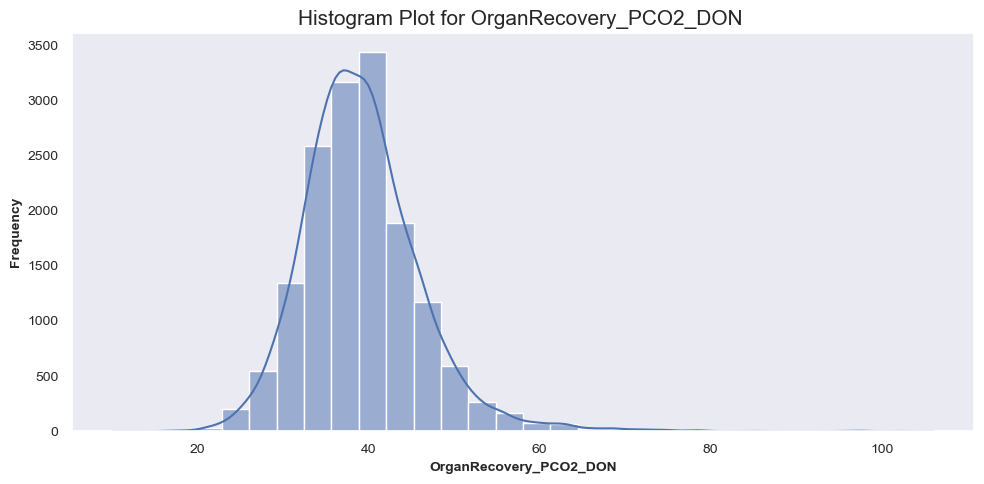

In [123]:
uv.histogramPlot(df, ['OrganRecovery_PCO2_DON'])

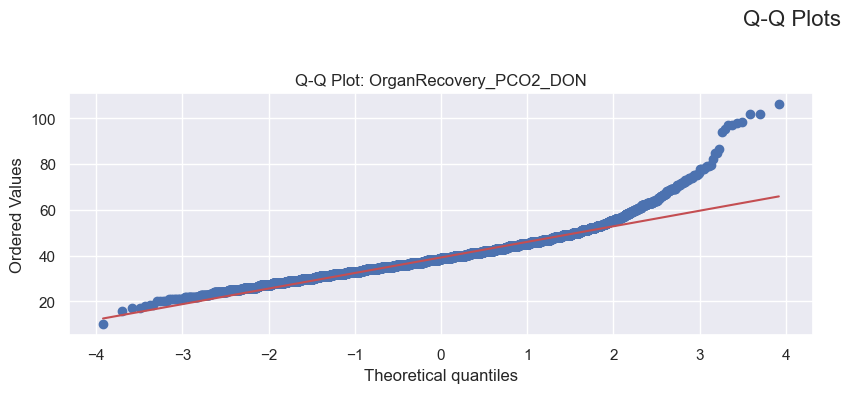

In [124]:
# plot
uv.plotQQ(df, features)

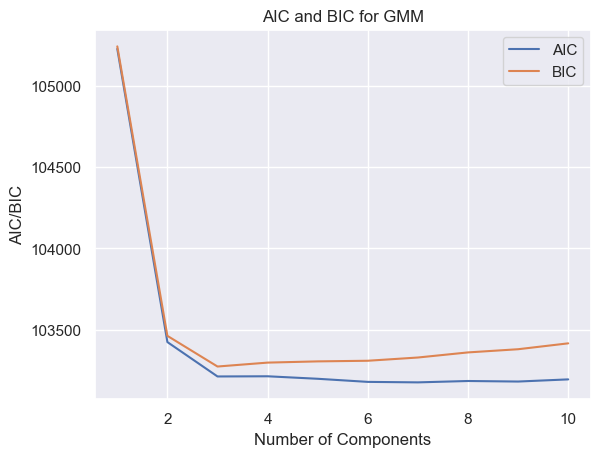

In [125]:
uif.GaussianMixtureBinning(df, ['OrganRecovery_PCO2_DON'], RANDOM_STATE)

In [126]:
# imput NaN using mean: The median (50th percentile)
df[features] = df[features].fillna(df[features].median())

# new feature
df['OrganRecovery_PCO2_CAT_DON'] = df.OrganRecovery_PCO2_DON.map(categoryPCO2).fillna(df.OrganRecovery_PCO2_DON)

# category datatype
df['OrganRecovery_PCO2_CAT_DON'] = df['OrganRecovery_PCO2_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['OrganRecovery_PCO2_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['OrganRecovery_PCO2_CAT_DON'])

# add to list
removeCols.extend(features)

In [127]:
uf.categoryContingencySurvival(df, 'OrganRecovery_PCO2_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
High,1187.0,1285.0,2472.0,48.017799,51.982201
Low,1763.0,2150.0,3913.0,45.054945,54.945055
Normal,4477.0,4839.0,9316.0,48.057106,51.942894
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


##### Bilirubin
- Bilirubin levels can be an important factor in heart transplantation, particularly in the context of post-operative outcomes. Elevated bilirubin levels, or hyperbilirubinemia, can indicate liver dysfunction, which is a common complication following cardiac surgery, including heart transplantation.
    - Prognostic Marker: Hyperbilirubinemia is often used as a prognostic marker for adverse outcomes after cardiac surgery. Elevated bilirubin levels are associated with increased in-hospital mortality, prolonged ICU stays, and other complications.
    - Incidence and Risk Factors: The incidence of hyperbilirubinemia after cardiac surgery varies widely, with reports ranging from 8.6% to 40%. Risk factors include the type of surgery, duration of cardiopulmonary bypass, and pre-existing liver conditions.
    - Management: Managing elevated bilirubin levels involves addressing the underlying causes, such as improving liver perfusion and reducing hemolysis. Treatments like bilirubin adsorption and plasma exchange have been studied for their efficacy in reducing bilirubin levels and improving outcomes.
    - Impact on Transplant Outcomes: High bilirubin levels can complicate the post-operative course and affect the overall success of the heart transplant. Monitoring and managing bilirubin levels is crucial for improving patient outcomes. 

In [128]:
features = uf.getFeatureList(df, 'TotalBilirubin')

                                count      mean       std  min  25%  50%  75%   max
TerminalTotalBilirubin_DON    15661.0  1.038587  1.472510  0.0  0.5  0.7  1.1  45.4
TotalBilirubinTransplant_CAN  15637.0  1.002156  1.921236  0.1  0.5  0.7  1.1  80.0

:::: NaN Count:
TerminalTotalBilirubin_DON      40
TotalBilirubinTransplant_CAN    64


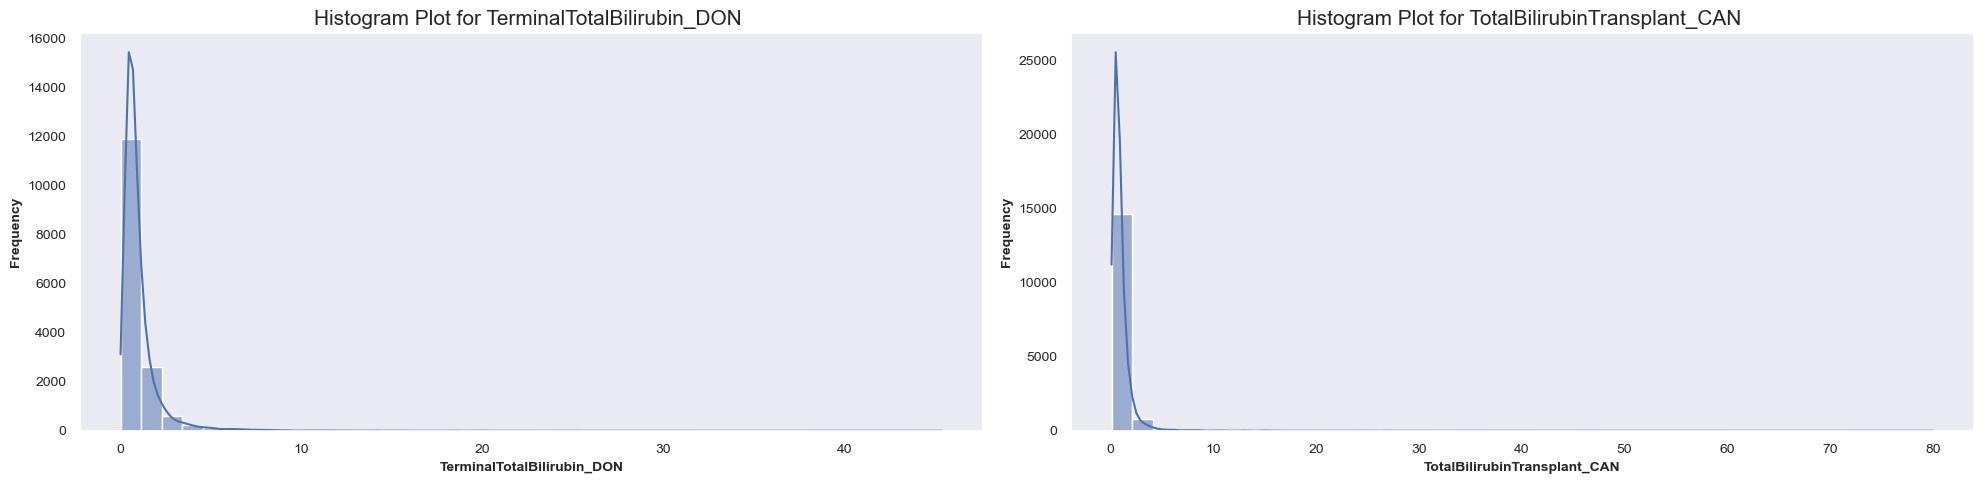

In [129]:
uv.histogramPlot(df, features, bins=40)

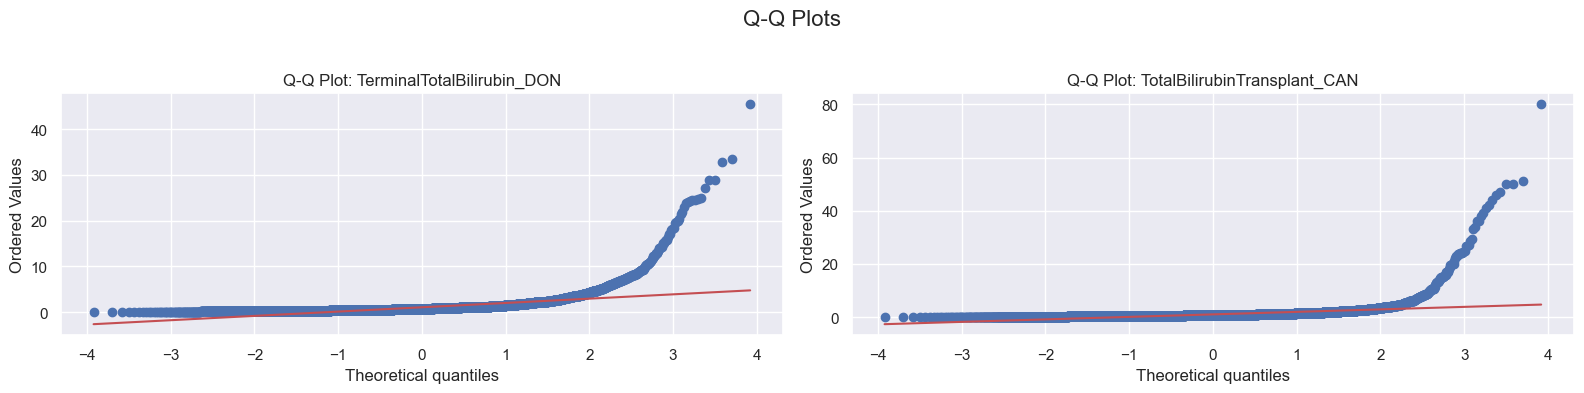

In [130]:
# plot
uv.plotQQ(df, features)

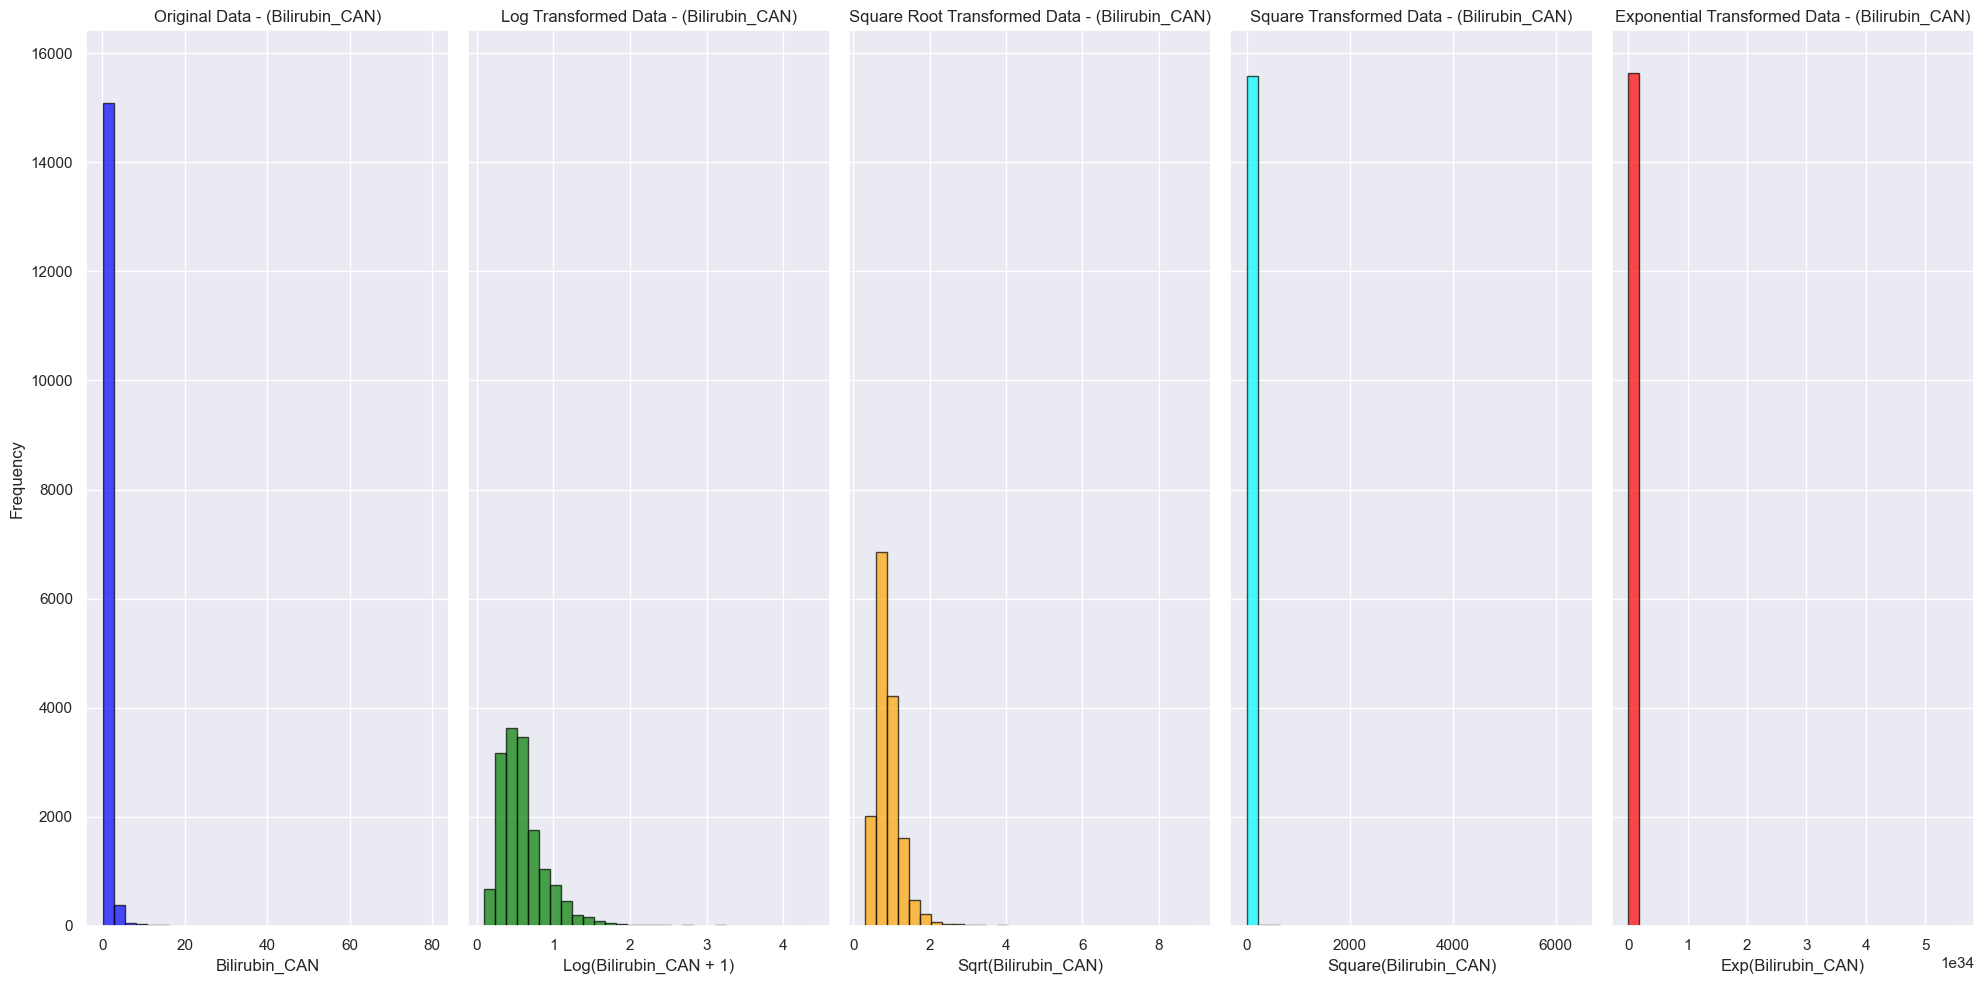

In [131]:
uv.transformPlots(df.TotalBilirubinTransplant_CAN, txt='Bilirubin_CAN', bins=30, figsize=(20, 10))

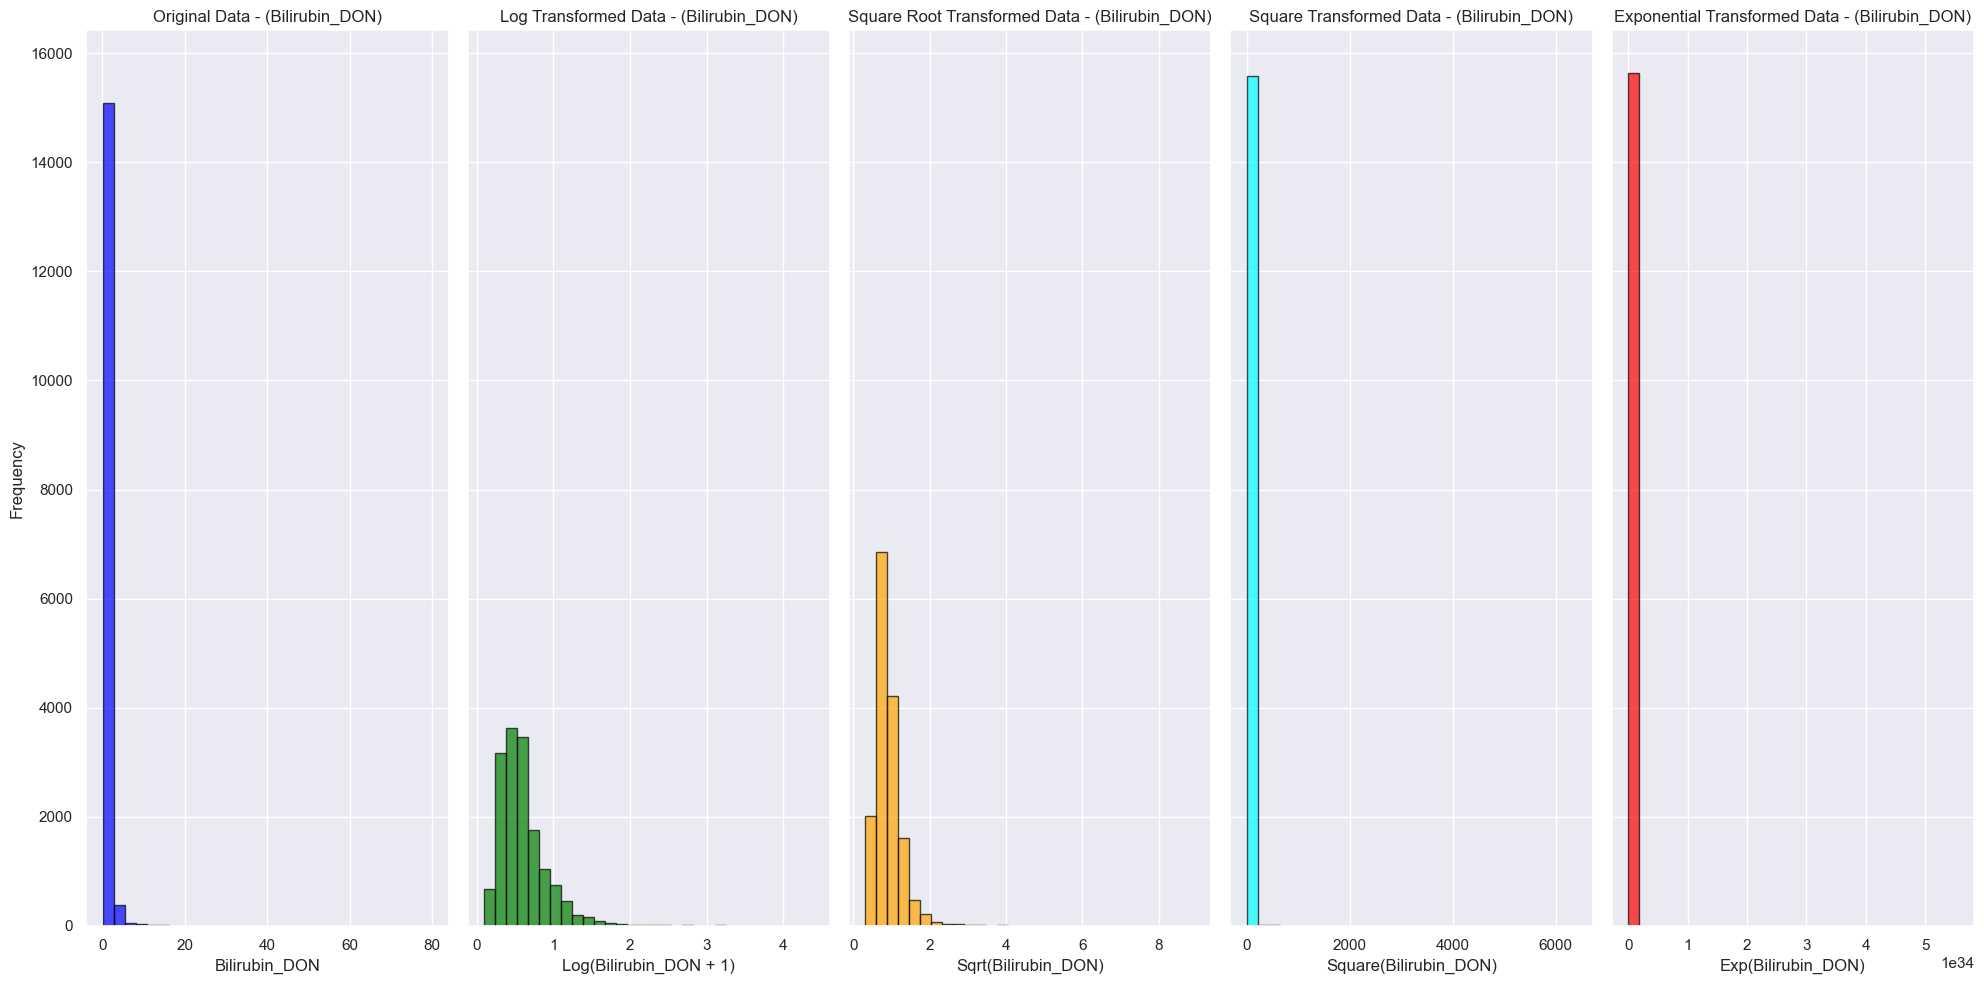

In [132]:
uv.transformPlots(df.TotalBilirubinTransplant_CAN, txt='Bilirubin_DON', bins=30, figsize=(20, 10))

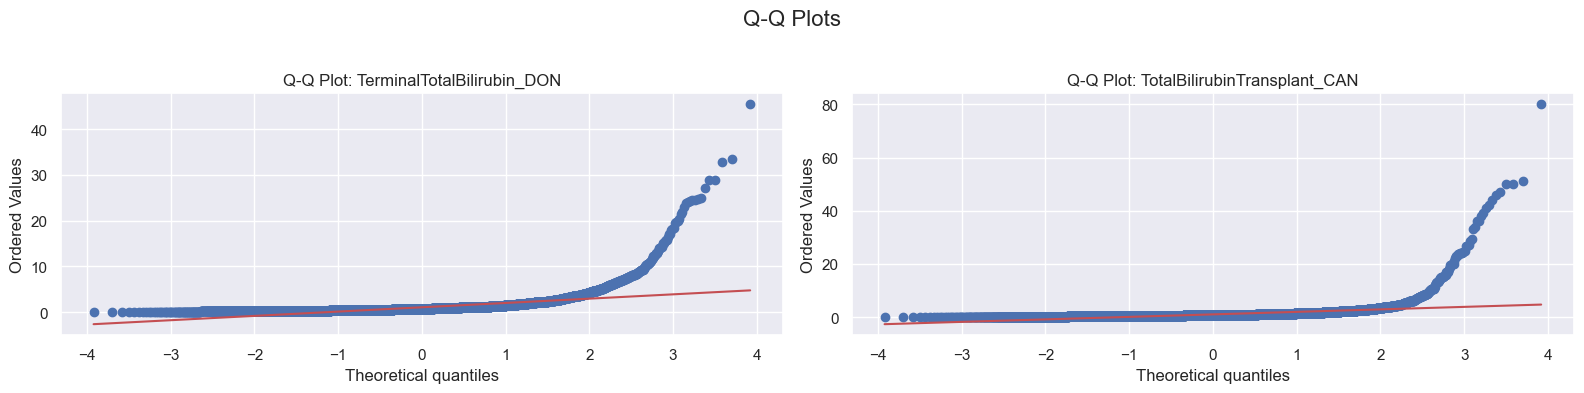

In [133]:
# plot
uv.plotQQ(df, features)

In [134]:
def catMapB(value):
    if value <= 1.2:
        return 'Normal'
    elif value > 1.2:
        return 'High'
    else:
        return 'Unknown'

In [135]:
# new features
df['Bilirubin_CAT_CAN'] = df['TotalBilirubinTransplant_CAN'].map(catMapB).fillna(df['TotalBilirubinTransplant_CAN'])
df['Bilirubin_CAT_DON'] = df['TerminalTotalBilirubin_DON'].map(catMapB).fillna(df['TerminalTotalBilirubin_DON'])

# category datatype
df['Bilirubin_CAT_CAN'] = df['Bilirubin_CAT_CAN'].astype('category')
df['Bilirubin_CAT_DON'] = df['Bilirubin_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['Bilirubin_CAT_CAN', 'Bilirubin_CAT_DON'])
df_can = uf.insertIntoDataFrame(df_can, ['Bilirubin_CAT_CAN'])
df_don = uf.insertIntoDataFrame(df_don, ['Bilirubin_CAT_DON'])

# add to list
removeCols.extend(features)

In [136]:
uf.categoryContingencySurvival(df, 'Bilirubin_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
High,1518.0,1421.0,2939.0,51.650221,48.349779
Normal,5852.0,6846.0,12698.0,46.085998,53.914002
Unknown,57.0,7.0,64.0,89.062500,10.937500
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


In [137]:
uf.categoryContingencySurvival(df, 'Bilirubin_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
High,1525.0,1750.0,3275.0,46.564885,53.435115
Normal,5874.0,6512.0,12386.0,47.424512,52.575488
Unknown,28.0,12.0,40.0,70.000000,30.000000
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


##### TotalDayWaitList_CAN

In [138]:
features = uf.getFeatureList(df, 'TotalDayWaitList')

                        count        mean         std  min   25%   50%    75%     max
TotalDayWaitList_CAN  15701.0  141.029043  229.647431  0.0  13.0  45.0  164.0  2078.0

:::: NaN Count:
TotalDayWaitList_CAN    0


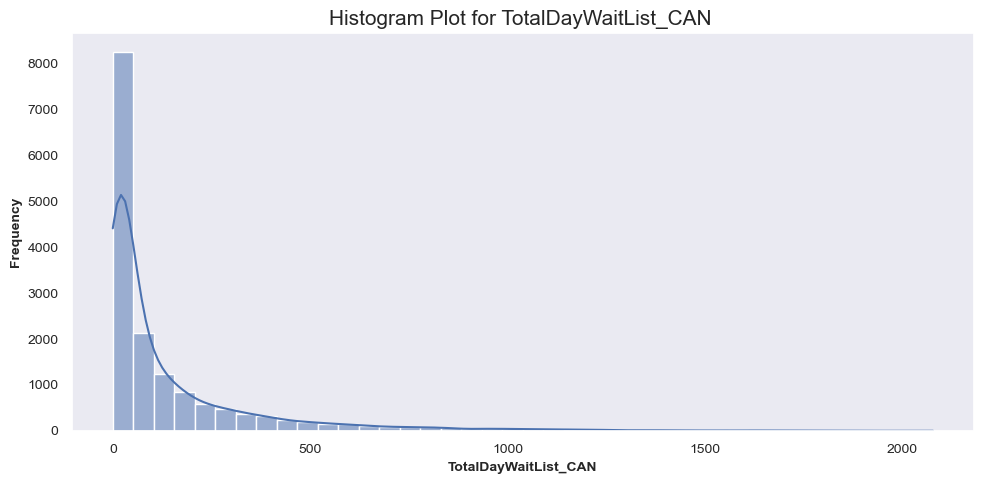

In [139]:
uv.histogramPlot(df, features, bins=40)

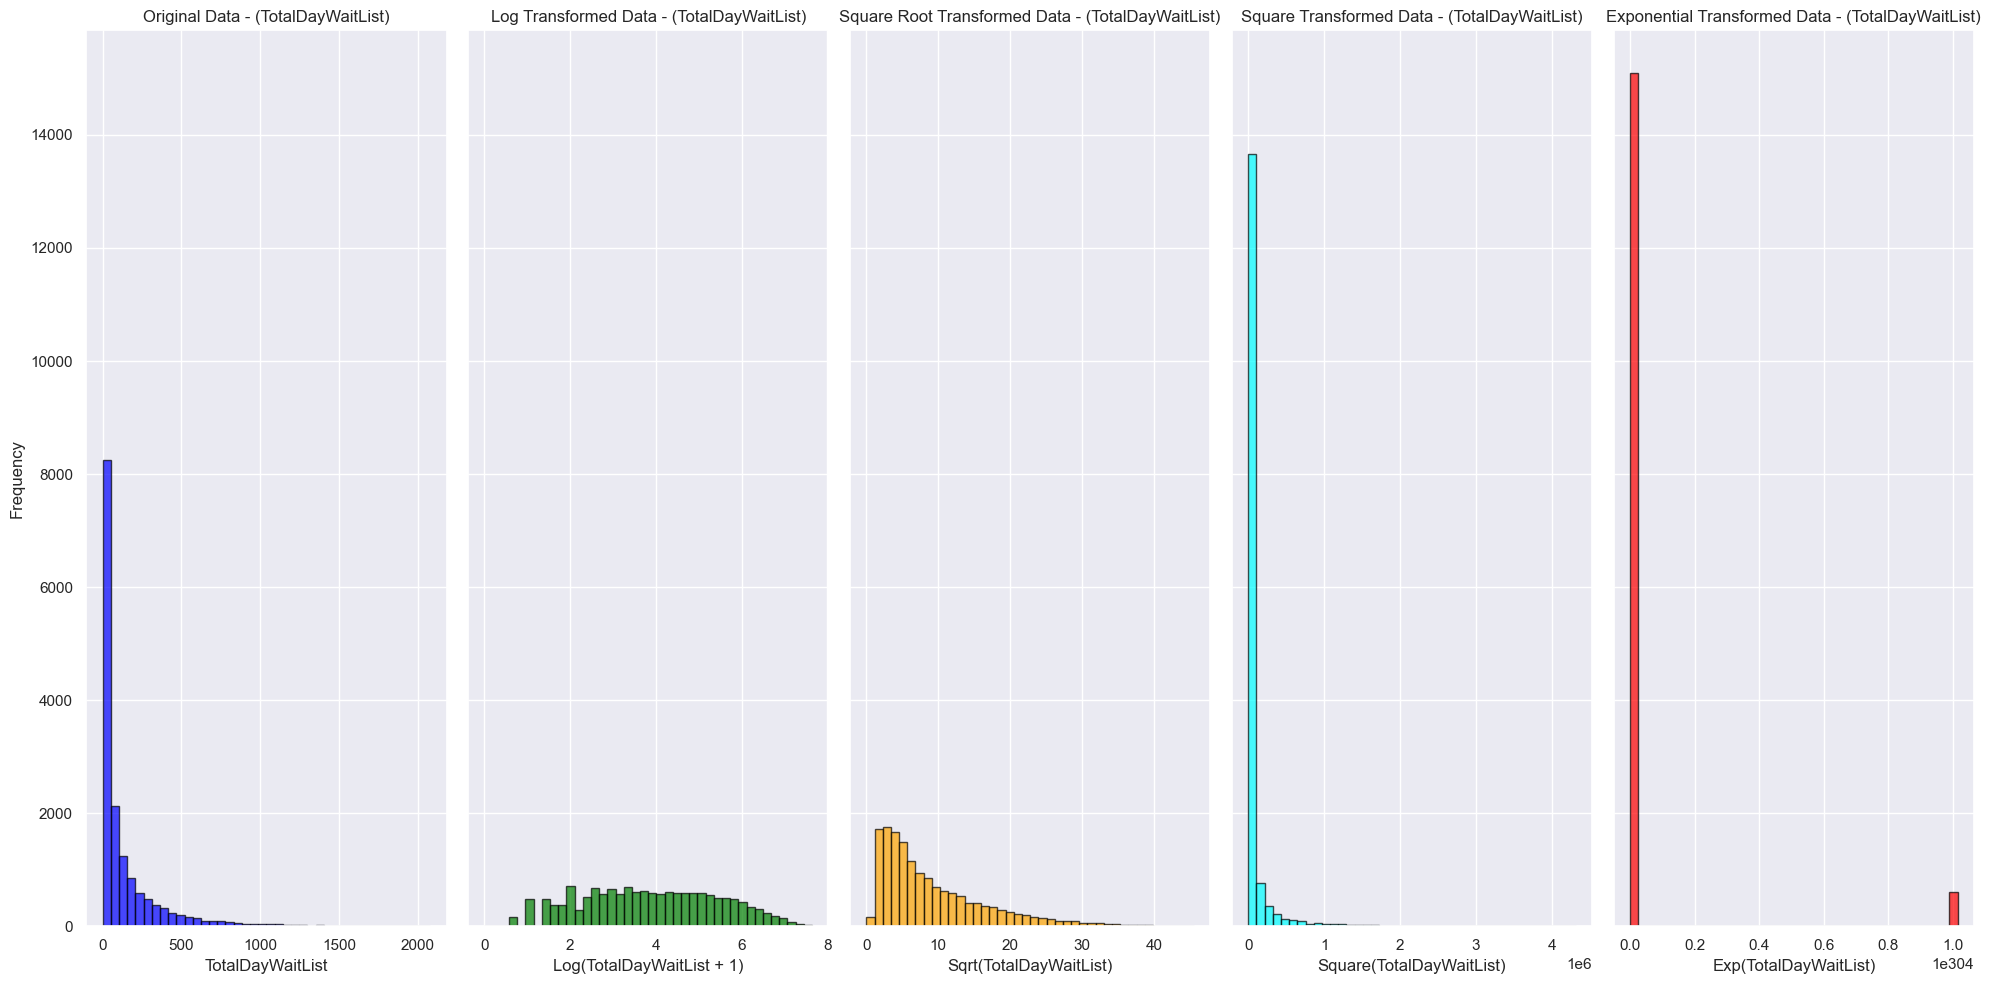

In [140]:
uv.transformPlots(df.TotalDayWaitList_CAN, txt='TotalDayWaitList', bins=40, figsize=(20, 10))

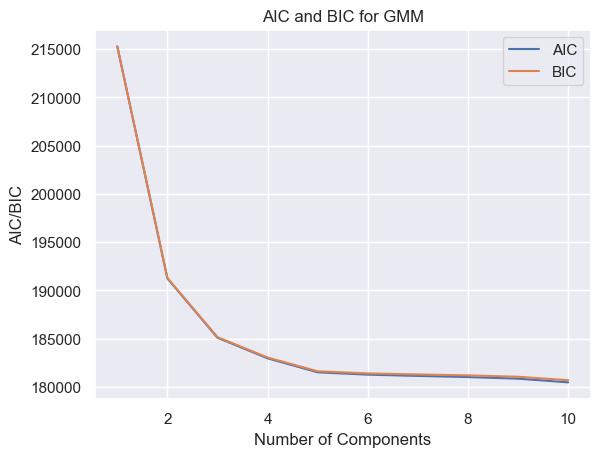

In [141]:
uif.GaussianMixtureBinning(df, ['TotalDayWaitList_CAN'], RANDOM_STATE)

In [142]:
# new features
df['TotalDayWaitList_CAT_CAN'] = pd.qcut(df['TotalDayWaitList_CAN'], q=4, labels=['TotalDayWaitList (Min-13)', 'TotalDayWaitList (14-45)', 'TotalDayWaitList (46-164)', 'TotalDayWaitList (165-Max)'])

# category datatype
df['TotalDayWaitList_CAT_CAN'] = df['TotalDayWaitList_CAT_CAN'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['TotalDayWaitList_CAT_CAN'])
df_can = uf.insertIntoDataFrame(df_can, ['TotalDayWaitList_CAT_CAN'])

# add to list
removeCols.extend(features)

In [143]:
uf.categoryContingencySurvival(df, 'TotalDayWaitList_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
TotalDayWaitList (Min-13),2326.0,1758.0,4084.0,56.953967,43.046033
TotalDayWaitList (14-45),1806.0,1987.0,3793.0,47.614026,52.385974
TotalDayWaitList (46-164),1544.0,2355.0,3899.0,39.599897,60.400103
TotalDayWaitList (165-Max),1751.0,2174.0,3925.0,44.611465,55.388535
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


In [144]:
# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 22 row(s) from df_can DataFrame.
Remove 15 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 37 row(s) from df_numeric DataFrame.
Remove 25 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['Age_CAN', 'Age_DON', 'BMI_CAN', 'BMI_DON', 'BloodPH_DON', 'BloodUreaNitrogenLevel_DON', 'CPRA_Peak_CAN', 'CPRA_Recent_CAN', 'CreatinineRegistration_CAN', 'CreatinineTransplant_CAN', 'Creatinine_DON', 'Creatinine_Mean_CAN', 'DistanceFromDonorHospitaltoTXCenter', 'HeightCm_CAN', 'HeightCm_DON', 'Hematocrit_DON', 'HemodynamicsRegistration_CO_CAN', 'HemodynamicsRegistration_PA_DIA_CAN', 'HemodynamicsRegistration_PA_MN_CAN', 'HemodynamicsRegistration_PCW_CAN', 'HemodynamicsRegistration_SYS_CAN', '

### ENCODE

In [145]:
print(sorted(df_ordinal.column.to_list()))

['Age_CAT_CAN', 'Age_CAT_DON', 'BMI_CAT_CAN', 'BMI_CAT_DON', 'Bilirubin_CAT_CAN', 'Bilirubin_CAT_DON', 'BloodUreaNitrogenLevel_CAT_DON', 'CigaretteAbstinence_CAN', 'Creatinine_CAT_CAN', 'Creatinine_CAT_DON', 'DiabetesHistory_DON', 'DistanceFromDonorHospitaltoTXCenter_CAT', 'EducationLevel_CAN', 'FunctionalStatusRegistration_CAN', 'FunctionalStatusTransplant_CAN', 'HeightCm_CAT_CAN', 'HeightCm_CAT_DON', 'Hematocrit_CAT_DON', 'Hemodynamics_Mean_CO_CAT_CAN', 'Hemodynamics_Mean_PA_MN_CAT_CAN', 'IschemicTimeHour_CAT', 'LV_EjectionFractionPercent_CAT_DON', 'LungPO2_Addtion_CAT_DON', 'MedicalConditionTransplant_CAN', 'MismatchLevel_AMIS', 'MismatchLevel_BMIS', 'MismatchLevel_DRMIS', 'MismatchLevel_HLMIS', 'OrganRecovery_PCO2_CAT_DON', 'PanelReactiveAntibody_CPRA_CAT_CAN', 'PreviousTransplantNumber_CAN', 'SGOT_AST_Log_Addtion_CAT_DON', 'TotalDayWaitList_CAT_CAN', 'TransfusionNumber_DON', 'WeightKg_CAT_CAN', 'WeightKg_CAT_DON']


#### Age

In [146]:
features = uf.getFeatureList(df, 'Age_')

             count unique           top  freq
Age_CAT_CAN  15701      4    Age(48-57)  4314
Age_CAT_DON  15701      4  Age (Min-24)  4279

:::: NaN Count:
Age_CAT_CAN    0
Age_CAT_DON    0


In [147]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Age (Min-47)', 'Age(48-57)', 'Age(58-64)', 'Age(65-Max)'] Age_CAT_CAN
['Age (Min-24)', 'Age(22-31)', 'Age(32-39)', 'Age(40-Max)'] Age_CAT_DON


In [148]:
# order
ordering = sorted(df.Age_CAT_DON.unique())
ordering

['Age (Min-24)', 'Age(22-31)', 'Age(32-39)', 'Age(40-Max)']

In [149]:
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['Age_CAT_DON'] = encoder.fit_transform(df[['Age_CAT_DON']])

In [150]:
# order
ordering = sorted(df.Age_CAT_CAN.unique())
ordering

['Age (Min-47)', 'Age(48-57)', 'Age(58-64)', 'Age(65-Max)']

In [151]:
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['Age_CAT_CAN'] = encoder.fit_transform(df[['Age_CAT_CAN']])

#### BMI

In [152]:
features = uf.getFeatureList(df, 'BMI_')

             count unique            top  freq
BMI_CAT_CAN  15701      4    Over Weight  5654
BMI_CAT_DON  15701      4  Normal Weight  5441

:::: NaN Count:
BMI_CAT_CAN    0
BMI_CAT_DON    0


In [153]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Normal Weight', 'Obesity', 'Over Weight', 'Under Weight'] BMI_CAT_CAN
['Normal Weight', 'Obesity', 'Over Weight', 'Under Weight'] BMI_CAT_DON


In [154]:
# order
ordering = ['Under Weight', 'Normal Weight', 'Obesity', 'Over Weight']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### Bilirubin

In [155]:
features = uf.getFeatureList(df, 'Bilirubin')

                   count unique     top   freq
Bilirubin_CAT_CAN  15701      3  Normal  12698
Bilirubin_CAT_DON  15701      3  Normal  12386

:::: NaN Count:
Bilirubin_CAT_CAN    0
Bilirubin_CAT_DON    0


In [156]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['High', 'Normal', 'Unknown'] Bilirubin_CAT_CAN
['High', 'Normal', 'Unknown'] Bilirubin_CAT_DON


In [157]:
# order
ordering = ['Unknown', 'Normal', 'High']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### BloodUreaNitrogenLevel

In [158]:
features = uf.getFeatureList(df, 'BloodUreaNitrogenLevel')

                                count unique     top  freq
BloodUreaNitrogenLevel_CAT_DON  15701      4  Normal  9216

:::: NaN Count:
BloodUreaNitrogenLevel_CAT_DON    0


In [159]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['High', 'Low', 'Normal', 'Unknown'] BloodUreaNitrogenLevel_CAT_DON


In [160]:
# order
ordering = ['Unknown', 'Low', 'Normal', 'High']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### Cigarette

In [161]:
features = uf.getFeatureList(df, 'Cigarette')

                         count unique      top   freq
CigaretteAbstinence_CAN  15701      9  Unknown   9289
CigaretteHistory_DON     15701      3       No  13561
CigaretteUse_CAN         15701      3       No   9058

:::: NaN Count:
CigaretteAbstinence_CAN    0
CigaretteHistory_DON       0
CigaretteUse_CAN           0


In [162]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['0-2 months', '13-24 months', '25-36 months', '3-12 months', '37-48 months', '49-60 months', '>60 months', 'Continues to smoke', 'Unknown'] CigaretteAbstinence_CAN
['No', 'Unknown', 'Yes'] CigaretteHistory_DON
['No', 'Unknown', 'Yes'] CigaretteUse_CAN


In [163]:
# testing for independance
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,CigaretteAbstinence_CAN,CigaretteUse_CAN,14859.380513,0.000000,0.687894
0,CigaretteAbstinence_CAN,CigaretteHistory_DON,13.766349,0.616115,0.020938
2,CigaretteHistory_DON,CigaretteUse_CAN,2.149417,0.708300,0.008273


In [164]:
df.CigaretteAbstinence_CAN.value_counts()

CigaretteAbstinence_CAN
Unknown               9289
>60 months            3815
3-12 months           1071
13-24 months           551
25-36 months           328
37-48 months           249
49-60 months           215
0-2 months             161
Continues to smoke      22
Name: count, dtype: int64

In [165]:
# add to removeCols list
removeCols = ['CigaretteAbstinence_CAN']

#### Creatinine

In [166]:
features = uf.getFeatureList(df, 'Creatinine')

                    count unique     top  freq
Creatinine_CAT_CAN  15701      4  Normal  8621
Creatinine_CAT_DON  15701      4  Normal  8723

:::: NaN Count:
Creatinine_CAT_CAN    0
Creatinine_CAT_DON    0


In [167]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Elevated', 'Low', 'Normal', 'Unknown'] Creatinine_CAT_CAN
['Elevated', 'Low', 'Normal', 'Unknown'] Creatinine_CAT_DON


In [168]:
# order
ordering = ['Unknown', 'Low', 'Normal', 'Elevated']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### Diabetes

In [169]:
features = uf.getFeatureList(df, 'Diabetes')

                     count unique top   freq
DiabetesHistory_DON  15701      6  No  14978
DiabetesType_CAN     15701      6  No  11100
Diabetes_DON         15701      3  No  14978

:::: NaN Count:
DiabetesHistory_DON    0
DiabetesType_CAN       0
Diabetes_DON           0


In [170]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['No', 'Unknown', 'Yes, 0-5 Years', 'Yes, 6-10 Years', 'Yes, >10 Years', 'Yes, Duration Unknown'] DiabetesHistory_DON
['No', 'Type I', 'Type II', 'Type Other', 'Type Unknown', 'Unknown'] DiabetesType_CAN
['No', 'Unknown', 'Yes'] Diabetes_DON


In [171]:
# testing for independance
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,DiabetesHistory_DON,Diabetes_DON,31402.000000,0.000000,1.000000
2,DiabetesType_CAN,Diabetes_DON,6.263534,0.792658,0.014123
0,DiabetesHistory_DON,DiabetesType_CAN,12.721722,0.979733,0.012730


In [172]:
# add to removeCols list
removeCols.extend(['DiabetesHistory_DON'])

#### DistanceFromDonorHospitaltoTXCenter_CAT

In [173]:
features = uf.getFeatureList(df, 'Distance')

                                         count unique               top  freq
DistanceFromDonorHospitaltoTXCenter_CAT  15701      4  Distance(Min-37)  3954

:::: NaN Count:
DistanceFromDonorHospitaltoTXCenter_CAT    0


In [174]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Distance(167-354)', 'Distance(354-Max)', 'Distance(38-167)', 'Distance(Min-37)'] DistanceFromDonorHospitaltoTXCenter_CAT


In [175]:
# order
ordering = ['Distance(Min-37)', 'Distance(38-167)', 'Distance(167-354)', 'Distance(354-Max)']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### EducationLevel_CAN

In [176]:
features = uf.getFeatureList(df, 'EducationLevel_CAN')

                    count unique                        top  freq
EducationLevel_CAN  15701      7  HIGH SCHOOL (9-12) or GED  5660

:::: NaN Count:
EducationLevel_CAN    0


In [177]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['ASSOCIATE/BACHELOR DEGREE', 'ATTENDED COLLEGE/TECHNICAL SCHOOL', 'GRADE SCHOOL (0-8)', 'HIGH SCHOOL (9-12) or GED', 'NONE', 'POST-COLLEGE GRADUATE DEGREE', 'Unknown'] EducationLevel_CAN


In [178]:
# order
ordering = ['Unknown', 'NONE', 'GRADE SCHOOL (0-8)', 'HIGH SCHOOL (9-12) or GED', 'ATTENDED COLLEGE/TECHNICAL SCHOOL', 'ASSOCIATE/BACHELOR DEGREE', 'POST-COLLEGE GRADUATE DEGREE']
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### FunctionalStatus

In [179]:
features = uf.getFeatureList(df, 'FunctionalStatus')

                                  count unique                                                                     top  freq
FunctionalStatusRegistration_CAN  15701     11  20% - Very sick, hospitalization necessary: active treatment necessary  4012
FunctionalStatusTransplant_CAN    15701     11  20% - Very sick, hospitalization necessary: active treatment necessary  5330

:::: NaN Count:
FunctionalStatusRegistration_CAN    0
FunctionalStatusTransplant_CAN      0


In [180]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['10% - Moribund, fatal processes progressing rapidly', '100% - Normal, no complaints, no evidence of disease', '20% - Very sick, hospitalization necessary: active treatment necessary', '30% - Severely disabled: hospitalization is indicated, death not imminent', '40% - Disabled: requires special care and assistance', '50% - Requires considerable assistance and frequent medical care', '60% - Requires occasional assistance but is able to care for needs', '70% - Cares for self: unable to carry on normal activity or active work', '80% - Normal activity with effort: some symptoms of disease', '90% - Able to carry on normal activity: minor symptoms of disease', 'Unknown'] FunctionalStatusRegistration_CAN
['10% - Moribund, fatal processes progressing rapidly', '100% - Normal, no complaints, no evidence of disease', '20% - Very sick, hospitalization necessary: active treatment necessary', '30% - Severely disabled: hospitalization is indicated, death not imminent', '40% - Disabled: requires spe

In [181]:
# testing for independance
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,FunctionalStatusRegistration_CAN,FunctionalStatusTransplant_CAN,20381.991236,0.0,0.360296


In [182]:
# sort the list, placing "Unknown" first
ordering = ['Unknown'] + sorted(
    [status for status in df.FunctionalStatusTransplant_CAN.unique().tolist() if status != 'Unknown'],
    key=lambda x: int(x.split('%')[0])
)
print(ordering)

['Unknown', '10% - Moribund, fatal processes progressing rapidly', '20% - Very sick, hospitalization necessary: active treatment necessary', '30% - Severely disabled: hospitalization is indicated, death not imminent', '40% - Disabled: requires special care and assistance', '50% - Requires considerable assistance and frequent medical care', '60% - Requires occasional assistance but is able to care for needs', '70% - Cares for self: unable to carry on normal activity or active work', '80% - Normal activity with effort: some symptoms of disease', '90% - Able to carry on normal activity: minor symptoms of disease', '100% - Normal, no complaints, no evidence of disease']


In [183]:
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### HeightCm

In [184]:
features = uf.getFeatureList(df, 'HeightCm')

                  count unique                 top  freq
HeightCm_CAT_CAN  15701      4  HeightCm (Min-168)  4897
HeightCm_CAT_DON  15701      4   HeightCm(169-175)  4584

:::: NaN Count:
HeightCm_CAT_CAN    0
HeightCm_CAT_DON    0


In [185]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['HeightCm (Min-168)', 'HeightCm(169-175)', 'HeightCm(176-181)', 'HeightCm(182-Max)'] HeightCm_CAT_CAN
['HeightCm (Min-168)', 'HeightCm(169-175)', 'HeightCm(176-181)', 'HeightCm(182-Max)'] HeightCm_CAT_DON


In [186]:
ordering = sorted(df.HeightCm_CAT_CAN.unique())
ordering

['HeightCm (Min-168)',
 'HeightCm(169-175)',
 'HeightCm(176-181)',
 'HeightCm(182-Max)']

In [187]:
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### Hematocrit_CAT_DON

In [188]:
features = uf.getFeatureList(df, 'Hematocrit')

                    count unique  top   freq
Hematocrit_CAT_DON  15701      3  Low  15376

:::: NaN Count:
Hematocrit_CAT_DON    0


In [189]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Elevated', 'Low', 'Normal'] Hematocrit_CAT_DON


In [190]:
# order
ordering = ['Low', 'Normal', 'Elevated']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### Hemodynamics_Mean

In [191]:
features = uf.getFeatureList(df, 'Hemodynamics_Mean')

                                 count unique   top   freq
Hemodynamics_Mean_CO_CAT_CAN     15701      3   Low  11528
Hemodynamics_Mean_PA_MN_CAT_CAN  15701      4  High   7902

:::: NaN Count:
Hemodynamics_Mean_CO_CAT_CAN       0
Hemodynamics_Mean_PA_MN_CAT_CAN    0


In [192]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['High', 'Low', 'Normal'] Hemodynamics_Mean_CO_CAT_CAN
['Extreme', 'High', 'Low', 'Normal'] Hemodynamics_Mean_PA_MN_CAT_CAN


In [193]:
# order
ordering = ['Low', 'Normal', 'High']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['Hemodynamics_Mean_CO_CAT_CAN'] = encoder.fit_transform(df[['Hemodynamics_Mean_CO_CAT_CAN']])

In [194]:
# order
ordering = ['Low', 'Normal', 'High', 'Extreme']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['Hemodynamics_Mean_PA_MN_CAT_CAN'] = encoder.fit_transform(df[['Hemodynamics_Mean_PA_MN_CAT_CAN']])

#### IschemicTimeHour

In [195]:
features = uf.getFeatureList(df, 'IschemicTimeHour')

                      count unique     top  freq
IschemicTimeHour_CAT  15701      3  Normal  8517

:::: NaN Count:
IschemicTimeHour_CAT    0


In [196]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['High', 'Low', 'Normal'] IschemicTimeHour_CAT


In [197]:
# order
ordering = ['Low', 'Normal', 'High']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### LV_EjectionFractionPercent

In [198]:
features = uf.getFeatureList(df, 'LV_EjectionFractionPercent')

                                    count unique     top   freq
LV_EjectionFractionPercent_CAT_DON  15701      5  Normal  14137

:::: NaN Count:
LV_EjectionFractionPercent_CAT_DON    0


In [199]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Below Normal', 'Mildly Abnormal', 'Moderately Abnormal', 'Normal', 'Severely Abnormal'] LV_EjectionFractionPercent_CAT_DON


In [200]:
# order
ordering = sorted(df[feature].unique())
ordering                 

['Below Normal',
 'Mildly Abnormal',
 'Moderately Abnormal',
 'Normal',
 'Severely Abnormal']

In [201]:
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### LungPO2

In [202]:
features = uf.getFeatureList(df, 'LungPO2')

                         count unique           top  freq
LungPO2_Addtion_CAT_DON  15701      5  LungPO2 (Q1)  3925

:::: NaN Count:
LungPO2_Addtion_CAT_DON    0


In [203]:
for feature in features:
    print((df[feature].unique()), feature)

['LungPO2 (Q1)', 'LungPO2 (Q3)', 'LungPO2 (Q2)', 'LungPO2 (Q4)', 'Unknown']
Categories (5, object): ['LungPO2 (Q1)' < 'LungPO2 (Q2)' < 'LungPO2 (Q3)' < 'LungPO2 (Q4)' < 'Unknown'] LungPO2_Addtion_CAT_DON


In [204]:
# order
ordering = ['Unknown', 'LungPO2 (Q1)', 'LungPO2 (Q3)', 'LungPO2 (Q2)', 'LungPO2 (Q4)']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### MedicalConditionTransplant_CAN

In [205]:
features = uf.getFeatureList(df, 'MedicalConditionTransplan')

                                count unique                     top  freq
MedicalConditionTransplant_CAN  15701      4  In Intensive Care Unit  7164

:::: NaN Count:
MedicalConditionTransplant_CAN    0


In [206]:
for feature in features:
    print((df[feature].unique()), feature)

['Not Hospitalized', 'In Intensive Care Unit', 'Hospitalized Not in ICU', 'Unknown']
Categories (4, object): ['Hospitalized Not in ICU', 'In Intensive Care Unit', 'Unknown', 'Not Hospitalized'] MedicalConditionTransplant_CAN


In [207]:
# order
ordering = ['Unknown', 'Not Hospitalized', 'Hospitalized Not in ICU', 'In Intensive Care Unit']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### MismatchLevel

In [208]:
features = uf.getFeatureList(df, 'MismatchLevel')

                     count  unique  top   freq
MismatchLevel_AMIS   15701       4    2   7447
MismatchLevel_BMIS   15701       4    2  10444
MismatchLevel_DRMIS  15701       4    2   7963
MismatchLevel_HLMIS  15701       8    5   5411

:::: NaN Count:
MismatchLevel_AMIS     0
MismatchLevel_BMIS     0
MismatchLevel_DRMIS    0
MismatchLevel_HLMIS    0


In [209]:
for feature in features:
    print((df[feature].unique()), feature)

[2, 1, 999, 0]
Categories (4, int64): [0, 1, 2, 999] MismatchLevel_AMIS
[2, 1, 999, 0]
Categories (4, int64): [0, 1, 2, 999] MismatchLevel_BMIS
[2, 1, 0, 999]
Categories (4, int64): [0, 1, 2, 999] MismatchLevel_DRMIS
[6, 4, 3, 5, 999, 2, 0, 1]
Categories (8, int64): [0, 1, 2, 3, 4, 5, 6, 999] MismatchLevel_HLMIS


In [210]:
# convert to string
df[features] = df[features].astype(str)

# iterate features to encode
for feature in features:
    # sorting
    ordering = ['999'] + sorted([x for x in df[feature].unique() if x != '999'])
    # initialize encoder
    encoder = OrdinalEncoder(categories=[ordering])
    df[feature] = encoder.fit_transform(df[[feature]])

#### OrganRecovery_PCO2_CAT_DON

In [211]:
features = uf.getFeatureList(df, 'OrganRecovery_PCO2')

                            count unique     top  freq
OrganRecovery_PCO2_CAT_DON  15701      3  Normal  9316

:::: NaN Count:
OrganRecovery_PCO2_CAT_DON    0


In [212]:
for feature in features:
    print((df[feature].unique()), feature)

['Normal', 'High', 'Low']
Categories (3, object): ['High', 'Low', 'Normal'] OrganRecovery_PCO2_CAT_DON


In [213]:
# order
ordering = ['Low', 'Normal', 'High']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### PanelReactiveAntibody_CPRA_CAT_CAN

In [214]:
features = uf.getFeatureList(df, 'PanelReactiveAntibody_CPRA')

                                    count unique                   top  freq
PanelReactiveAntibody_CPRA_CAT_CAN  15701      3  Normal Sensitization  9712

:::: NaN Count:
PanelReactiveAntibody_CPRA_CAT_CAN    0


In [215]:
for feature in features:
    print((df[feature].unique()), feature)

['Normal Sensitization', 'Unknown', 'High Sensitization']
Categories (3, object): ['High Sensitization', 'Normal Sensitization', 'Unknown'] PanelReactiveAntibody_CPRA_CAT_CAN


In [216]:
# order
ordering = ['Unknown', 'Normal Sensitization', 'High Sensitization']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### PreviousTransplantNumber_CAN

In [217]:
features = uf.getFeatureList(df, 'PreviousTransplantNumber')

                              count  unique  top   freq
PreviousTransplantNumber_CAN  15701       4    0  15205

:::: NaN Count:
PreviousTransplantNumber_CAN    0


In [218]:
for feature in features:
    print((df[feature].unique()), feature)

[0, 1, 2, 3]
Categories (4, int64): [0, 1, 2, 3] PreviousTransplantNumber_CAN


In [219]:
# convert to float
df[features] = df[features].astype('float')

#### SGOT_AST_Log_Addtion_CAT_DON

In [220]:
features = uf.getFeatureList(df, 'SGOT_AST_Log_Addtion_CAT_DON')

                              count unique        top  freq
SGOT_AST_Log_Addtion_CAT_DON  15701      4  SGOT (Q1)  3941

:::: NaN Count:
SGOT_AST_Log_Addtion_CAT_DON    0


In [221]:
for feature in features:
    print((df[feature].unique()), feature)

['SGOT (Q2)', 'SGOT (Q4)', 'SGOT (Q3)', 'SGOT (Q1)']
Categories (4, object): ['SGOT (Q1)' < 'SGOT (Q2)' < 'SGOT (Q3)' < 'SGOT (Q4)'] SGOT_AST_Log_Addtion_CAT_DON


In [222]:
# order
ordering = ['SGOT (Q1)', 'SGOT (Q2)', 'SGOT (Q3)', 'SGOT (Q4)']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### TotalDayWaitList_CAT_CAN

In [223]:
features = uf.getFeatureList(df, 'TotalDayWaitList')

                          count unique                        top  freq
TotalDayWaitList_CAT_CAN  15701      4  TotalDayWaitList (Min-13)  4084

:::: NaN Count:
TotalDayWaitList_CAT_CAN    0


In [224]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['TotalDayWaitList (14-45)', 'TotalDayWaitList (165-Max)', 'TotalDayWaitList (46-164)', 'TotalDayWaitList (Min-13)'] TotalDayWaitList_CAT_CAN


In [225]:
# order
ordering = ['TotalDayWaitList (Min-13)', 'TotalDayWaitList (14-45)', 'TotalDayWaitList (46-164)', 'TotalDayWaitList (165-Max)']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### TransfusionNumber

In [226]:
features = uf.getFeatureList(df, 'TransfusionNumber')

                       count unique   top  freq
TransfusionNumber_DON  15701      5  NONE  7975

:::: NaN Count:
TransfusionNumber_DON    0


In [227]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['1 - 5', '6 - 10', 'GREATER THAN 10', 'NONE', 'Unknown'] TransfusionNumber_DON


In [228]:
# order
ordering = ['Unknown', 'NONE', '1 - 5', '6 - 10', 'GREATER THAN 10']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### WeightKg

In [229]:
features = uf.getFeatureList(df, 'WeightKg')

                  count unique                top  freq
WeightKg_CAT_CAN  15701      4    WeightKg(71-83)  3992
WeightKg_CAT_DON  15701      4  WeightKg (Min-70)  4048

:::: NaN Count:
WeightKg_CAT_CAN    0
WeightKg_CAT_DON    0


In [230]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['WeightKg (Min-70)', 'WeightKg(71-83)', 'WeightKg(84-96)', 'WeightKg(97-Max)'] WeightKg_CAT_CAN
['WeightKg (Min-70)', 'WeightKg(70-81)', 'WeightKg(82-94)', 'WeightKg(95-Max)'] WeightKg_CAT_DON


In [231]:
# iterate features and encode
for feature in features:
    # order
    ordering = sorted(df[feature].unique())
    # initialize encoder
    encoder = OrdinalEncoder(categories=[ordering])
    # encode
    df[feature] = encoder.fit_transform(df[[feature]])

In [232]:
# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 1 row(s) from df_can DataFrame.
Remove 1 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 2 row(s) from df_ordinal DataFrame.
Remove 1 row(s) from df_nominal DataFrame.
Remove 0 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['CigaretteAbstinence_CAN', 'DiabetesHistory_DON']

Total Row(s) & Column(s) Before Removing Column(s): 15,701 & columns: 201
Total Row(s) & Column(s) After Removing Column(s): 15,701 & columns: 199


In [233]:
df[df_ordinal.column.to_list()].head()

,MismatchLevel_AMIS,MismatchLevel_HLMIS,MismatchLevel_BMIS,MismatchLevel_DRMIS,PreviousTransplantNumber_CAN,EducationLevel_CAN,FunctionalStatusRegistration_CAN,FunctionalStatusTransplant_CAN,MedicalConditionTransplant_CAN,TransfusionNumber_DON,Age_CAT_CAN,Age_CAT_DON,HeightCm_CAT_CAN,HeightCm_CAT_DON,WeightKg_CAT_CAN,WeightKg_CAT_DON,BMI_CAT_CAN,BMI_CAT_DON,BloodUreaNitrogenLevel_CAT_DON,PanelReactiveAntibody_CPRA_CAT_CAN,Creatinine_CAT_CAN,Creatinine_CAT_DON,DistanceFromDonorHospitaltoTXCenter_CAT,Hematocrit_CAT_DON,Hemodynamics_Mean_PA_MN_CAT_CAN,Hemodynamics_Mean_CO_CAT_CAN,IschemicTimeHour_CAT,LV_EjectionFractionPercent_CAT_DON,SGOT_AST_Log_Addtion_CAT_DON,LungPO2_Addtion_CAT_DON,OrganRecovery_PCO2_CAT_DON,Bilirubin_CAT_CAN,Bilirubin_CAT_DON,TotalDayWaitList_CAT_CAN
0,3.0,7.0,3.0,3.0,0.0,5.0,5.0,3.0,1.0,1.0,1.0,3.0,1.0,0.0,2.0,1.0,2.0,3.0,2.0,1.0,2.0,2.0,1.0,0.0,2.0,0.0,1.0,3.0,1.0,1.0,1.0,1.0,1.0,0.0
1,2.0,5.0,3.0,2.0,0.0,5.0,7.0,2.0,3.0,2.0,0.0,0.0,0.0,3.0,0.0,3.0,1.0,2.0,3.0,1.0,2.0,2.0,1.0,0.0,1.0,0.0,1.0,3.0,3.0,1.0,2.0,1.0,2.0,1.0
2,2.0,4.0,3.0,1.0,0.0,0.0,7.0,1.0,3.0,1.0,0.0,3.0,0.0,2.0,2.0,3.0,2.0,2.0,2.0,0.0,2.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,2.0,2.0,1.0,2.0,1.0,0.0
3,3.0,6.0,2.0,3.0,0.0,4.0,4.0,6.0,1.0,2.0,3.0,2.0,1.0,2.0,0.0,1.0,1.0,1.0,2.0,1.0,2.0,1.0,3.0,0.0,2.0,1.0,2.0,3.0,3.0,3.0,1.0,1.0,2.0,0.0
4,2.0,6.0,3.0,3.0,0.0,4.0,4.0,1.0,2.0,2.0,3.0,3.0,1.0,0.0,1.0,0.0,3.0,3.0,3.0,1.0,2.0,3.0,0.0,0.0,2.0,1.0,1.0,3.0,0.0,4.0,1.0,1.0,1.0,1.0


In [234]:
df[df_ordinal.column.to_list()].dtypes

MismatchLevel_AMIS                         float64
MismatchLevel_HLMIS                        float64
MismatchLevel_BMIS                         float64
MismatchLevel_DRMIS                        float64
PreviousTransplantNumber_CAN               float64
EducationLevel_CAN                         float64
FunctionalStatusRegistration_CAN           float64
FunctionalStatusTransplant_CAN             float64
MedicalConditionTransplant_CAN             float64
TransfusionNumber_DON                      float64
Age_CAT_CAN                                float64
Age_CAT_DON                                float64
HeightCm_CAT_CAN                           float64
HeightCm_CAT_DON                           float64
WeightKg_CAT_CAN                           float64
WeightKg_CAT_DON                           float64
BMI_CAT_CAN                                float64
BMI_CAT_DON                                float64
BloodUreaNitrogenLevel_CAT_DON             float64
PanelReactiveAntibody_CPRA_CAT_

### Nominal

In [235]:
print(sorted(df_nominal.column.to_list()))

['AllocationType_DON', 'AntiHypertensive_DON', 'AntibodyResultHBSAB_DON', 'AntibodyResultRPR_VDRL_DON', 'Antibody_HEP_C_DON', 'AntigenBW4_CAN', 'AntigenBW6_CAN', 'AntigenC1_CAN', 'AntigenC2_CAN', 'AntigenDA1_DON', 'AntigenDA2_DON', 'AntigenDB1_DON', 'AntigenDB2_DON', 'AntigenDQ1_CAN', 'AntigenDQ2_CAN', 'AntigenDR1_DON', 'AntigenDR2_DON', 'AntigenDR51_2_CAN', 'AntigenDR51_CAN', 'AntigenDR52_2_CAN', 'AntigenDR52_CAN', 'AntigenDR53_2_CAN', 'AntigenDR53_CAN', 'AntigenRA1_CAN', 'AntigenRA2_CAN', 'AntigenRB1_CAN', 'AntigenRB2_CAN', 'AntigenRDR1_CAN', 'AntigenRDR2_CAN', 'ArginnieManagement_DON', 'Biopsy_DON', 'BloodGroupMatchLevel', 'BloodGroup_CAN', 'BloodGroup_DON', 'BloodInfectionSource_DON', 'BloodPH_CAT_DON', 'BronchoscopyLeft_DON', 'BronchoscopyRight_DON', 'CMVStatus_Transplant_CAN', 'CancerExtraCranial_DON', 'CancerHistory_DON', 'CancerIntraCranial_DON', 'CancerSkin_DON', 'CardiacArrest_DON', 'CauseOfDeath_DON', 'CerebroVascularDisease_CAN', 'ChestXray_DON', 'CigaretteHistory_DON', 'Ci

#### AllocationType_DON

In [236]:
features = uf.getFeatureList(df, 'AllocationType_DON')

                    count unique    top  freq
AllocationType_DON  15701      4  Local  6493

:::: NaN Count:
AllocationType_DON    0


In [237]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead  Living  Row Total     Dead %   Living %
Foreign Donor     4.0    11.0       15.0  26.666667  73.333333
Local          2012.0  4481.0     6493.0  30.987217  69.012783
National       3324.0  2325.0     5649.0  58.842273  41.157727
Regional       2087.0  1457.0     3544.0  58.888262  41.111738
Column Total   7427.0  8274.0    15701.0  47.302720  52.697280




#### AntiHypertensive_DON

In [238]:
features = uf.getFeatureList(df, 'AntiHypertensive_DON')

                      count unique top   freq
AntiHypertensive_DON  15701      3  No  10197

:::: NaN Count:
AntiHypertensive_DON    0


In [239]:
for feature in features:
    print(uf.categoryContingencySurvival(df, feature, 'Survival'))
    print('\n')

Survival        Dead  Living  Row Total     Dead %   Living %
No            4799.0  5398.0    10197.0  47.062862  52.937138
Unknown         28.0    17.0       45.0  62.222222  37.777778
Yes           2600.0  2859.0     5459.0  47.627771  52.372229
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### Antibody
- Hepatitis_B_CoreAntibody_CAN & SurfaceHBVAntibodyTotalTransplant_CAN & Hepatitis_B_CoreAntibody_DON & Antibody_HEP_C_DON & AntibodyResultRPR_VDRL_DON & AntibodyResultHBSAB_DON & PanelReactiveAntibody_CPRA_CAT_CAN

In [240]:
features = uf.getFeatureList(df, 'Antibody')

                                         count unique       top   freq      mean      std  min  25%  50%  75%  max
AntibodyResultHBSAB_DON                  15701      3   Unknown  13648       NaN      NaN  NaN  NaN  NaN  NaN  NaN
AntibodyResultRPR_VDRL_DON               15701      3  Negative  15549       NaN      NaN  NaN  NaN  NaN  NaN  NaN
Antibody_HEP_C_DON                       15701      3  Negative  14355       NaN      NaN  NaN  NaN  NaN  NaN  NaN
Hepatitis_B_CoreAntibody_CAN             15701      3  Negative  14392       NaN      NaN  NaN  NaN  NaN  NaN  NaN
Hepatitis_B_CoreAntibody_DON             15701      3  Negative  15331       NaN      NaN  NaN  NaN  NaN  NaN  NaN
PanelReactiveAntibody_CPRA_CAT_CAN     15701.0    NaN       NaN    NaN  0.912299  0.61137  0.0  1.0  1.0  1.0  2.0
SurfaceHBVAntibodyTotalTransplant_CAN    15701      5  Negative  10521       NaN      NaN  NaN  NaN  NaN  NaN  NaN

:::: NaN Count:
AntibodyResultHBSAB_DON                  0
AntibodyResultRPR_VD

In [241]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features).head()

,column1,column2,chi2,p_value,cramer_v
6,AntibodyResultRPR_VDRL_DON,Antibody_HEP_C_DON,2363.134010,0.000000e+00,0.274325
17,Hepatitis_B_CoreAntibody_CAN,SurfaceHBVAntibodyTotalTransplant_CAN,1504.346896,0.000000e+00,0.218875
12,Antibody_HEP_C_DON,Hepatitis_B_CoreAntibody_DON,1030.250447,9.924603e-222,0.181131
3,AntibodyResultHBSAB_DON,Hepatitis_B_CoreAntibody_DON,222.470506,5.511537e-47,0.084170
8,AntibodyResultRPR_VDRL_DON,Hepatitis_B_CoreAntibody_DON,94.249261,1.645889e-19,0.054785


#### Antigen

##### Antigen

In [242]:
features = uf.getFeatureList(df, '^Antigen.*_CAN')

                   count unique       top   freq
AntigenBW4_CAN     15701      3  Negative  12062
AntigenBW6_CAN     15701      3  Negative  10870
AntigenC1_CAN      15701      2  Negative  10032
AntigenC2_CAN      15701      2  Negative  10480
AntigenDQ1_CAN     15701      2  Negative  10043
AntigenDQ2_CAN     15701      2  Negative  10629
AntigenDR51_2_CAN  15701      3  Negative  14226
AntigenDR51_CAN    15701      3  Negative  10755
AntigenDR52_2_CAN  15701      3  Negative  14143
AntigenDR52_CAN    15701      3  Negative  10413
AntigenDR53_2_CAN  15701      3  Negative  14220
AntigenDR53_CAN    15701      3  Negative  10575
AntigenRA1_CAN     15701      3  Positive  14444
AntigenRA2_CAN     15701      3  Positive  13327
AntigenRB1_CAN     15701      3  Positive  14446
AntigenRB2_CAN     15701      3  Positive  13873
AntigenRDR1_CAN    15701      3  Positive  14445
AntigenRDR2_CAN    15701      3  Positive  13630

:::: NaN Count:
AntigenBW4_CAN       0
AntigenBW6_CAN       0
Antige

In [243]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features).head(20)

,column1,column2,chi2,p_value,cramer_v
148,AntigenRB1_CAN,AntigenRDR1_CAN,30868.456874,0.0,0.991468
141,AntigenRA1_CAN,AntigenRDR1_CAN,30673.915405,0.0,0.988339
139,AntigenRA1_CAN,AntigenRB1_CAN,30604.286102,0.0,0.987217
34,AntigenC1_CAN,AntigenDQ1_CAN,15278.929534,0.0,0.986468
90,AntigenDR51_2_CAN,AntigenDR53_2_CAN,29236.224688,0.0,0.964899
88,AntigenDR51_2_CAN,AntigenDR52_2_CAN,27630.067794,0.0,0.938020
109,AntigenDR52_2_CAN,AntigenDR53_2_CAN,27616.331250,0.0,0.937787
33,AntigenC1_CAN,AntigenC2_CAN,13746.789969,0.0,0.935701
99,AntigenDR51_CAN,AntigenDR52_CAN,27270.591409,0.0,0.931899
101,AntigenDR51_CAN,AntigenDR53_CAN,27198.010373,0.0,0.930658


In [244]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features).tail(20)

,column1,column2,chi2,p_value,cramer_v
16,AntigenBW4_CAN,AntigenRDR2_CAN,379.058821,9.297899e-81,0.109869
12,AntigenBW4_CAN,AntigenRA2_CAN,375.047524,6.836456e-80,0.109286
112,AntigenDR52_2_CAN,AntigenRA2_CAN,173.958625,1.478240e-36,0.074429
127,AntigenDR53_2_CAN,AntigenRA2_CAN,167.835104,3.048370e-35,0.073108
93,AntigenDR51_2_CAN,AntigenRA2_CAN,164.172263,1.861978e-34,0.072305
116,AntigenDR52_2_CAN,AntigenRDR2_CAN,156.296101,9.102763e-33,0.070550
114,AntigenDR52_2_CAN,AntigenRB2_CAN,150.979729,1.255372e-31,0.069339
115,AntigenDR52_2_CAN,AntigenRDR1_CAN,148.053322,5.319187e-31,0.068664
97,AntigenDR51_2_CAN,AntigenRDR2_CAN,147.046748,8.739709e-31,0.068430
111,AntigenDR52_2_CAN,AntigenRA1_CAN,145.991398,1.470880e-30,0.068184


In [245]:
features = uf.getFeatureList(df, '^Antigen.*_DON')

                count unique       top   freq
AntigenDA1_DON  15701      2  Positive  15699
AntigenDA2_DON  15701      3  Positive  14723
AntigenDB1_DON  15701      2  Positive  15699
AntigenDB2_DON  15701      3  Positive  15175
AntigenDR1_DON  15701      2  Positive  15697
AntigenDR2_DON  15701      3  Positive  14913

:::: NaN Count:
AntigenDA1_DON    0
AntigenDA2_DON    0
AntigenDB1_DON    0
AntigenDB2_DON    0
AntigenDR1_DON    0
AntigenDR2_DON    0


In [246]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features).head(20)

,column1,column2,chi2,p_value,cramer_v
1,AntigenDA1_DON,AntigenDB1_DON,8831.062420,0.000000e+00,0.749968
14,AntigenDR1_DON,AntigenDR2_DON,5230.999320,0.000000e+00,0.577203
3,AntigenDA1_DON,AntigenDR1_DON,4414.593615,0.000000e+00,0.530251
10,AntigenDB1_DON,AntigenDR1_DON,4414.593615,0.000000e+00,0.530251
0,AntigenDA1_DON,AntigenDA2_DON,3487.555357,0.000000e+00,0.471299
5,AntigenDA2_DON,AntigenDB1_DON,3487.555357,0.000000e+00,0.471299
2,AntigenDA1_DON,AntigenDB2_DON,2615.166454,0.000000e+00,0.408118
4,AntigenDA1_DON,AntigenDR2_DON,2615.166454,0.000000e+00,0.408118
9,AntigenDB1_DON,AntigenDB2_DON,2615.166454,0.000000e+00,0.408118
11,AntigenDB1_DON,AntigenDR2_DON,2615.166454,0.000000e+00,0.408118


#### ArginnieManagement_DON

In [247]:
features = uf.getFeatureList(df, 'Arginnie')

                        count unique  top   freq
ArginnieManagement_DON  15701      3  Yes  11083

:::: NaN Count:
ArginnieManagement_DON    0


In [248]:
uf.categoryContingencySurvival(df, 'ArginnieManagement_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
No,2170.0,2405.0,4575.0,47.431694,52.568306
Unknown,29.0,14.0,43.0,67.441860,32.558140
Yes,5228.0,5855.0,11083.0,47.171343,52.828657
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


#### Biopsy_DON (REMOVE)

In [249]:
features = uf.getFeatureList(df, 'Biopsy')

            count unique              top   freq
Biopsy_DON  15701      4  Biopsy not done  15649

:::: NaN Count:
Biopsy_DON    0


In [250]:
uf.categoryContingencySurvival(df, features)

Survival,Dead,Living,Row Total,Dead %,Living %
Biopsy not done,7396.0,8253.0,15649.0,47.261806,52.738194
Unknown,29.0,14.0,43.0,67.441860,32.558140
"Yes, rejection confirmed",2.0,3.0,5.0,40.000000,60.000000
"Yes, rejection not confirmed",0.0,4.0,4.0,0.000000,100.000000
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


In [251]:
# add to lis: No Value added
removeCols = features

#### BloodGroup
- BloodGroup_CAN & BloodGroup_DON & BloodGroupMatchLevel

In [252]:
features = uf.getFeatureList(df, 'BloodGroup')

                      count unique        top   freq
BloodGroupMatchLevel  15701      3  Identical  13344
BloodGroup_CAN        15701      8          A   6266
BloodGroup_DON        15701      8          O   7889

:::: NaN Count:
BloodGroupMatchLevel    0
BloodGroup_CAN          0
BloodGroup_DON          0


In [253]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
2,BloodGroup_CAN,BloodGroup_DON,25605.031235,0.000000e+00,0.482670
0,BloodGroupMatchLevel,BloodGroup_CAN,3511.404355,0.000000e+00,0.334397
1,BloodGroupMatchLevel,BloodGroup_DON,996.674053,8.091623e-204,0.178155


In [254]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total      Dead %   Living %
Compatible    1128.0  1228.0     2356.0   47.877759  52.122241
Identical     6298.0  7046.0    13344.0   47.197242  52.802758
Incompatible     1.0     0.0        1.0  100.000000   0.000000
Column Total  7427.0  8274.0    15701.0   47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %    Living %
A             2859.0  3407.0     6266.0  45.627194   54.372806
A1              32.0     9.0       41.0  78.048780   21.951220
A1B              2.0     1.0        3.0  66.666667   33.333333
A2               5.0     1.0        6.0  83.333333   16.666667
A2B              0.0     2.0        2.0   0.000000  100.000000
AB             394.0   489.0      883.0  44.620612   55.379388
B             1172.0  1311.0     2483.0  47.200967   52.799033
O             2963.0  3054.0     6017.0  49.243809   50.756191
Column Total  7427.0  8274.0    15701.0  47.302720   52.697280


Survival        Dead  Living  Row Total     Dead % 

#### BloodPH_CAT_DON

In [255]:
features = uf.getFeatureList(df, 'BloodPH')

                 count unique     top  freq
BloodPH_CAT_DON  15701      4  Normal  9301

:::: NaN Count:
BloodPH_CAT_DON    0


In [256]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
Acidic         824.0  1057.0     1881.0  43.806486  56.193514
Alkaline      2127.0  2333.0     4460.0  47.690583  52.309417
Normal        4442.0  4859.0     9301.0  47.758306  52.241694
Unknown         34.0    25.0       59.0  57.627119  42.372881
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### Bronchoscopy
- BronchoscopyLeft_DON & BronchoscopyRight_DON
- New Feature Bronchoscopy_Combined

In [257]:
features = uf.getFeatureList(df, 'Bronchoscopy')

                       count unique      top  freq
BronchoscopyLeft_DON   15701      3  Unknown  8339
BronchoscopyRight_DON  15701      3  Unknown  8411

:::: NaN Count:
BronchoscopyLeft_DON     0
BronchoscopyRight_DON    0


In [258]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,BronchoscopyLeft_DON,BronchoscopyRight_DON,22003.420957,0.0,0.837079


In [259]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
Abnormal       753.0  1025.0     1778.0  42.350956  57.649044
Normal        2509.0  3075.0     5584.0  44.931948  55.068052
Unknown       4165.0  4174.0     8339.0  49.946037  50.053963
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
Abnormal       881.0  1159.0     2040.0  43.186275  56.813725
Normal        2368.0  2882.0     5250.0  45.104762  54.895238
Unknown       4178.0  4233.0     8411.0  49.673047  50.326953
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




In [260]:
# define a function to categorize the results
def categorizeNumericResult(value):
    if value in ['Unknown']:
        return 1
    elif value in ['Normal']:
        return 2
    else:
        return 3

In [261]:
# apply the function
df['BronchoscopyLeft_DON'] = df['BronchoscopyLeft_DON'].apply(categorizeNumericResult).fillna(df.BronchoscopyLeft_DON)
df['BronchoscopyRight_DON'] = df['BronchoscopyRight_DON'].apply(categorizeNumericResult).fillna(df.BronchoscopyRight_DON)

# new feature
df['Bronchoscopy_Combine_Count_DON'] = df[features].sum(axis=1)

# update DataFrame
df_don  = uf.insertIntoDataFrame(df_don, ['Bronchoscopy_Combine_Count_DON'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['Bronchoscopy_Combine_Count_DON'])

# convert to category
df['Bronchoscopy_Combine_Count_DON'] = df['Bronchoscopy_Combine_Count_DON'].astype(float)

# add to list
removeCols.extend(features)

In [262]:
uf.categoryContingencySurvival(df, 'Bronchoscopy_Combine_Count_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
2.0,4100.0,4073.0,8173.0,50.165178,49.834822
3.0,105.0,191.0,296.0,35.472973,64.527027
4.0,2258.0,2742.0,5000.0,45.160000,54.840000
5.0,332.0,422.0,754.0,44.031830,55.968170
6.0,632.0,846.0,1478.0,42.760487,57.239513
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


#### CMV

In [263]:
features = uf.getFeatureList(df, 'CMV')

                          count unique       top  freq
CMVStatus_Transplant_CAN  15701      3  Positive  8658
SerologyAntiCMV_DON       15701      3  Positive  9615

:::: NaN Count:
CMVStatus_Transplant_CAN    0
SerologyAntiCMV_DON         0


In [264]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,CMVStatus_Transplant_CAN,SerologyAntiCMV_DON,28.088602,0.000012,0.029908


In [265]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
Negative      3192.0  3571.0     6763.0  47.197989  52.802011
Positive      4090.0  4568.0     8658.0  47.239547  52.760453
Unknown        145.0   135.0      280.0  51.785714  48.214286
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
Negative      2861.0  3135.0     5996.0  47.715143  52.284857
Positive      4518.0  5097.0     9615.0  46.989080  53.010920
Unknown         48.0    42.0       90.0  53.333333  46.666667
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### Cancer
- CancerExtraCranial_DON & CancerIntraCranial_DON & CancerHistory_DON & CancerSkin_DON
- Consolidated Cancer_CountTotal_DON

In [266]:
features = uf.getFeatureList(df, 'Cancer')

                        count unique top   freq
CancerExtraCranial_DON  15701      3  No  15544
CancerHistory_DON       15701      3  No  15374
CancerIntraCranial_DON  15701      3  No  15544
CancerSkin_DON          15701      3  No  15561

:::: NaN Count:
CancerExtraCranial_DON    0
CancerHistory_DON         0
CancerIntraCranial_DON    0
CancerSkin_DON            0


In [267]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
2,CancerExtraCranial_DON,CancerSkin_DON,14263.765798,0.0,0.673967
1,CancerExtraCranial_DON,CancerIntraCranial_DON,14153.929254,0.0,0.671367
5,CancerIntraCranial_DON,CancerSkin_DON,13934.120191,0.0,0.666133
3,CancerHistory_DON,CancerIntraCranial_DON,4259.271183,0.0,0.368289
4,CancerHistory_DON,CancerSkin_DON,3981.032248,0.0,0.356057
0,CancerExtraCranial_DON,CancerHistory_DON,3463.510986,0.0,0.332108


In [268]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            7336.0  8208.0    15544.0  47.195059  52.804941
Unknown         80.0    48.0      128.0  62.500000  37.500000
Yes             11.0    18.0       29.0  37.931034  62.068966
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No            7249.0  8125.0    15374.0  47.151034  52.848966
Unknown         87.0    42.0      129.0  67.441860  32.558140
Yes             91.0   107.0      198.0  45.959596  54.040404
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No            7331.0  8213.0    15544.0  47.162892  52.837108
Unknown         84.0    47.0      131.0  64.122137  35.877863
Yes             12.0    14.0       26.0  46.153846  53.846154
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No

In [269]:
# define a function to categorize the results
def categorizeNumericResult(value):
    if value in ['Unknown']:
        return 1
    elif value in ['No']:
        return 2
    else:
        return 3

In [270]:
# map the function
df[features] = df[features].map(categorizeNumericResult).fillna(df[features])

# new feature
df['Cancer_Combined_Count_DON'] = df[features].sum(axis=1)

# update DataFrame
df_don  = uf.insertIntoDataFrame(df_don, ['Cancer_Combined_Count_DON'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['Cancer_Combined_Count_DON'])

# convert to float
df['Cancer_Combined_Count_DON'] = df['Cancer_Combined_Count_DON'].astype(float)

# add to list
removeCols.extend(features)

In [271]:
print(uf.categoryContingencySurvival(df, 'Cancer_Combined_Count_DON').to_string())

Survival        Dead  Living  Row Total     Dead %   Living %
4.0             41.0    18.0       59.0  69.491525  30.508475
5.0             37.0    25.0       62.0  59.677419  40.322581
6.0              1.0     2.0        3.0  33.333333  66.666667
7.0             52.0    30.0       82.0  63.414634  36.585366
8.0           7197.0  8078.0    15275.0  47.116203  52.883797
9.0             82.0   103.0      185.0  44.324324  55.675676
10.0            17.0    18.0       35.0  48.571429  51.428571
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


#### CardiacArrest_DON

In [272]:
features = uf.getFeatureList(df, 'CardiacArrest')

                   count unique top   freq
CardiacArrest_DON  15701      3  No  14307

:::: NaN Count:
CardiacArrest_DON    0


In [273]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
Unknown        296.0    13.0      309.0  95.792880   4.207120
No            6590.0  7717.0    14307.0  46.061369  53.938631
Yes            541.0   544.0     1085.0  49.861751  50.138249
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### Cause of Death
- CauseOfDeath_DON & DeathCircumstance_DON & DeathMechanism_DON

In [274]:
features = uf.getFeatureList(df, 'Death')

                       count unique                        top  freq
CauseOfDeath_DON       15701      6                HEAD TRAUMA  6566
DeathCircumstance_DON  15701      8  DEATH FROM NATURAL CAUSES  3462
DeathMechanism_DON     15701     13               BLUNT INJURY  3990

:::: NaN Count:
CauseOfDeath_DON         0
DeathCircumstance_DON    0
DeathMechanism_DON       0


In [275]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,CauseOfDeath_DON,DeathMechanism_DON,40885.879563,0.0,0.721669
2,DeathCircumstance_DON,DeathMechanism_DON,37121.424987,0.0,0.581165
0,CauseOfDeath_DON,DeathCircumstance_DON,21872.766755,0.0,0.527841


In [276]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival                  Dead  Living  Row Total     Dead %   Living %
ANOXIA                  3299.0  3225.0     6524.0  50.567137  49.432863
CEREBROVASCULAR/STROKE   961.0  1222.0     2183.0  44.021988  55.978012
CNS TUMOR                 28.0    32.0       60.0  46.666667  53.333333
HEAD TRAUMA             2965.0  3601.0     6566.0  45.156869  54.843131
Missing                    1.0     1.0        2.0  50.000000  50.000000
OTHER SPECIFY            173.0   193.0      366.0  47.267760  52.732240
Column Total            7427.0  8274.0    15701.0  47.302720  52.697280


Survival                     Dead  Living  Row Total     Dead %    Living %
Accident, Non-MVA          1664.0  1577.0     3241.0  51.342178   48.657822
CHILD-ABUSE                   0.0     1.0        1.0   0.000000  100.000000
DEATH FROM NATURAL CAUSES  1617.0  1845.0     3462.0  46.707106   53.292894
HOMICIDE                    600.0   706.0     1306.0  45.941807   54.058193
MVA                        1392.0  1720.0 

In [277]:
# add to removeCols
removeCols.extend(['CauseOfDeath_DON', ''])

#### CerebroVascularDisease_CAN

In [278]:
features = uf.getFeatureList(df, 'CerebroVascularDisease_CAN')

                            count unique top   freq
CerebroVascularDisease_CAN  15701      3  No  14499

:::: NaN Count:
CerebroVascularDisease_CAN    0


In [279]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            6793.0  7706.0    14499.0  46.851507  53.148493
Unknown         77.0    51.0      128.0  60.156250  39.843750
Yes            557.0   517.0     1074.0  51.862197  48.137803
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### ChestXray_DON

In [280]:
features = uf.getFeatureList(df, 'ChestXray')

               count unique       top   freq
ChestXray_DON  15701      3  Abnormal  12077

:::: NaN Count:
ChestXray_DON    0


In [281]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
Abnormal      5746.0  6331.0    12077.0  47.578041  52.421959
Normal        1302.0  1595.0     2897.0  44.943045  55.056955
Unknown        379.0   348.0      727.0  52.132050  47.867950
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




In [282]:
print(sorted(df_nominal.column.to_list()))

['AllocationType_DON', 'AntiHypertensive_DON', 'AntibodyResultHBSAB_DON', 'AntibodyResultRPR_VDRL_DON', 'Antibody_HEP_C_DON', 'AntigenBW4_CAN', 'AntigenBW6_CAN', 'AntigenC1_CAN', 'AntigenC2_CAN', 'AntigenDA1_DON', 'AntigenDA2_DON', 'AntigenDB1_DON', 'AntigenDB2_DON', 'AntigenDQ1_CAN', 'AntigenDQ2_CAN', 'AntigenDR1_DON', 'AntigenDR2_DON', 'AntigenDR51_2_CAN', 'AntigenDR51_CAN', 'AntigenDR52_2_CAN', 'AntigenDR52_CAN', 'AntigenDR53_2_CAN', 'AntigenDR53_CAN', 'AntigenRA1_CAN', 'AntigenRA2_CAN', 'AntigenRB1_CAN', 'AntigenRB2_CAN', 'AntigenRDR1_CAN', 'AntigenRDR2_CAN', 'ArginnieManagement_DON', 'Biopsy_DON', 'BloodGroupMatchLevel', 'BloodGroup_CAN', 'BloodGroup_DON', 'BloodInfectionSource_DON', 'BloodPH_CAT_DON', 'BronchoscopyLeft_DON', 'BronchoscopyRight_DON', 'CMVStatus_Transplant_CAN', 'CancerExtraCranial_DON', 'CancerHistory_DON', 'CancerIntraCranial_DON', 'CancerSkin_DON', 'CardiacArrest_DON', 'CauseOfDeath_DON', 'CerebroVascularDisease_CAN', 'ChestXray_DON', 'CigaretteHistory_DON', 'Ci

#### Cigarette

In [283]:
features = uf.getFeatureList(df, 'Cigarette')

                      count unique top   freq
CigaretteHistory_DON  15701      3  No  13561
CigaretteUse_CAN      15701      3  No   9058

:::: NaN Count:
CigaretteHistory_DON    0
CigaretteUse_CAN        0


In [284]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            6357.0  7204.0    13561.0  46.877074  53.122926
Unknown        183.0   134.0      317.0  57.728707  42.271293
Yes            887.0   936.0     1823.0  48.656061  51.343939
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total      Dead %   Living %
No            4322.0  4736.0     9058.0   47.714727  52.285273
Unknown         21.0     0.0       21.0  100.000000   0.000000
Yes           3084.0  3538.0     6622.0   46.572033  53.427967
Column Total  7427.0  8274.0    15701.0   47.302720  52.697280




#### Citizenship
- Citizenship_CAN & Citizenship_DON
- New Feature Citizenship_Difference

In [285]:
features = uf.getFeatureList(df, 'Citizenship')

                 count unique         top   freq
Citizenship_CAN  15701      5  US Citizen  15045
Citizenship_DON  15701      4  US Citizen  13835

:::: NaN Count:
Citizenship_CAN    0
Citizenship_DON    0


In [286]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Citizenship_CAN,Citizenship_DON,75.18297,3.392869e-11,0.039952


In [287]:
# convert to string
df[features] = df[features].astype(str)

# create New Feature (True = 1 & False = 0)
df['Citizenship_Difference'] = ( df.Citizenship_CAN.str.replace(" ", "", regex=False).str.lower() == df.Citizenship_DON.str.replace(" ", "", regex=False).str.lower()).astype(int)

# convert to category
df = uf.toCategory(df, ['Citizenship_Difference']).copy()

# update DataFrame
df_nominal = uf.insertIntoDataFrame(df_nominal, ['Citizenship_Difference'])
df_both = uf.insertIntoDataFrame(df_both, ['Citizenship_Difference'])

# add to list
removeCols.extend(features)

In [288]:
uf.categoryContingencySurvival(df, 'Citizenship_Difference', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
0,1138.0,1222.0,2360.0,48.220339,51.779661
1,6289.0,7052.0,13341.0,47.140394,52.859606
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


#### Cocaine & Drug
- PastCocaineUse_DON & CocaineUse_DON & OtherDrugUse_DON & PastOtherDrugUse_DON
- Consolidated DrugUse_CountTotal_DON

In [289]:
features = uf.getFeatureList(df, 'Cocaine|Drug')

                      count unique      top   freq
CocaineUse_DON        15701      3  Unknown  12129
OtherDrugUse_DON      15701      3      Yes   7604
PastCocaineUse_DON    15701      3       No  11287
PastOtherDrugUse_DON  15701      3      Yes   9490

:::: NaN Count:
CocaineUse_DON          0
OtherDrugUse_DON        0
PastCocaineUse_DON      0
PastOtherDrugUse_DON    0


In [290]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,CocaineUse_DON,PastCocaineUse_DON,13113.826169,0.000000e+00,0.646228
4,OtherDrugUse_DON,PastOtherDrugUse_DON,13042.856995,0.000000e+00,0.644477
5,PastCocaineUse_DON,PastOtherDrugUse_DON,6908.599473,0.000000e+00,0.469047
0,CocaineUse_DON,OtherDrugUse_DON,2065.716624,0.000000e+00,0.256482
3,OtherDrugUse_DON,PastCocaineUse_DON,1417.575289,1.067986e-305,0.212468
2,CocaineUse_DON,PastOtherDrugUse_DON,1303.046950,7.270197e-281,0.203705


In [291]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No             538.0   667.0     1205.0  44.647303  55.352697
Unknown       5758.0  6371.0    12129.0  47.472999  52.527001
Yes           1131.0  1236.0     2367.0  47.782003  52.217997
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No             523.0   655.0     1178.0  44.397284  55.602716
Unknown       3087.0  3832.0     6919.0  44.616274  55.383726
Yes           3817.0  3787.0     7604.0  50.197265  49.802735
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No            5300.0  5987.0    11287.0  46.956676  53.043324
Unknown        196.0   125.0      321.0  61.059190  38.940810
Yes           1931.0  2162.0     4093.0  47.178109  52.821891
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No

In [292]:
# new feature
df['DrugUse_Combnine_Count_DON'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_don  = uf.insertIntoDataFrame(df_don, ['DrugUse_Combnine_Count_DON'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['DrugUse_Combnine_Count_DON'])

# add to removeCols
removeCols.extend(features)

In [293]:
uf.categoryContingencySurvival(df, 'DrugUse_Combnine_Count_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
0,2505.0,3171.0,5676.0,44.133192,55.866808
1,662.0,820.0,1482.0,44.669366,55.330634
2,2805.0,2673.0,5478.0,51.204819,48.795181
3,542.0,602.0,1144.0,47.377622,52.622378
4,913.0,1008.0,1921.0,47.527330,52.472670
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


#### CoronaryAngiogram_DON

In [294]:
features = uf.getFeatureList(df, 'Coronary')

                       count unique      top  freq
CoronaryAngiogram_DON  15701      3  Unknown  9364

:::: NaN Count:
CoronaryAngiogram_DON    0


In [295]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
Abnormal       288.0   248.0      536.0  53.731343  46.268657
Normal        2903.0  2898.0     5801.0  50.043096  49.956904
Unknown       4236.0  5128.0     9364.0  45.237078  54.762922
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### CrossMatchDone

In [296]:
features = uf.getFeatureList(df, 'CrossMatch')

                count unique  top   freq
CrossMatchDone  15701      3  Yes  14487

:::: NaN Count:
CrossMatchDone    0


In [297]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
Unknown        339.0    87.0      426.0  79.577465  20.422535
No             355.0   433.0      788.0  45.050761  54.949239
Yes           6733.0  7754.0    14487.0  46.476151  53.523849
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### DeceasedRetyped_DON

In [298]:
features = uf.getFeatureList(df, 'Deceased')

                     count unique  top  freq
DeceasedRetyped_DON  15701      3  Yes  9779

:::: NaN Count:
DeceasedRetyped_DON    0


In [299]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
Unknown        339.0    87.0      426.0  79.577465  20.422535
No            2111.0  3385.0     5496.0  38.409753  61.590247
Yes           4977.0  4802.0     9779.0  50.894775  49.105225
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### DefibrillatorImplantRegistration_CAN

In [300]:
features = uf.getFeatureList(df, 'Defibrillator')

                                      count unique  top   freq
DefibrillatorImplantRegistration_CAN  15701      3  Yes  11148

:::: NaN Count:
DefibrillatorImplantRegistration_CAN    0


In [301]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            2153.0  2105.0     4258.0  50.563645  49.436355
Unknown        176.0   119.0      295.0  59.661017  40.338983
Yes           5098.0  6050.0    11148.0  45.730176  54.269824
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### Diabetes
- DiabetesType_CAN & DiabetesHistory_DON & Diabetes_DON & InsulinManagement_DON

In [302]:
features = uf.getFeatureList(df, 'Diabetes|Insulin')

                       count unique  top   freq
DiabetesType_CAN       15701      6   No  11100
Diabetes_DON           15701      3   No  14978
InsulinManagement_DON  15701      3  Yes   8133

:::: NaN Count:
DiabetesType_CAN         0
Diabetes_DON             0
InsulinManagement_DON    0


In [303]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
2,Diabetes_DON,InsulinManagement_DON,237.053455,3.999092e-50,0.086885
1,DiabetesType_CAN,InsulinManagement_DON,55.258173,2.826046e-08,0.041949
0,DiabetesType_CAN,Diabetes_DON,6.263534,7.926576e-01,0.014123


In [304]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            5164.0  5936.0    11100.0  46.522523  53.477477
Type I          93.0    87.0      180.0  51.666667  48.333333
Type II       2038.0  2146.0     4184.0  48.709369  51.290631
Type Other      53.0    36.0       89.0  59.550562  40.449438
Type Unknown    54.0    63.0      117.0  46.153846  53.846154
Unknown         25.0     6.0       31.0  80.645161  19.354839
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No            7051.0  7927.0    14978.0  47.075711  52.924289
Unknown         92.0    40.0      132.0  69.696970  30.303030
Yes            284.0   307.0      591.0  48.054146  51.945854
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No            3819.0  3706.0     7525.0  50.750831  49.249169
Unknown         28.0    15.0       43.0  65.116279  34.883721
Yes 

In [305]:
# add to removeCols
removeCols.extend(['DiabetesHistory_DON'])

#### Diagnosis
- WaitListDiagnosisCode_CAN & DiagnosisAtListing_CAN & PrimaryDiagnosisType_CAN

In [306]:
features = uf.getFeatureList(df, 'Diagnosis')

                           count unique                           top  freq
DiagnosisAtListing_CAN     15701     37  DILATED MYOPATHY: IDIOPATHIC  5426
PrimaryDiagnosisType_CAN   15701     37  DILATED MYOPATHY: IDIOPATHIC  5377
WaitListDiagnosisCode_CAN  15701     36  DILATED MYOPATHY: IDIOPATHIC  5375

:::: NaN Count:
DiagnosisAtListing_CAN       0
PrimaryDiagnosisType_CAN     0
WaitListDiagnosisCode_CAN    0


In [307]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,DiagnosisAtListing_CAN,WaitListDiagnosisCode_CAN,280522.038342,0.0,0.714473
0,DiagnosisAtListing_CAN,PrimaryDiagnosisType_CAN,282270.748296,0.0,0.706672
2,PrimaryDiagnosisType_CAN,WaitListDiagnosisCode_CAN,230467.593936,0.0,0.647601


In [308]:
df_dict[df_dict.Feature.isin(features)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
72,PrimaryDiagnosisType_CAN,RECIPIENT PRIMARY DIAGNOSIS,TRR>TCR,1987-10-01,NaT,PATIENT STATUS/CLINICAL INFORMATION,NUM,ALL_DGN,"THIS FIELD DRAWS FROM ""AT TRANSPLANT"" AND IF NOT THERE THEN FROM TCR.",DIAG,Category,FMTNAME: TH_DGN
270,DiagnosisAtListing_CAN,CANDIDATE DIAGNOSIS AT LISTING,TCR,1994-04-01,NaT,CLINICAL INFORMATION,NUM,ALL_DGN,,TCR_DGN,Category,FMTNAME: TH_DGN
272,WaitListDiagnosisCode_CAN,Waitlist CANDIDATE DIAGNOSIS,WL DATA,NaT,NaT,,NUM,ALL_DGN,,THORACIC_DGN,Category,FMTNAME: TH_DGN


In [309]:
# add to removeCols
removeCols.extend(['WaitListDiagnosisCode_CAN', 'DiagnosisAtListing_CAN'])

#### Dialysis
- DialysisBetweenListingTransplant_CAN & DialysisPriorListing_CAN
- New Feature Dialysis_Combine_Count_CAN

In [310]:
features = uf.getFeatureList(df, 'Dialysis')

                                           count unique top   freq
DialysisBetweenRegistrationTransplant_CAN  15701      3  No  14859
DialysisPriorRegistration_CAN              15701      3  No  14728

:::: NaN Count:
DialysisBetweenRegistrationTransplant_CAN    0
DialysisPriorRegistration_CAN                0


In [311]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,DialysisBetweenRegistrationTransplant_CAN,DialysisPriorRegistration_CAN,27320.306096,0.0,0.932748


In [312]:
# define a function to categorize the results
def categorizeNumericResult(value):
    if value in ['Unknown']:
        return 1
    elif value in ['No']:
        return 2
    else:
        return 3

In [313]:
# map the function
df[features] = df[features].map(categorizeNumericResult).fillna(df[features])

# new feature
df['Dialysis_Combine_Count_CAN'] = df[features].sum(axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['Dialysis_Combine_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['Dialysis_Combine_Count_CAN'])

# convert to float
df['Dialysis_Combine_Count_CAN'] = df['Dialysis_Combine_Count_CAN'].astype(float)

# add to list
removeCols.extend(features)

In [314]:
uf.categoryContingencySurvival(df, 'Dialysis_Combine_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
2.0,64.0,3.0,67.0,95.522388,4.477612
3.0,2.0,3.0,5.0,40.000000,60.000000
4.0,6859.0,7872.0,14731.0,46.561673,53.438327
5.0,64.0,62.0,126.0,50.793651,49.206349
6.0,438.0,334.0,772.0,56.735751,43.264249
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


#### Diuretic
- Diuretics_DON & SynthicAntiDiureticHormone_DON
- New Feature Diuretics_Combined_DON

In [315]:
features = uf.getFeatureList(df, 'Diuretic')

                                count unique  top   freq
Diuretics_DON                   15701      3  Yes  10839
SynthicAntiDiureticHormone_DON  15701      3   No  13640

:::: NaN Count:
Diuretics_DON                     0
SynthicAntiDiureticHormone_DON    0


In [316]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Diuretics_DON,SynthicAntiDiureticHormone_DON,13590.521301,0.0,0.657869


In [317]:
# map the function
df[features] = df[features].map(categorizeNumericResult).fillna(df[features])

# new feature
df['Diuretics_Combine_Count_CAN'] = df[features].sum(axis=1)

# update DataFrame
df_con  = uf.insertIntoDataFrame(df_can, ['Diuretics_Combine_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['Diuretics_Combine_Count_CAN'])

# convert to float
df['Diuretics_Combine_Count_CAN'] = df['Diuretics_Combine_Count_CAN'].astype(float)

# add to list
removeCols.extend(features)

In [318]:
uf.categoryContingencySurvival(df, 'Diuretics_Combine_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
2.0,27.0,13.0,40.0,67.500000,32.500000
3.0,0.0,2.0,2.0,0.000000,100.000000
4.0,2181.0,1994.0,4175.0,52.239521,47.760479
5.0,4655.0,5461.0,10116.0,46.016212,53.983788
6.0,564.0,804.0,1368.0,41.228070,58.771930
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


#### EpsteinBarr
- EpsteinBarrSeroStatusTransplant_CAN & EpsteinBarr_IGG_DON & EpsteinBarr_IGM_DON
- These differences make EpsteinBarr_IGG_DON and EpsteinBarr_IGM_DON complementary markers for diagnosing and staging Epstein-Barr virus infections in donors.

In [319]:
features = uf.getFeatureList(df, 'EpsteinBarr.*CAN')

                                     count unique       top   freq
EpsteinBarrSeroStatusTransplant_CAN  15701      3  Positive  13415

:::: NaN Count:
EpsteinBarrSeroStatusTransplant_CAN    0


In [320]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
Negative       715.0   773.0     1488.0  48.051075  51.948925
Positive      6378.0  7037.0    13415.0  47.543794  52.456206
Unknown        334.0   464.0      798.0  41.854637  58.145363
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




In [321]:
features = uf.getFeatureList(df, 'EpsteinBarr.*DON')

                     count unique       top   freq
EpsteinBarr_IGG_DON  15701      3  Positive  13891
EpsteinBarr_IGM_DON  15701      3  Negative  12329

:::: NaN Count:
EpsteinBarr_IGG_DON    0
EpsteinBarr_IGM_DON    0


In [322]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
Negative       524.0   529.0     1053.0  49.762583  50.237417
Positive      6571.0  7320.0    13891.0  47.304010  52.695990
Unknown        332.0   425.0      757.0  43.857332  56.142668
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
Negative      5905.0  6424.0    12329.0  47.895206  52.104794
Positive       111.0    97.0      208.0  53.365385  46.634615
Unknown       1411.0  1753.0     3164.0  44.595449  55.404551
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




In [323]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,EpsteinBarr_IGG_DON,EpsteinBarr_IGM_DON,856.958359,3.522077e-184,0.165197


In [324]:
# map the function
df[features] = df[features].map(categorizeNumericResult).fillna(df[features])

# new feature
df['EpsteinBarr_Combine_Count_DON'] = df[features].sum(axis=1)

# update DataFrame
df_don  = uf.insertIntoDataFrame(df_don, ['EpsteinBarr_Combine_Count_DON'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['EpsteinBarr_Combine_Count_DON'])

# convert to float
df['EpsteinBarr_Combine_Count_DON'] = df['EpsteinBarr_Combine_Count_DON'].astype(float)

# add to list
removeCols.extend(features)

In [325]:
uf.categoryContingencySurvival(df, 'EpsteinBarr_Combine_Count_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
2.0,235.0,231.0,466.0,50.429185,49.570815
4.0,1273.0,1716.0,2989.0,42.589495,57.410505
6.0,5919.0,6327.0,12246.0,48.334150,51.665850
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


#### Ethnicity

In [326]:
features = uf.getFeatureList(df, 'Ethnicity')

               count unique                  top  freq
Ethnicity_CAN  15701      7  White, Non-Hispanic  9758
Ethnicity_DON  15701      7  White, Non-Hispanic  9967

:::: NaN Count:
Ethnicity_CAN    0
Ethnicity_DON    0


In [327]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Ethnicity_CAN,Ethnicity_DON,345.749736,2.860409e-52,0.060582


In [328]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival                                  Dead  Living  Row Total     Dead %   Living %
Amer Ind/Alaska Native                    23.0    22.0       45.0  51.111111  48.888889
Asian                                    291.0   317.0      608.0  47.861842  52.138158
Black                                   1798.0  1862.0     3660.0  49.125683  50.874317
Hispanic                                 739.0   739.0     1478.0  50.000000  50.000000
Multiracial                               49.0    45.0       94.0  52.127660  47.872340
Native Hawaiian/other Pacific Islander    25.0    33.0       58.0  43.103448  56.896552
White, Non-Hispanic                     4502.0  5256.0     9758.0  46.136503  53.863497
Column Total                            7427.0  8274.0    15701.0  47.302720  52.697280


Survival                                  Dead  Living  Row Total     Dead %   Living %
Amer Ind/Alaska Native                    52.0    47.0       99.0  52.525253  47.474747
Asian                         

#### Gender
- New Feature Gender_Difference

In [329]:
features = uf.getFeatureList(df, 'Gender')

            count unique top   freq
Gender_CAN  15701      2   M  11399
Gender_DON  15701      2   M  11056

:::: NaN Count:
Gender_CAN    0
Gender_DON    0


In [330]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Gender_CAN,Gender_DON,3137.610191,0.0,0.447029


In [331]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
F             1974.0  2328.0     4302.0  45.885635  54.114365
M             5453.0  5946.0    11399.0  47.837530  52.162470
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
F             2102.0  2543.0     4645.0  45.252960  54.747040
M             5325.0  5731.0    11056.0  48.163893  51.836107
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




In [332]:
# create New Feature (True = 1 & False = 0)
df['Gender_Difference'] = (df.Gender_CAN == df.Gender_DON).astype(int)

# update DataFrame
df_nominal = uf.insertIntoDataFrame(df_nominal, ['Gender_Difference'])
df_both = uf.insertIntoDataFrame(df_both, ['Gender_Difference'])

# add to list
removeCols.extend(features)

In [333]:
uf.categoryContingencySurvival(df, 'Gender_Difference')

Survival,Dead,Living,Row Total,Dead %,Living %
0,1606.0,1937.0,3543.0,45.328817,54.671183
1,5821.0,6337.0,12158.0,47.877940,52.122060
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


#### HBV
- HBV_NAT_Result_CAN & HBV_NAT_Result_DON & SurfaceHBVAntibodyTotalTransplant_CAN

In [334]:
features = uf.getFeatureList(df, 'HBV')

                                       count unique       top   freq
HBV_NAT_Result_CAN                     15701      3   Unknown  13447
HBV_NAT_Result_DON                     15701      3  Negative  15658
SurfaceHBVAntibodyTotalTransplant_CAN  15701      5  Negative  10521

:::: NaN Count:
HBV_NAT_Result_CAN                       0
HBV_NAT_Result_DON                       0
SurfaceHBVAntibodyTotalTransplant_CAN    0


In [335]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,HBV_NAT_Result_CAN,HBV_NAT_Result_DON,236.681138,4.809855e-50,0.086817
1,HBV_NAT_Result_CAN,SurfaceHBVAntibodyTotalTransplant_CAN,46.375567,2.016475e-07,0.038430
2,HBV_NAT_Result_DON,SurfaceHBVAntibodyTotalTransplant_CAN,8.954623,3.461384e-01,0.016887


In [336]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
Negative      1408.0   824.0     2232.0  63.082437  36.917563
Positive        17.0     5.0       22.0  77.272727  22.727273
Unknown       6002.0  7445.0    13447.0  44.634491  55.365509
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
Negative      7415.0  8243.0    15658.0  47.355984  52.644016
Positive         7.0     5.0       12.0  58.333333  41.666667
Unknown          5.0    26.0       31.0  16.129032  83.870968
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
Missing        244.0   282.0      526.0  46.387833  53.612167
Negative      4846.0  5675.0    10521.0  46.060260  53.939740
Not Done       181.0   405.0      586.0  30.887372  69.112628
Positive      2128.0  1836.0     3964.0  53.683148  46.316852
Unknown         28.0    76.0      104.0  26.923077  73.076923
Colu

#### HCV
- HCV_NAT_PreTranspant_CAN & HCV_NAT_Result_DON

In [337]:
features = uf.getFeatureList(df, 'HCV')

                          count unique       top   freq
HCV_NAT_PreTranspant_CAN  15701      3   Unknown  12799
HCV_NAT_Result_DON        15701      3  Negative  14825

:::: NaN Count:
HCV_NAT_PreTranspant_CAN    0
HCV_NAT_Result_DON          0


In [338]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,HCV_NAT_PreTranspant_CAN,HCV_NAT_Result_DON,177.260606,2.889371e-37,0.075132


In [339]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
Negative      1855.0  1011.0     2866.0  64.724355  35.275645
Positive        25.0    11.0       36.0  69.444444  30.555556
Unknown       5547.0  7252.0    12799.0  43.339323  56.660677
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
Negative      6915.0  7910.0    14825.0  46.644182  53.355818
Positive       508.0   358.0      866.0  58.660508  41.339492
Unknown          4.0     6.0       10.0  40.000000  60.000000
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### HEP
- SurfaceAntigenHEP_B_CAN & HEP_C_SerostatusStatus_CAN & SurfaceAntigenHEP_B_DON & Antibody_HEP_C_DON

In [340]:
features = uf.getFeatureList(df, 'HEP')

                            count unique       top   freq
Antibody_HEP_C_DON          15701      3  Negative  14355
HEP_C_SerostatusStatus_CAN  15701      3  Negative  15037
SurfaceAntigenHEP_B_CAN     15701      3  Negative  15195
SurfaceAntigenHEP_B_DON     15701      3  Negative  15661

:::: NaN Count:
Antibody_HEP_C_DON            0
HEP_C_SerostatusStatus_CAN    0
SurfaceAntigenHEP_B_CAN       0
SurfaceAntigenHEP_B_DON       0


In [341]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
3,HEP_C_SerostatusStatus_CAN,SurfaceAntigenHEP_B_CAN,3865.687353,0.000000e+00,0.350861
2,Antibody_HEP_C_DON,SurfaceAntigenHEP_B_DON,265.108301,3.615107e-56,0.091883
0,Antibody_HEP_C_DON,HEP_C_SerostatusStatus_CAN,42.843003,1.115385e-08,0.036937
5,SurfaceAntigenHEP_B_CAN,SurfaceAntigenHEP_B_DON,19.637293,5.888285e-04,0.025007
1,Antibody_HEP_C_DON,SurfaceAntigenHEP_B_CAN,3.221172,5.215181e-01,0.010128
4,HEP_C_SerostatusStatus_CAN,SurfaceAntigenHEP_B_DON,1.770821,7.778163e-01,0.007509


In [342]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
Negative      6628.0  7727.0    14355.0  46.172065  53.827935
Positive       798.0   545.0     1343.0  59.419211  40.580789
Unknown          1.0     2.0        3.0  33.333333  66.666667
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
Negative      7091.0  7946.0    15037.0  47.157013  52.842987
Positive       180.0   184.0      364.0  49.450549  50.549451
Unknown        156.0   144.0      300.0  52.000000  48.000000
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
Negative      7164.0  8031.0    15195.0  47.147088  52.852912
Positive       129.0    95.0      224.0  57.589286  42.410714
Unknown        134.0   148.0      282.0  47.517730  52.482270
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
Ne

#### HIV
- HIV_SeroStatusTransplant_CAN & HIV_NAT_PreTransplant_CAN & HIV_NAT_Result_DON & HIV_Risk_DON

In [343]:
features = uf.getFeatureList(df, 'HIV')

                              count unique       top   freq
HIV_NAT_PreTransplant_CAN     15701      3   Unknown  13636
HIV_NAT_Result_DON            15701      2  Negative  15686
HIV_Risk_DON                  15701      3        No  10671
HIV_SeroStatusTransplant_CAN  15701      3  Negative  15351

:::: NaN Count:
HIV_NAT_PreTransplant_CAN       0
HIV_NAT_Result_DON              0
HIV_Risk_DON                    0
HIV_SeroStatusTransplant_CAN    0


In [344]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
3,HIV_NAT_Result_DON,HIV_Risk_DON,1044.414631,1.615267e-227,0.257913
2,HIV_NAT_PreTransplant_CAN,HIV_SeroStatusTransplant_CAN,611.637713,4.692887e-131,0.139562
1,HIV_NAT_PreTransplant_CAN,HIV_Risk_DON,16.971585,1.957676e-03,0.023248
5,HIV_Risk_DON,HIV_SeroStatusTransplant_CAN,1.976344,7.401101e-01,0.007933
4,HIV_NAT_Result_DON,HIV_SeroStatusTransplant_CAN,0.342324,8.426849e-01,0.004669
0,HIV_NAT_PreTransplant_CAN,HIV_NAT_Result_DON,0.009316,9.953528e-01,0.000770


In [345]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
Negative      1300.0   756.0     2056.0  63.229572  36.770428
Positive         4.0     5.0        9.0  44.444444  55.555556
Unknown       6123.0  7513.0    13636.0  44.903197  55.096803
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
Negative      7422.0  8264.0    15686.0  47.316078  52.683922
Unknown          5.0    10.0       15.0  33.333333  66.666667
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No            5117.0  5554.0    10671.0  47.952394  52.047606
Unknown          1.0     3.0        4.0  25.000000  75.000000
Yes           2309.0  2717.0     5026.0  45.941106  54.058894
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
Negative      7257.0  8094.0    15351.0  47.273793  52.726207
Po

In [346]:
# add to list
removeCols.extend(features)

#### Heart
- NonHeartBeating_DON & HeartProcedureType_CAN

In [347]:
features = uf.getFeatureList(df, 'Heart')

                        count unique                 top   freq
HeartProcedureType_CAN  15701      5  Orthotopic Bicaval  12876
NonHeartBeating_DON     15701      3                  No  15428

:::: NaN Count:
HeartProcedureType_CAN    0
NonHeartBeating_DON       0


In [348]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,HeartProcedureType_CAN,NonHeartBeating_DON,65.863082,3.257056e-11,0.045798


In [349]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival                          Dead  Living  Row Total     Dead %   Living %
Heterotopic                        5.0     6.0       11.0  45.454545  54.545455
Unknown                           53.0     1.0       54.0  98.148148   1.851852
Orthotopic Bicaval              5982.0  6894.0    12876.0  46.458527  53.541473
Orthotopic Total (Bicaval, PV)   237.0   212.0      449.0  52.783964  47.216036
Orthotopic Traditional          1150.0  1161.0     2311.0  49.762008  50.237992
Column Total                    7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
Unknown          2.0     1.0        3.0  66.666667  33.333333
No            7156.0  8272.0    15428.0  46.383199  53.616801
Yes            269.0     1.0      270.0  99.629630   0.370370
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




In [350]:
# update DataFrame
df_drop  = uf.insertIntoDataFrame(df_drop, ['NonHeartBeating_DON'])

#### HeavyAlcoholUse_DON

In [351]:
features = uf.getFeatureList(df, 'Heavy')

                     count unique top   freq
HeavyAlcoholUse_DON  15701      3  No  12473

:::: NaN Count:
HeavyAlcoholUse_DON    0


In [352]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            5815.0  6658.0    12473.0  46.620701  53.379299
Unknown        251.0   201.0      452.0  55.530973  44.469027
Yes           1361.0  1415.0     2776.0  49.027378  50.972622
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### HeparinManagement_DON

In [353]:
features = uf.getFeatureList(df, 'Heparin')

                       count unique  top   freq
HeparinManagement_DON  15701      3  Yes  15446

:::: NaN Count:
HeparinManagement_DON    0


In [354]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No              75.0   140.0      215.0  34.883721  65.116279
Unknown         27.0    13.0       40.0  67.500000  32.500000
Yes           7325.0  8121.0    15446.0  47.423281  52.576719
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### Hepatitis

In [355]:
features = uf.getFeatureList(df, 'Hepatitis')

                              count unique       top   freq
Hepatitis_B_CoreAntibody_CAN  15701      3  Negative  14392
Hepatitis_B_CoreAntibody_DON  15701      3  Negative  15331

:::: NaN Count:
Hepatitis_B_CoreAntibody_CAN    0
Hepatitis_B_CoreAntibody_DON    0


In [356]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Hepatitis_B_CoreAntibody_CAN,Hepatitis_B_CoreAntibody_DON,2.83153,0.586402,0.009496


In [357]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
Negative      6798.0  7594.0    14392.0  47.234575  52.765425
Positive       353.0   375.0      728.0  48.489011  51.510989
Unknown        276.0   305.0      581.0  47.504303  52.495697
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
Negative      7238.0  8093.0    15331.0  47.211532  52.788468
Positive       185.0   176.0      361.0  51.246537  48.753463
Unknown          4.0     5.0        9.0  44.444444  55.555556
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### HypertensionHistory_DON

In [358]:
features = uf.getFeatureList(df, 'HypertensionH')

                         count unique top   freq
HypertensionHistory_DON  15701      3  No  13130

:::: NaN Count:
HypertensionHistory_DON    0


In [359]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            6195.0  6935.0    13130.0  47.182026  52.817974
Unknown        100.0    47.0      147.0  68.027211  31.972789
Yes           1132.0  1292.0     2424.0  46.699670  53.300330
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### Infection
- InfectionTherapyIV_CAN & BloodInfectionSource_DON & OtherInfectionSource_DON & PulmonaryInfection_DON & UrineInfection_DON & InfectionClinical_DON

In [360]:
features = uf.getFeatureList(df, 'Infection')

                          count unique  top   freq
BloodInfectionSource_DON  15701      3   No  14051
InfectionClinical_DON     15701      3  Yes  12393
InfectionTherapyIV_CAN    15701      3   No  14015
OtherInfectionSource_DON  15701      3   No  11221
PulmonaryInfection_DON    15701      3  Yes  11418
UrineInfection_DON        15701      3   No  13822

:::: NaN Count:
BloodInfectionSource_DON    0
InfectionClinical_DON       0
InfectionTherapyIV_CAN      0
OtherInfectionSource_DON    0
PulmonaryInfection_DON      0
UrineInfection_DON          0


In [361]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            6604.0  7447.0    14051.0  47.000214  52.999786
Unknown          1.0     1.0        2.0  50.000000  50.000000
Yes            822.0   826.0     1648.0  49.878641  50.121359
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No            1525.0  1717.0     3242.0  47.038865  52.961135
Unknown         37.0    29.0       66.0  56.060606  43.939394
Yes           5865.0  6528.0    12393.0  47.325103  52.674897
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No            6502.0  7513.0    14015.0  46.393150  53.606850
Unknown         90.0    18.0      108.0  83.333333  16.666667
Yes            835.0   743.0     1578.0  52.915082  47.084918
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No

In [362]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
4,BloodInfectionSource_DON,UrineInfection_DON,15744.271225,0.000000e+00,0.708080
14,PulmonaryInfection_DON,UrineInfection_DON,15736.488843,0.000000e+00,0.707905
3,BloodInfectionSource_DON,PulmonaryInfection_DON,15721.479675,0.000000e+00,0.707568
6,InfectionClinical_DON,OtherInfectionSource_DON,15701.000000,0.000000e+00,0.707107
7,InfectionClinical_DON,PulmonaryInfection_DON,11639.841435,0.000000e+00,0.608828
12,OtherInfectionSource_DON,PulmonaryInfection_DON,11477.009246,0.000000e+00,0.604555
8,InfectionClinical_DON,UrineInfection_DON,1042.368480,2.346304e-224,0.182193
0,BloodInfectionSource_DON,InfectionClinical_DON,964.872014,1.462323e-207,0.175290
13,OtherInfectionSource_DON,UrineInfection_DON,577.635920,1.071714e-123,0.135628
2,BloodInfectionSource_DON,OtherInfectionSource_DON,499.176713,1.009520e-106,0.126081


In [363]:
# define a function to categorize the results
def categorizeNumericResult(value):
    if value in ['Unknown']:
        return 1
    elif value in ['No']:
        return 2
    else:
        return 3

In [364]:
# map the function
df[features] = df[features].map(categorizeNumericResult).fillna(df[features])

# new feature
df['Infection_Combine_Count_CAN'] = df[features].astype(float).sum(axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['Infection_Combine_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['Infection_Combine_Count_CAN'])

# add to list
removeCols.extend(features)

In [365]:
uf.categoryContingencySurvival(df, 'Infection_Combine_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
7.0,1.0,1.0,2.0,50.000000,50.000000
9.0,5.0,0.0,5.0,100.000000,0.000000
10.0,41.0,29.0,70.0,58.571429,41.428571
11.0,1348.0,1558.0,2906.0,46.386786,53.613214
12.0,167.0,158.0,325.0,51.384615,48.615385
13.0,51.0,11.0,62.0,82.258065,17.741935
14.0,3759.0,4404.0,8163.0,46.049247,53.950753
15.0,1712.0,1740.0,3452.0,49.594438,50.405562
16.0,320.0,339.0,659.0,48.558422,51.441578
17.0,22.0,31.0,53.0,41.509434,58.490566


#### Inotropic

In [366]:
features = uf.getFeatureList(df, 'Inotropic')

                    count unique      top   freq
InotropicAgent_DON  15701      7  Unknown  10140

:::: NaN Count:
InotropicAgent_DON    0


In [367]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival          Dead  Living  Row Total     Dead %   Living %
Dobutamine       157.0   254.0      411.0  38.199513  61.800487
Dopamine         201.0   343.0      544.0  36.948529  63.051471
Epinephrine       37.0    36.0       73.0  50.684932  49.315068
Levophed         783.0   966.0     1749.0  44.768439  55.231561
Unknown         4966.0  5174.0    10140.0  48.974359  51.025641
Neosynephrine   1112.0  1275.0     2387.0  46.585672  53.414328
Other, specify   171.0   226.0      397.0  43.073048  56.926952
Column Total    7427.0  8274.0    15701.0  47.302720  52.697280




#### Intropes

##### IntropesIV
- IntropesIVRegistration_CAN & IntropesIVTransplant_CAN
- Combined IntropesIV_Combine_Count_CAN

In [368]:
features = uf.getFeatureList(df, 'IntropesIV')

                            count unique top   freq
IntropesIVRegistration_CAN  15701      2  No  10274
IntropesIVTransplant_CAN    15701      2  No   9487

:::: NaN Count:
IntropesIVRegistration_CAN    0
IntropesIVTransplant_CAN      0


In [369]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,IntropesIVRegistration_CAN,IntropesIVTransplant_CAN,3972.24166,0.0,0.502984


In [370]:
df_dict[df_dict.Feature.isin(features)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
183,IntropesIVRegistration_CAN,IV INOTROPES @ REGISTRATION,TCR,1994-04-01,NaT,CANDIDATE INFORMATION,NUM,,,INOTROPES_TCR,Category,
184,IntropesIVTransplant_CAN,IV INOTROPES @ TRANSPLANT,TRR,1994-04-01,NaT,PATIENT STATUS,NUM,,,INOTROPES_TRR,Category,


In [371]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            4950.0  5324.0    10274.0  48.179872  51.820128
Yes           2477.0  2950.0     5427.0  45.642160  54.357840
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No            4485.0  5002.0     9487.0  47.275219  52.724781
Yes           2942.0  3272.0     6214.0  47.344706  52.655294
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




In [372]:
# new feature
df['IntropesIV_Combine_Count_CAN'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['IntropesIV_Combine_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['IntropesIV_Combine_Count_CAN'])

# convert to float
df['IntropesIV_Combine_Count_CAN'] = df['IntropesIV_Combine_Count_CAN'].astype(float)

# add to list
removeCols.extend(features)

In [373]:
uf.categoryContingencySurvival(df, 'IntropesIV_Combine_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0.0,3874.0,4171.0,8045.0,48.154133,51.845867
1.0,1687.0,1984.0,3671.0,45.954781,54.045219
2.0,1866.0,2119.0,3985.0,46.825596,53.174404
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


#### IntropesVasodilators
- Combined IntropesVasodilators_Combine_Count_CAN

In [374]:
features = uf.getFeatureList(df, 'IntropesVasodilators')

                                          count unique top  freq
IntropesVasodilatorsRegistration_CO_CAN   15701      3  No  8803
IntropesVasodilatorsRegistration_DIA_CAN  15701      3  No  8906
IntropesVasodilatorsRegistration_MN_CAN   15701      3  No  8884
IntropesVasodilatorsRegistration_PCW_CAN  15701      3  No  8834
IntropesVasodilatorsRegistration_SYS_CAN  15701      3  No  8909
IntropesVasodilatorsTransplant_CO_CAN     15701      3  No  8524
IntropesVasodilatorsTransplant_DIA_CAN    15701      3  No  8591
IntropesVasodilatorsTransplant_MN_CAN     15701      3  No  8517
IntropesVasodilatorsTransplant_PCW_CAN    15701      3  No  8527
IntropesVasodilatorsTransplant_SYS_CAN    15701      3  No  8597

:::: NaN Count:
IntropesVasodilatorsRegistration_CO_CAN     0
IntropesVasodilatorsRegistration_DIA_CAN    0
IntropesVasodilatorsRegistration_MN_CAN     0
IntropesVasodilatorsRegistration_PCW_CAN    0
IntropesVasodilatorsRegistration_SYS_CAN    0
IntropesVasodilatorsTransplant_CO_CAN 

In [375]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
41,IntropesVasodilatorsTransplant_DIA_CAN,IntropesVasodilatorsTransplant_SYS_CAN,31089.163109,0.0,0.995006
11,IntropesVasodilatorsRegistration_DIA_CAN,IntropesVasodilatorsRegistration_SYS_CAN,30843.920453,0.0,0.991074
9,IntropesVasodilatorsRegistration_DIA_CAN,IntropesVasodilatorsRegistration_MN_CAN,24968.840719,0.0,0.891704
18,IntropesVasodilatorsRegistration_MN_CAN,IntropesVasodilatorsRegistration_SYS_CAN,24927.902490,0.0,0.890972
43,IntropesVasodilatorsTransplant_MN_CAN,IntropesVasodilatorsTransplant_SYS_CAN,24546.804471,0.0,0.884135
39,IntropesVasodilatorsTransplant_DIA_CAN,IntropesVasodilatorsTransplant_MN_CAN,24540.790849,0.0,0.884027
38,IntropesVasodilatorsTransplant_CO_CAN,IntropesVasodilatorsTransplant_SYS_CAN,22244.244571,0.0,0.841647
35,IntropesVasodilatorsTransplant_CO_CAN,IntropesVasodilatorsTransplant_DIA_CAN,22128.185448,0.0,0.839449
3,IntropesVasodilatorsRegistration_CO_CAN,IntropesVasodilatorsRegistration_SYS_CAN,21935.392355,0.0,0.835784
0,IntropesVasodilatorsRegistration_CO_CAN,IntropesVasodilatorsRegistration_DIA_CAN,21870.510300,0.0,0.834547


In [376]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
Unknown        430.0   387.0      817.0  52.631579  47.368421
No            4152.0  4651.0     8803.0  47.165739  52.834261
Yes           2845.0  3236.0     6081.0  46.785068  53.214932
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
Unknown        303.0   234.0      537.0  56.424581  43.575419
No            4195.0  4711.0     8906.0  47.103077  52.896923
Yes           2929.0  3329.0     6258.0  46.804091  53.195909
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
Unknown        335.0   282.0      617.0  54.294976  45.705024
No            4190.0  4694.0     8884.0  47.163440  52.836560
Yes           2902.0  3298.0     6200.0  46.806452  53.193548
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
Un

In [377]:
# map the function
df[features] = df[features].map(categorizeNumericResult).fillna(df[features])

# new feature
df['IntropesVasodilators_Combine_Count_CAN'] = df[features].astype(float).sum(axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['IntropesVasodilators_Combine_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['IntropesVasodilators_Combine_Count_CAN'])

# add to list
removeCols.extend(features)

In [378]:
uf.categoryContingencySurvival(df, 'IntropesVasodilators_Combine_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
10.0,102.0,57.0,159.0,64.150943,35.849057
11.0,4.0,1.0,5.0,80.000000,20.000000
12.0,11.0,2.0,13.0,84.615385,15.384615
13.0,7.0,8.0,15.0,46.666667,53.333333
14.0,32.0,26.0,58.0,55.172414,44.827586
15.0,114.0,109.0,223.0,51.121076,48.878924
16.0,29.0,19.0,48.0,60.416667,39.583333
17.0,13.0,10.0,23.0,56.521739,43.478261
18.0,108.0,82.0,190.0,56.842105,43.157895
19.0,143.0,147.0,290.0,49.310345,50.689655


#### IntropicMedicationProcurement_DON

In [379]:
features = uf.getFeatureList(df, 'Intropic')

                                   count unique top   freq
IntropicMedicationProcurement_DON  15701      3  No  10076

:::: NaN Count:
IntropicMedicationProcurement_DON    0


In [380]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            4925.0  5151.0    10076.0  48.878523  51.121477
Unknown         41.0    23.0       64.0  64.062500  35.937500
Yes           2461.0  3100.0     5561.0  44.254630  55.745370
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### KidneyAllocation_DON

In [381]:
features = uf.getFeatureList(df, 'Kidney')

                      count unique top   freq
KidneyAllocation_DON  15701      3  No  15303

:::: NaN Count:
KidneyAllocation_DON    0


In [382]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
Unknown          1.0     1.0        2.0  50.000000  50.000000
No            7249.0  8054.0    15303.0  47.369797  52.630203
Yes            177.0   219.0      396.0  44.696970  55.303030
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




In [383]:
print(sorted(df_nominal.column.to_list()))

['AllocationType_DON', 'AntiHypertensive_DON', 'AntibodyResultHBSAB_DON', 'AntibodyResultRPR_VDRL_DON', 'Antibody_HEP_C_DON', 'AntigenBW4_CAN', 'AntigenBW6_CAN', 'AntigenC1_CAN', 'AntigenC2_CAN', 'AntigenDA1_DON', 'AntigenDA2_DON', 'AntigenDB1_DON', 'AntigenDB2_DON', 'AntigenDQ1_CAN', 'AntigenDQ2_CAN', 'AntigenDR1_DON', 'AntigenDR2_DON', 'AntigenDR51_2_CAN', 'AntigenDR51_CAN', 'AntigenDR52_2_CAN', 'AntigenDR52_CAN', 'AntigenDR53_2_CAN', 'AntigenDR53_CAN', 'AntigenRA1_CAN', 'AntigenRA2_CAN', 'AntigenRB1_CAN', 'AntigenRB2_CAN', 'AntigenRDR1_CAN', 'AntigenRDR2_CAN', 'ArginnieManagement_DON', 'Biopsy_DON', 'BloodGroupMatchLevel', 'BloodGroup_CAN', 'BloodGroup_DON', 'BloodInfectionSource_DON', 'BloodPH_CAT_DON', 'BronchoscopyLeft_DON', 'BronchoscopyRight_DON', 'CMVStatus_Transplant_CAN', 'CancerExtraCranial_DON', 'CancerHistory_DON', 'CancerIntraCranial_DON', 'CancerSkin_DON', 'CardiacArrest_DON', 'CauseOfDeath_DON', 'CerebroVascularDisease_CAN', 'ChestXray_DON', 'CigaretteHistory_DON', 'Ci

#### LV_Ejection
- LV_EjectionFractionMedthod_DON & LV_EjectionFractionPercent_CAT_DON

In [384]:
features = uf.getFeatureList(df, 'LV_Ejection')

                                      count unique   top   freq      mean       std  min  25%  50%  75%  max
LV_EjectionFractionMedthod_DON        15701      3  Echo  15412       NaN       NaN  NaN  NaN  NaN  NaN  NaN
LV_EjectionFractionPercent_CAT_DON  15701.0    NaN   NaN    NaN  2.758996  0.751815  0.0  3.0  3.0  3.0  4.0

:::: NaN Count:
LV_EjectionFractionMedthod_DON        0
LV_EjectionFractionPercent_CAT_DON    0


In [385]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,LV_EjectionFractionMedthod_DON,LV_EjectionFractionPercent_CAT_DON,4.433875,0.816012,0.011883


In [386]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
Angiogram       80.0   190.0      270.0  29.629630  70.370370
Echo          7340.0  8072.0    15412.0  47.625227  52.374773
Unknown          7.0    12.0       19.0  36.842105  63.157895
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
0.0            358.0   390.0      748.0  47.860963  52.139037
1.0            328.0   418.0      746.0  43.967828  56.032172
2.0             30.0    29.0       59.0  50.847458  49.152542
3.0           6702.0  7435.0    14137.0  47.407512  52.592488
4.0              9.0     2.0       11.0  81.818182  18.181818
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### LifeSupport
- LifeSupportRegistration_ECMO_CAN & LifeSupportRegistration_IABP_CAN & LifeSupportRegistration_PGE_CAN & LifeSupportMechanismRegistration_OTHER_CAN & LifeSupportRegistration_CAN & LifeSupportInhaledRegistration_CAN
- LifeSupportTransplant_ECMO_CAN & LifeSupportTransplant_PGE_CAN & LifeSupportTransplant_IABP_CAN & LifeSupportMechanismTransplant_OTHER_CAN & LifeSupportInhaledTransplant_CAN & LifeSupportTransplant_CAN
- LifeSupportInhaled_CAN 

In [387]:
features = uf.getFeatureList(df, 'LifeSupportRegistration|LifeSupport')

                                            count unique  top   freq
LifeSupportInhaledRegistration_CAN          15701      2   No  15667
LifeSupportInhaledTransplant_CAN            15701      2   No  15665
LifeSupportInhaled_CAN                      15701      2   No  15667
LifeSupportMechanismRegistration_OTHER_CAN  15701      2   No  14907
LifeSupportMechanismTransplant_OTHER_CAN    15701      2   No  14674
LifeSupportRegistration_CAN                 15701      3  Yes  10326
LifeSupportRegistration_ECMO_CAN            15701      2   No  15272
LifeSupportRegistration_IABP_CAN            15701      2   No  13859
LifeSupportRegistration_PGE_CAN             15701      2   No  15695
LifeSupportTransplant_CAN                   15701      3  Yes  12835
LifeSupportTransplant_ECMO_CAN              15701      2   No  15086
LifeSupportTransplant_IABP_CAN              15701      2   No  12450
LifeSupportTransplant_PGE_CAN               15701      2   No  15682

:::: NaN Count:
LifeSupportInhale

In [388]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features).head(10)

,column1,column2,chi2,p_value,cramer_v
1,LifeSupportInhaledRegistration_CAN,LifeSupportInhaled_CAN,15241.614011,0.000000e+00,0.985262
60,LifeSupportRegistration_ECMO_CAN,LifeSupportTransplant_ECMO_CAN,7175.837670,0.000000e+00,0.676040
53,LifeSupportRegistration_CAN,LifeSupportTransplant_CAN,12331.045537,0.000000e+00,0.626645
66,LifeSupportRegistration_IABP_CAN,LifeSupportTransplant_IABP_CAN,4500.652002,0.000000e+00,0.535395
33,LifeSupportMechanismRegistration_OTHER_CAN,LifeSupportMechanismTransplant_OTHER_CAN,2399.961189,0.000000e+00,0.390966
51,LifeSupportRegistration_CAN,LifeSupportRegistration_IABP_CAN,1086.254010,1.327207e-236,0.263028
73,LifeSupportTransplant_CAN,LifeSupportTransplant_IABP_CAN,915.493457,1.596327e-199,0.241470
34,LifeSupportMechanismRegistration_OTHER_CAN,LifeSupportRegistration_CAN,435.315281,2.968164e-95,0.166509
12,LifeSupportInhaledTransplant_CAN,LifeSupportInhaled_CAN,378.800222,2.270769e-84,0.155325
0,LifeSupportInhaledRegistration_CAN,LifeSupportInhaledTransplant_CAN,378.800222,2.270769e-84,0.155325


In [389]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            7409.0  8258.0    15667.0  47.290483  52.709517
Yes             18.0    16.0       34.0  52.941176  47.058824
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No            7403.0  8262.0    15665.0  47.258219  52.741781
Yes             24.0    12.0       36.0  66.666667  33.333333
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No            7409.0  8258.0    15667.0  47.290483  52.709517
Yes             18.0    16.0       34.0  52.941176  47.058824
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No            7092.0  7815.0    14907.0  47.574965  52.425035
Yes            335.0   459.0      794.0  42.191436  57.808564
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




In [390]:
# map the function
df[features] = df[features].map(categorizeNumericResult).fillna(df[features])

# new feature
df['LifeSupport_Combine_Count_CAN'] = df[features].astype(float).sum(axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['LifeSupport_Combine_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['LifeSupport_Combine_Count_CAN'])

# add to list
removeCols.extend(features)

In [391]:
uf.categoryContingencySurvival(df, 'LifeSupport_Combine_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
24.0,23.0,0.0,23.0,100.000000,0.000000
25.0,7.0,0.0,7.0,100.000000,0.000000
26.0,1269.0,1135.0,2404.0,52.787022,47.212978
27.0,811.0,1203.0,2014.0,40.268123,59.731877
28.0,3158.0,4054.0,7212.0,43.788131,56.211869
29.0,806.0,878.0,1684.0,47.862233,52.137767
30.0,1216.0,922.0,2138.0,56.875585,43.124415
31.0,83.0,58.0,141.0,58.865248,41.134752
32.0,44.0,20.0,64.0,68.750000,31.250000
33.0,8.0,3.0,11.0,72.727273,27.272727


#### Malignancy
- PreviousMalignancy_CAN & MalignancyBetweenRegistrationTransplant_CAN & Malignancy_CAN
- Combined Malignancy_CountTotal_CAN

In [392]:
features = uf.getFeatureList(df, 'Malignancy')

                        count unique top   freq
Malignancy_CAN          15701      3  No  14223
PreviousMalignancy_CAN  15701      3  No  14223

:::: NaN Count:
Malignancy_CAN            0
PreviousMalignancy_CAN    0


In [393]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Malignancy_CAN,PreviousMalignancy_CAN,31402.0,0.0,1.0


In [394]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total      Dead %   Living %
Unknown         21.0     0.0       21.0  100.000000   0.000000
No            6704.0  7519.0    14223.0   47.134922  52.865078
Yes            702.0   755.0     1457.0   48.181194  51.818806
Column Total  7427.0  8274.0    15701.0   47.302720  52.697280


Survival        Dead  Living  Row Total      Dead %   Living %
Unknown         21.0     0.0       21.0  100.000000   0.000000
No            6704.0  7519.0    14223.0   47.134922  52.865078
Yes            702.0   755.0     1457.0   48.181194  51.818806
Column Total  7427.0  8274.0    15701.0   47.302720  52.697280




In [395]:
# add to list
removeCols.extend(['PreviousMalignancy_CAN'])

#### MyocardialInfarctionHistory_DON

In [396]:
features = uf.getFeatureList(df, 'Myocardial')

                                 count unique top   freq
MyocardialInfarctionHistory_DON  15701      3  No  15347

:::: NaN Count:
MyocardialInfarctionHistory_DON    0


In [397]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            7221.0  8126.0    15347.0  47.051541  52.948459
Unknown        131.0    73.0      204.0  64.215686  35.784314
Yes             75.0    75.0      150.0  50.000000  50.000000
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### PreviousTransplant

In [398]:
features = uf.getFeatureList(df, 'PreviousTransplant')

                                   count unique  top   freq      mean       std  min  25%  50%  75%  max
PreviousTransplantAnyOrgan_CAN     15701      2   No  15188       NaN       NaN  NaN  NaN  NaN  NaN  NaN
PreviousTransplantNumber_CAN     15701.0    NaN  NaN    NaN  0.033565  0.191093  0.0  0.0  0.0  0.0  3.0
PreviousTransplantSameOrgan_CAN    15701      2   No  15229       NaN       NaN  NaN  NaN  NaN  NaN  NaN

:::: NaN Count:
PreviousTransplantAnyOrgan_CAN     0
PreviousTransplantNumber_CAN       0
PreviousTransplantSameOrgan_CAN    0


In [399]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
2,PreviousTransplantNumber_CAN,PreviousTransplantSameOrgan_CAN,14401.849322,0.0,0.957735
1,PreviousTransplantAnyOrgan_CAN,PreviousTransplantSameOrgan_CAN,14375.714324,0.0,0.956866
0,PreviousTransplantAnyOrgan_CAN,PreviousTransplantNumber_CAN,13210.075771,0.0,0.917253


In [400]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            7169.0  8019.0    15188.0  47.201738  52.798262
Yes            258.0   255.0      513.0  50.292398  49.707602
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %    Living %
0.0           7179.0  8026.0    15205.0  47.214732   52.785268
1.0            230.0   236.0      466.0  49.356223   50.643777
2.0             18.0    11.0       29.0  62.068966   37.931034
3.0              0.0     1.0        1.0   0.000000  100.000000
Column Total  7427.0  8274.0    15701.0  47.302720   52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No            7192.0  8037.0    15229.0  47.225688  52.774312
Yes            235.0   237.0      472.0  49.788136  50.211864
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




In [401]:
# add to list
removeCols.extend(['PreviousTransplantSameOrgan_CAN','PreviousTransplantAnyOrgan_CAN'])

#### PriorCardiac
- PriorCardiacSurgery_CAN & PriorCardiacSurgeryType_CAN & PriorCardiacSurgeryTypeListAndTransplant_CAN & PriorCardiacSurgeryListAndTransplant_CAN

In [402]:
features = uf.getFeatureList(df, 'PriorCardiac')

                                              count unique      top   freq
PriorCardiacSurgeryListAndTransplant_CAN      15701      3       No  12658
PriorCardiacSurgeryTypeListAndTransplant_CAN  15701     16  Unknown  12728
PriorCardiacSurgeryType_CAN                   15701     23  Unknown   9838
PriorCardiacSurgery_CAN                       15701      3       No   9380

:::: NaN Count:
PriorCardiacSurgeryListAndTransplant_CAN        0
PriorCardiacSurgeryTypeListAndTransplant_CAN    0
PriorCardiacSurgeryType_CAN                     0
PriorCardiacSurgery_CAN                         0


In [403]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
5,PriorCardiacSurgeryType_CAN,PriorCardiacSurgery_CAN,15701.000000,0.000000e+00,0.707107
0,PriorCardiacSurgeryListAndTransplant_CAN,PriorCardiacSurgeryTypeListAndTransplant_CAN,15668.480806,0.000000e+00,0.706374
3,PriorCardiacSurgeryTypeListAndTransplant_CAN,PriorCardiacSurgeryType_CAN,13009.739932,0.000000e+00,0.235031
4,PriorCardiacSurgeryTypeListAndTransplant_CAN,PriorCardiacSurgery_CAN,1328.888885,1.043980e-260,0.205715
2,PriorCardiacSurgeryListAndTransplant_CAN,PriorCardiacSurgery_CAN,1116.447950,2.060600e-240,0.188556
1,PriorCardiacSurgeryListAndTransplant_CAN,PriorCardiacSurgeryType_CAN,972.773055,3.179869e-175,0.176006


In [404]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            6014.0  6644.0    12658.0  47.511455  52.488545
Unknown         60.0     5.0       65.0  92.307692   7.692308
Yes           1353.0  1625.0     2978.0  45.433177  54.566823
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival                                            Dead  Living  Row Total      Dead %    Living %
CABG                                               212.0   231.0      443.0   47.855530   52.144470
CABG; Congenital                                     1.0     0.0        1.0  100.000000    0.000000
CABG; Other, specify                                26.0    35.0       61.0   42.622951   57.377049
CABG; Valve Replace/Repair                          30.0    25.0       55.0   54.545455   45.454545
CABG; Valve Replace/Repair; Congenital               1.0     1.0        2.0   50.000000   50.000000
CABG; Valve Replace/Repair; Other, specify           4.0     7.0       11.0   36.363636 

In [405]:
# initialize features
features = ['PriorCardiacSurgery_CAN','PriorCardiacSurgeryListAndTransplant_CAN']

# map the function
df[features] = df[features].map(categorizeNumericResult).fillna(df[features])

# new feature
df['PriorCardiacSurgery_Combine_Count_CAN'] = df[features].astype(float).sum(axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['PriorCardiacSurgery_Combine_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['PriorCardiacSurgery_Combine_Count_CAN'])

# add to list
removeCols.extend(['PriorCardiacSurgeryTypeListAndTransplant_CAN', 'PriorCardiacSurgeryType_CAN'])

In [406]:
uf.categoryContingencySurvival(df, 'PriorCardiacSurgery_Combine_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
2.0,24.0,0.0,24.0,100.000000,0.000000
3.0,202.0,170.0,372.0,54.301075,45.698925
4.0,3987.0,4377.0,8364.0,47.668580,52.331420
5.0,2350.0,2794.0,5144.0,45.684292,54.315708
6.0,864.0,933.0,1797.0,48.080134,51.919866
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


#### PriorLungSurgeryAfterListing_CAN

In [407]:
features = uf.getFeatureList(df, 'PriorLung')

                                       count unique top   freq
PriorLungSurgeryAfterRegistration_CAN  15701      3  No  15588

:::: NaN Count:
PriorLungSurgeryAfterRegistration_CAN    0


In [408]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            7339.0  8249.0    15588.0  47.081088  52.918912
Unknown         61.0     3.0       64.0  95.312500   4.687500
Yes             27.0    22.0       49.0  55.102041  44.897959
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### PulmonaryCatheter_DON

In [409]:
features = uf.getFeatureList(df, 'PulmonaryCatheter')

                       count unique top   freq
PulmonaryCatheter_DON  15701      3  No  14982

:::: NaN Count:
PulmonaryCatheter_DON    0


In [410]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
Missing         27.0    12.0       39.0  69.230769  30.769231
No            7140.0  7842.0    14982.0  47.657189  52.342811
Yes            260.0   420.0      680.0  38.235294  61.764706
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### Residency
- ResidencyStateRegistration_CAN & ResidencyStateTransplant_CAN & ResidencyState_DON

In [411]:
features = uf.getFeatureList(df, 'Residency')

                                count unique top  freq
ResidencyStateRegistration_CAN  15701     55  CA  1890
ResidencyStateTransplant_CAN    15701     55  CA  1880
ResidencyState_DON              15701     55  CA  1569

:::: NaN Count:
ResidencyStateRegistration_CAN    0
ResidencyStateTransplant_CAN      0
ResidencyState_DON                0


In [412]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,ResidencyStateRegistration_CAN,ResidencyStateTransplant_CAN,763084.043030,0.0,0.948693
2,ResidencyStateTransplant_CAN,ResidencyState_DON,81343.889967,0.0,0.309743
1,ResidencyStateRegistration_CAN,ResidencyState_DON,80810.103460,0.0,0.308725


In [413]:
# add to list
removeCols.extend(features)

#### Status
-  StatusAtTransplant_CAN
- Coronary artery bypass grafting `(CABG)` is a major surgical procedure used to treat coronary heart disease. The surgery involves creating a new path for blood to flow around blocked or narrowed coronary arteries, improving blood supply to the heart muscle

In [414]:
features = uf.getFeatureList(df, 'StatusAtTransplant')

                        count unique                                                                                  top  freq
StatusAtTransplant_CAN  15701      8  Atrioventricular Septal Defect; Congenitally Corrected Transposition (L-TGA); Other  4536

:::: NaN Count:
StatusAtTransplant_CAN    0


In [415]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival                                                                                                   Dead  Living  Row Total     Dead %   Living %
Atrioventricular Septal Defect; Congenitally Corrected Transposition (L-TGA); Other                      3214.0  1322.0     4536.0  70.855379  29.144621
Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural       526.0  3799.0     4325.0  12.161850  87.838150
Hypoplastic Left Heart Syndrome; Other left Heart Valvar/Structural Hypoplasia; Congenitally Correct     1135.0   613.0     1748.0  64.931350  35.068650
Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Atrioventricular Septal Defect      639.0   395.0     1034.0  61.798839  38.201161
Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Truncus Arteriosus; Congenital       58.0    15.0       73.0  79.452055  20.547945
Other left Heart Valvar/Structural Hypoplasia; Truncus Arteriosus; Congenitally Co

#### Steroids

In [416]:
features = uf.getFeatureList(df, 'Steroids')

                 count unique  top   freq
SteroidsUse_CAN  15701      3   No  14479
SteroidsUse_DON  15701      3  Yes  10976

:::: NaN Count:
SteroidsUse_CAN    0
SteroidsUse_DON    0


In [417]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,SteroidsUse_CAN,SteroidsUse_DON,43.661909,7.541555e-09,0.037288


In [418]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            6846.0  7633.0    14479.0  47.282271  52.717729
Unknown        121.0    37.0      158.0  76.582278  23.417722
Yes            460.0   604.0     1064.0  43.233083  56.766917
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No            2174.0  2499.0     4673.0  46.522577  53.477423
Unknown         34.0    18.0       52.0  65.384615  34.615385
Yes           5219.0  5757.0    10976.0  47.549198  52.450802
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### Tatoos

In [419]:
features = uf.getFeatureList(df, 'Tatoos')

            count unique  top  freq
Tatoos_DON  15701      3  Yes  9490

:::: NaN Count:
Tatoos_DON    0


In [420]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            2754.0  3404.0     6158.0  44.722312  55.277688
Unknown         32.0    21.0       53.0  60.377358  39.622642
Yes           4641.0  4849.0     9490.0  48.904110  51.095890
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### ThyroxineT4_DON

In [421]:
features = uf.getFeatureList(df, 'Thyroxine')

                 count unique  top  freq
ThyroxineT4_DON  15701      3  Yes  9582

:::: NaN Count:
ThyroxineT4_DON    0


In [422]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            3297.0  2781.0     6078.0  54.244817  45.755183
Unknown         27.0    14.0       41.0  65.853659  34.146341
Yes           4103.0  5479.0     9582.0  42.819871  57.180129
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### Transfusion
- TransfusionAfterListing_CAN & TransfusionNumber_DON

In [423]:
features = uf.getFeatureList(df, 'Transfusion')

                                    count unique  top   freq      mean       std  min  25%  50%  75%  max
TransfusionAfterRegistration_CAN    15701      3   No  13042       NaN       NaN  NaN  NaN  NaN  NaN  NaN
TransfusionNumber_DON             15701.0    NaN  NaN    NaN  1.730781  0.901061  0.0  1.0  1.0  2.0  4.0

:::: NaN Count:
TransfusionAfterRegistration_CAN    0
TransfusionNumber_DON               0


In [424]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,TransfusionAfterRegistration_CAN,TransfusionNumber_DON,10.705931,0.218925,0.018464


In [425]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            6203.0  6839.0    13042.0  47.561724  52.438276
Unknown        102.0    32.0      134.0  76.119403  23.880597
Yes           1122.0  1403.0     2525.0  44.435644  55.564356
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
0.0              5.0    12.0       17.0  29.411765  70.588235
1.0           3908.0  4067.0     7975.0  49.003135  50.996865
2.0           2293.0  2664.0     4957.0  46.257817  53.742183
3.0            769.0   953.0     1722.0  44.657375  55.342625
4.0            452.0   578.0     1030.0  43.883495  56.116505
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### TransplantType_CAN

In [426]:
features = uf.getFeatureList(df, 'TransplantType')

                    count unique top   freq
TransplantType_CAN  15701      3   O  15636

:::: NaN Count:
TransplantType_CAN    0


In [427]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
H                5.0     6.0       11.0  45.454545  54.545455
O             7369.0  8267.0    15636.0  47.128422  52.871578
X               53.0     1.0       54.0  98.148148   1.851852
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### TriiodothyronineT3_DON

In [428]:
features = uf.getFeatureList(df, 'Triiodothyronine')

                        count unique top   freq
TriiodothyronineT3_DON  15701      3  No  15638

:::: NaN Count:
TriiodothyronineT3_DON    0


In [429]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            7389.0  8249.0    15638.0  47.250288  52.749712
Unknown         29.0    14.0       43.0  67.441860  32.558140
Yes              9.0    11.0       20.0  45.000000  55.000000
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### UrinePortein_DON

In [430]:
features = uf.getFeatureList(df, 'UrinePortein')


                  count unique top  freq
UrinePortein_DON  15701      3  No  7954

:::: NaN Count:
UrinePortein_DON    0


In [431]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            3533.0  4421.0     7954.0  44.417903  55.582097
Unknown         53.0    45.0       98.0  54.081633  45.918367
Yes           3841.0  3808.0     7649.0  50.215714  49.784286
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### Vasodilators_DON

In [432]:
features = uf.getFeatureList(df, 'Vasodilators_DON')

                  count unique top   freq
Vasodilators_DON  15701      3  No  12875

:::: NaN Count:
Vasodilators_DON    0


In [433]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            5977.0  6898.0    12875.0  46.423301  53.576699
Unknown         27.0    18.0       45.0  60.000000  40.000000
Yes           1423.0  1358.0     2781.0  51.168644  48.831356
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




#### Ventilator
- VentilatorRegistration_CAN & VentilatorySupport_CAN & VentilatorTransplant_CAN & VentilatorySupportAfterRegistration_CAN
- Combined Ventilator_CountTotal_CAN

In [434]:
features = uf.getFeatureList(df, 'Ventilator')

                                         count unique top   freq
VentilatorRegistration_CAN               15701      2  No  15449
VentilatorTransplant_CAN                 15701      2  No  15416
VentilatorySupportAfterRegistration_CAN  15701      3  No  13114
VentilatorySupport_CAN                   15701      3  No  13114

:::: NaN Count:
VentilatorRegistration_CAN                 0
VentilatorTransplant_CAN                   0
VentilatorySupportAfterRegistration_CAN    0
VentilatorySupport_CAN                     0


In [435]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
5,VentilatorySupportAfterRegistration_CAN,VentilatorySupport_CAN,31402.000000,0.000000e+00,1.000000
0,VentilatorRegistration_CAN,VentilatorTransplant_CAN,2539.029325,0.000000e+00,0.402133
3,VentilatorTransplant_CAN,VentilatorySupportAfterRegistration_CAN,1090.547548,1.550989e-237,0.263547
4,VentilatorTransplant_CAN,VentilatorySupport_CAN,1090.547548,1.550989e-237,0.263547
1,VentilatorRegistration_CAN,VentilatorySupportAfterRegistration_CAN,509.057894,2.880600e-111,0.180061
2,VentilatorRegistration_CAN,VentilatorySupport_CAN,509.057894,2.880600e-111,0.180061


In [436]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            7290.0  8159.0    15449.0  47.187520  52.812480
Yes            137.0   115.0      252.0  54.365079  45.634921
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No            7250.0  8166.0    15416.0  47.029061  52.970939
Yes            177.0   108.0      285.0  62.105263  37.894737
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No            6207.0  6907.0    13114.0  47.331097  52.668903
Unknown         97.0    19.0      116.0  83.620690  16.379310
Yes           1123.0  1348.0     2471.0  45.447187  54.552813
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No            6207.0  6907.0    13114.0  47.331097  52.668903
Unknown         97.0    19.0      116.0  83.620690  16.379310
Ye

In [437]:
# map the function
df[features] = df[features].map(categorizeNumericResult).fillna(df[features])

# new feature
df['Ventilator_Combine_Count_CAN'] = df[features].astype(float).sum(axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['Ventilator_Combine_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['Ventilator_Combine_Count_CAN'])

# add to list
removeCols.extend(features)

In [438]:
uf.categoryContingencySurvival(df, 'Ventilator_Combine_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
6.0,96.0,19.0,115.0,83.478261,16.521739
7.0,1.0,0.0,1.0,100.000000,0.000000
8.0,6159.0,6841.0,13000.0,47.376923,52.623077
9.0,45.0,62.0,107.0,42.056075,57.943925
10.0,930.0,1237.0,2167.0,42.916474,57.083526
11.0,130.0,77.0,207.0,62.801932,37.198068
12.0,66.0,38.0,104.0,63.461538,36.538462
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


#### WorkIncome
- WorkIncomeRegistration_CAN & WorkIncomeTransplant_CAN

In [439]:
features = uf.getFeatureList(df, 'WorkIncome')

                            count unique top   freq
WorkIncomeRegistration_CAN  15701      3  No  11795
WorkIncomeTransplant_CAN    15701      3  No  12653

:::: NaN Count:
WorkIncomeRegistration_CAN    0
WorkIncomeTransplant_CAN      0


In [440]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,WorkIncomeRegistration_CAN,WorkIncomeTransplant_CAN,5781.30052,0.0,0.429076


In [441]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival        Dead  Living  Row Total     Dead %   Living %
No            5411.0  6384.0    11795.0  45.875371  54.124629
Unknown        265.0   165.0      430.0  61.627907  38.372093
Yes           1751.0  1725.0     3476.0  50.373993  49.626007
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280


Survival        Dead  Living  Row Total     Dead %   Living %
No            5792.0  6861.0    12653.0  45.775705  54.224295
Unknown        262.0   217.0      479.0  54.697286  45.302714
Yes           1373.0  1196.0     2569.0  53.444920  46.555080
Column Total  7427.0  8274.0    15701.0  47.302720  52.697280




In [442]:
# map the function
df[features] = df[features].map(categorizeNumericResult).fillna(df[features])

# new feature
df['WorkIncome_Combine_Count_CAN'] = df[features].astype(float).sum(axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['WorkIncome_Combine_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['WorkIncome_Combine_Count_CAN'])

# add to list
removeCols.extend(features)

In [443]:
uf.categoryContingencySurvival(df, 'WorkIncome_Combine_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
2.0,51.0,18.0,69.0,73.913043,26.086957
3.0,334.0,273.0,607.0,55.024712,44.975288
4.0,5097.0,6037.0,11134.0,45.778696,54.221304
5.0,857.0,1044.0,1901.0,45.081536,54.918464
6.0,1088.0,902.0,1990.0,54.673367,45.326633
Column Total,7427.0,8274.0,15701.0,47.302720,52.697280


### Remove Unwanted Features

In [444]:
# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 47 row(s) from df_can DataFrame.
Remove 26 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 73 row(s) from df_nominal DataFrame.
Remove 0 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['Biopsy_DON', 'BloodInfectionSource_DON', 'BronchoscopyLeft_DON', 'BronchoscopyRight_DON', 'CancerExtraCranial_DON', 'CancerHistory_DON', 'CancerIntraCranial_DON', 'CancerSkin_DON', 'CauseOfDeath_DON', 'Citizenship_CAN', 'Citizenship_DON', 'CocaineUse_DON', 'DiagnosisAtListing_CAN', 'DialysisBetweenRegistrationTransplant_CAN', 'DialysisPriorRegistration_CAN', 'Diuretics_DON', 'EpsteinBarr_IGG_DON', 'EpsteinBarr_IGM_DON', 'Gender_CAN', 'Gender_DON', 'HIV_NAT_PreTransplant_CAN', 'HIV_NAT_Result_D

### Manning Whitney U Test

In [445]:
# test
mwutDF = usf.mannwhitneyu_combinations(df, df_ordinal.column.to_list())

# display p_value >= 0.05
mwutDF[mwutDF.p_value >= 0.05]

,column1,columns2,U_statistic,p_value
602,WeightKg_CAT_DON,TotalDayWaitList_CAT_CAN,123225504.5,0.963901
417,Age_CAT_CAN,HeightCm_CAT_DON,123143856.5,0.880481
786,DistanceFromDonorHospitaltoTXCenter_CAT,SGOT_AST_Log_Addtion_CAT_DON,123111622.0,0.847983
560,WeightKg_CAT_CAN,DistanceFromDonorHospitaltoTXCenter_CAT,123037643.0,0.774250
440,Age_CAT_CAN,DrugUse_Combnine_Count_DON,123509413.0,0.748572
452,Age_CAT_DON,HeightCm_CAT_DON,123542492.0,0.717005
571,WeightKg_CAT_CAN,TotalDayWaitList_CAT_CAN,123545582.5,0.714125
553,WeightKg_CAT_CAN,WeightKg_CAT_DON,123584094.0,0.677526
566,WeightKg_CAT_CAN,SGOT_AST_Log_Addtion_CAT_DON,122888369.0,0.632106
542,HeightCm_CAT_DON,DrugUse_Combnine_Count_DON,123689183.0,0.581526


### Nominal Association Testing

In [446]:
nominalDF = usf.pairColsMultiIndependenceCat(df, df_nominal.column.to_list())
nominalDF[(nominalDF.cramer_v >= .5) | (nominalDF.p_value >= .05)].sample(20)

,column1,column2,chi2,p_value,cramer_v
3199,HBV_NAT_Result_CAN,SurfaceAntigenHEP_B_DON,5.533104,0.236835,0.013274
3572,HEP_C_SerostatusStatus_CAN,NonHeartBeating_DON,2.437082,0.655937,0.008810
741,DeathCircumstance_DON,SurfaceAntigenHEP_B_CAN,18.519022,0.184154,0.024285
1194,AntigenDR1_DON,DefibrillatorImplantRegistration_CAN,1.096105,0.578074,0.008355
1051,AntigenC1_CAN,AntigenDQ2_CAN,12937.286372,0.000000,0.907733
1230,AntigenDR1_DON,CrossMatchDone,0.335282,0.845657,0.004621
1698,AntigenDR53_CAN,BloodPH_CAT_DON,7.205785,0.302235,0.015148
1356,AntigenDR51_CAN,AntigenDQ1_CAN,11491.940687,0.000000,0.855526
2245,CigaretteHistory_DON,SteroidsUse_CAN,6.753190,0.149520,0.014665
1484,AntigenDR51_2_CAN,Gender_Difference,0.513784,0.773452,0.005720


### Dummy Encoding

In [447]:
# remove unwanted features
df = df.drop(columns='Survival')
# encode
df_dummy = pd.get_dummies(df, columns=df_nominal.column.to_list(), drop_first=True)
# print shape
print(f"Shape: {df_dummy.shape}")
# add columns to list
dummyCols = df_dummy.columns.tolist()
# remove label
dummyCols.remove('LengthOfStay')
# create DataFrame
varDF = pd.DataFrame(columns=['ColumnName', 'Variance'])

Shape: (15701, 316)


In [448]:
for col in dummyCols:
    variance = df_dummy[col].var()
    # store the result
    result = {'ColumnName': col, 'Variance': variance}
    varDF.loc[len(varDF)] = result

varDF = varDF.sort_values(by='Variance', ascending=False)

In [449]:
lowVar = varDF.ColumnName[varDF.Variance < .01].to_list()
len(lowVar)

98

In [450]:
# encoded DataFrame
df_dummy = df_dummy.drop(columns=lowVar)

In [451]:
# heart encoded dataset
uf.writeToFile(df_dummy, '5aClean_ML_Heart_CAT',path='../Data/', format='pkl')

# don
uf.writeToFile(df_don, '5aClean_ML_DON',path='../Data/', format='pkl')

# both
uf.writeToFile(df_both, '5aClean_ML_BOTH',path='../Data/', format='pkl')

# can
uf.writeToFile(df_can, '5aClean_ML_CAN',path='../Data/', format='pkl')

# nominal
uf.writeToFile(df_nominal, '5aClean_ML_nominal',path='../Data/', format='pkl')

# ordinal
uf.writeToFile(df_ordinal, '5aClean_ML_ordinal',path='../Data/', format='pkl')

# dictionary
uf.writeToFile(df_dict, '5aClean_ML_dict',path='../Data/', format='pkl')

# heart label
uf.writeToFile(df, '5aClean_BeforeDummyEcode_CAT',path='../Data/', format='pkl')

15,701 records written to ../Data/5aClean_ML_Heart_CAT.pkl
62 records written to ../Data/5aClean_ML_DON.pkl
11 records written to ../Data/5aClean_ML_BOTH.pkl
66 records written to ../Data/5aClean_ML_CAN.pkl
92 records written to ../Data/5aClean_ML_nominal.pkl
47 records written to ../Data/5aClean_ML_ordinal.pkl
302 records written to ../Data/5aClean_ML_dict.pkl
15,701 records written to ../Data/5aClean_BeforeDummyEcode_CAT.pkl
